# Credit Risk Modelling & Payoff-Based Lending Decisions

**Tianjiao Jia | Independent project | Finance & FinTech**

Independently completed credit-risk modelling project. This portfolio edition retains the original analytical workflow and saved aggregate results.

The project estimates payment-difficulty risk and translates predictions into lending decisions under explicit payoff assumptions. See [README.md](README.md) for scope, results, data requirements, and interpretation; see [REPRODUCIBILITY.md](REPRODUCIBILITY.md) for publication changes and known methodological limitations.

**Output provenance:** outputs below are retained from the original submitted notebook, not a fresh execution of this portfolio edition. Raw applicant-row previews, local machine paths, notebook metadata, and runtime warning logs have been removed. Data is not distributed. Run all cells sequentially after supplying the authorized input CSV. Generated CSVs and plots are written beside this notebook and are excluded by `.gitignore`.

The initial EDA uses the full dataset. Preprocessing statistics and feature selection are subsequently fitted on the training split. Reported test results are retrospective; the original model-family comparison also examined test outcomes. Do not interpret them as a prospective deployment validation.


In [ ]:
# Portfolio portability settings (does not alter modelling specifications).
from pathlib import Path
import os
from IPython.display import display

DATA_PATH = Path(os.environ.get("CREDIT_RISK_DATA_PATH", "data/lending_analytics.csv")).expanduser()
XGB_DEVICE = os.environ.get("CREDIT_RISK_XGB_DEVICE", "cpu")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Input CSV not found: {DATA_PATH}. See DATA.md. "
        "Place your authorized lending_analytics.csv in data/, or set CREDIT_RISK_DATA_PATH."
    )


# EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.info())

Dataset shape: (307511, 105)


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 105 entries, TARGET to POS_COMPLETED_COUNT
dtypes: float64(81), int64(12), str(12)
memory usage: 246.3 MB


In [ ]:
# Basic column summary
overview = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.values,
    "missing_count": df.isnull().sum().values,
    "missing_rate": df.isnull().mean().values * 100,
    "unique_values": df.nunique(dropna=True).values
})

display(overview.sort_values("missing_rate", ascending=False))

# Numeric summary
display(df.describe().T)

# Categorical summary
display(df.describe(include="object").T)

,variable,dtype,missing_count,missing_rate,unique_values
59,BUREAU_AMT_ANNUITY_MEAN,float64,227502,73.981744,40563
22,OWN_CAR_AGE,float64,202929,65.990810,62
23,EXT_SOURCE_1,float64,173378,56.381073,114584
58,BUREAU_AMT_MAX_OVERDUE_EVER,float64,123625,40.201814,44798
15,OCCUPATION_TYPE,str,96391,31.345545,18
25,EXT_SOURCE_3,float64,60965,19.825307,814
54,BUREAU_AMT_DEBT_MEAN,float64,51380,16.708345,169324
55,BUREAU_AMT_DEBT_MAX,float64,51380,16.708345,138943
67,BUREAU_DAYS_ENDDATE_MEAN,float64,46269,15.046291,97903
51,BUREAU_AMT_CREDIT_SUM_MEAN,float64,44021,14.315260,209581


,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
AMT_INCOME_TOTAL,307511.0,1.687979e+05,2.371231e+05,2.565000e+04,112500.000000,147150.000000,2.025000e+05,1.170000e+08
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
CNT_FAM_MEMBERS,307509.0,2.152665e+00,9.106816e-01,1.000000e+00,2.000000,2.000000,3.000000e+00,2.000000e+01
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,307511.0,6.381505e+04,1.412758e+05,-1.791200e+04,-2760.000000,-1213.000000,-2.890000e+02,3.652430e+05
DAYS_REGISTRATION,307511.0,-4.986120e+03,3.522886e+03,-2.467200e+04,-7479.500000,-4504.000000,-2.010000e+03,0.000000e+00


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186
ORGANIZATION_TYPE,307511,58,Business Entity Type 3,67992


,count,percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


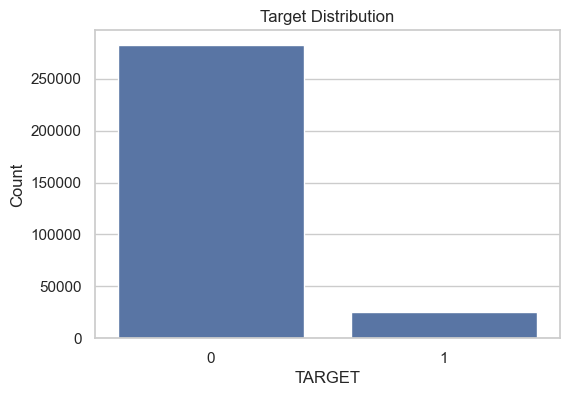

In [ ]:
target_col = "TARGET"

target_summary = df[target_col].value_counts().to_frame("count")
target_summary["percentage"] = df[target_col].value_counts(normalize=True) * 100

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

In [ ]:
# PART 4. Identify Variable Types

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

binary_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=True) == 2 and col != target_col
]

print("Number of numeric features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))
print("Number of binary features:", len(binary_cols))

print("\nCategorical columns:")
print(categorical_cols)

print("\nBinary columns:")
print(binary_cols)

Number of numeric features: 92
Number of categorical features: 12
Number of binary features: 7

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'NAME_TYPE_SUITE']

Binary columns:
['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']


,missing_count,missing_rate
BUREAU_AMT_ANNUITY_MEAN,227502,73.981744
OWN_CAR_AGE,202929,65.990810
EXT_SOURCE_1,173378,56.381073
BUREAU_AMT_MAX_OVERDUE_EVER,123625,40.201814
OCCUPATION_TYPE,96391,31.345545
EXT_SOURCE_3,60965,19.825307
BUREAU_AMT_DEBT_MEAN,51380,16.708345
BUREAU_AMT_DEBT_MAX,51380,16.708345
BUREAU_DAYS_ENDDATE_MEAN,46269,15.046291
BUREAU_AMT_CREDIT_SUM_MEAN,44021,14.315260


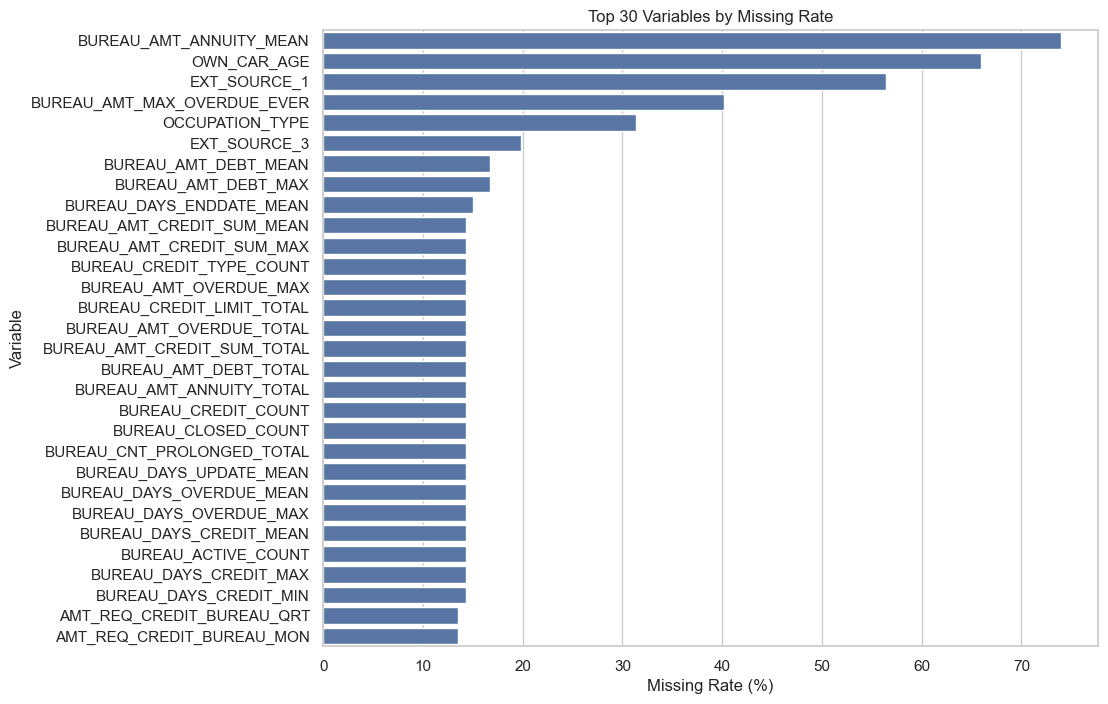

,variable,default_rate_not_missing,default_rate_missing,difference
13,AMT_REQ_CREDIT_BUREAU_HOUR,0.077194,0.103374,0.026180
14,AMT_REQ_CREDIT_BUREAU_DAY,0.077194,0.103374,0.026180
15,AMT_REQ_CREDIT_BUREAU_WEEK,0.077194,0.103374,0.026180
18,AMT_REQ_CREDIT_BUREAU_YEAR,0.077194,0.103374,0.026180
17,AMT_REQ_CREDIT_BUREAU_QRT,0.077194,0.103374,0.026180
16,AMT_REQ_CREDIT_BUREAU_MON,0.077194,0.103374,0.026180
41,BUREAU_DAYS_ENDDATE_MEAN,0.077063,0.101429,0.024366
21,BUREAU_ACTIVE_COUNT,0.077301,0.101249,0.023949
22,BUREAU_CLOSED_COUNT,0.077301,0.101249,0.023949
20,BUREAU_CREDIT_COUNT,0.077301,0.101249,0.023949


In [ ]:

# PART 5. Missing Value Analysis


missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_rate": df.isnull().mean() * 100
}).sort_values("missing_rate", ascending=False)

display(missing[missing["missing_count"] > 0])

top_missing = missing[missing["missing_count"] > 0].head(30)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_missing.reset_index(),
    x="missing_rate",
    y="index"
)
plt.title("Top 30 Variables by Missing Rate")
plt.xlabel("Missing Rate (%)")
plt.ylabel("Variable")
plt.show()

# PART 6. Missingness vs TARGET


missing_target_results = []

for col in df.columns:
    if col != target_col and df[col].isnull().sum() > 0:
        missing_flag = df[col].isnull().astype(int)
        default_rate = df.groupby(missing_flag)[target_col].mean()

        if len(default_rate) == 2:
            missing_target_results.append({
                "variable": col,
                "default_rate_not_missing": default_rate.loc[0],
                "default_rate_missing": default_rate.loc[1],
                "difference": default_rate.loc[1] - default_rate.loc[0]
            })

missing_target_df = pd.DataFrame(missing_target_results)
missing_target_df = missing_target_df.sort_values("difference", ascending=False)

display(missing_target_df.head(30))

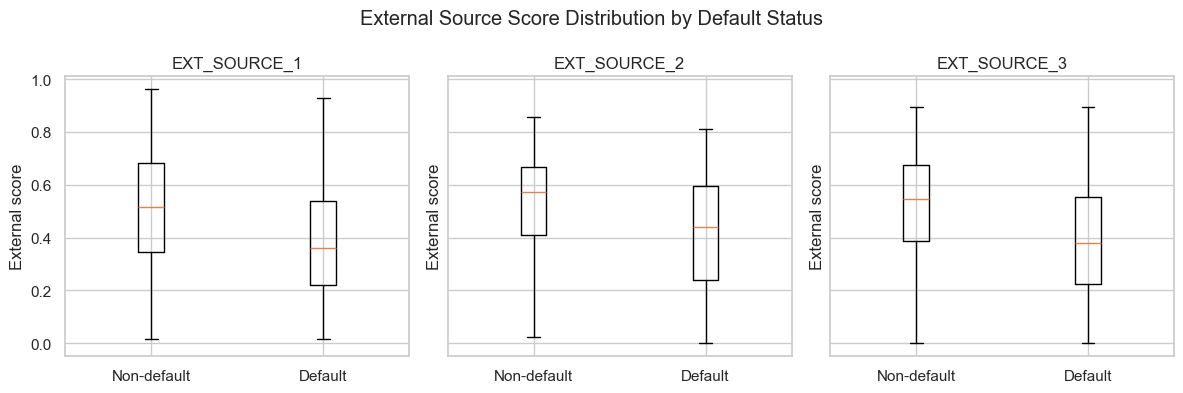

In [ ]:

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ext_cols):
    non_default = df.loc[df["TARGET"] == 0, col].dropna()
    default = df.loc[df["TARGET"] == 1, col].dropna()

    ax.boxplot(
        [non_default, default],
        labels=["Non-default", "Default"],
        showfliers=False
    )
    ax.set_title(col)
    ax.set_ylabel("External score")

plt.suptitle("External Source Score Distribution by Default Status")
plt.tight_layout()
plt.show()

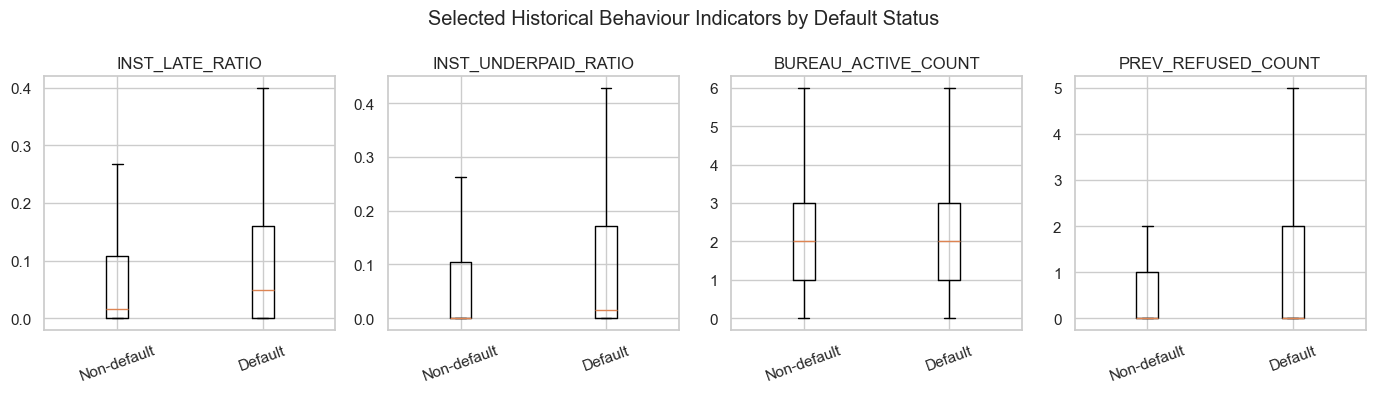

In [ ]:
hist_cols = [
    "INST_LATE_RATIO",
    "INST_UNDERPAID_RATIO",
    "BUREAU_ACTIVE_COUNT",
    "PREV_REFUSED_COUNT"
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, col in zip(axes, hist_cols):
    non_default = df.loc[df["TARGET"] == 0, col].dropna()
    default = df.loc[df["TARGET"] == 1, col].dropna()

    ax.boxplot(
        [non_default, default],
        labels=["Non-default", "Default"],
        showfliers=False
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Selected Historical Behaviour Indicators by Default Status")
plt.tight_layout()
plt.show()

In [ ]:

# PART 7. Feature Group Overview


feature_groups = {
    "BUREAU": [col for col in df.columns if col.startswith("BUREAU_")],
    "PREV": [col for col in df.columns if col.startswith("PREV_")],
    "INST": [col for col in df.columns if col.startswith("INST_")],
    "POS": [col for col in df.columns if col.startswith("POS_")]
}

for group_name, cols in feature_groups.items():
    print(f"\n===== {group_name} FEATURES =====")
    print("Number of features:", len(cols))

    if len(cols) > 0:
        avg_missing = df[cols].isnull().mean().mean() * 100
        print(f"Average missing rate: {avg_missing:.2f}%")

        has_history_flag = df[cols].notnull().any(axis=1).astype(int)

        display(
            df.groupby(has_history_flag)[target_col]
              .agg(["count", "mean"])
              .rename(index={0: f"No {group_name} history", 1: f"Has {group_name} history"})
        )


===== BUREAU FEATURES =====
Number of features: 24
Average missing rate: 18.11%


,count,mean
No BUREAU history,44020,0.101249
Has BUREAU history,263491,0.077301



===== PREV FEATURES =====
Number of features: 17
Average missing rate: 6.06%


,count,mean
No PREV history,16454,0.059560
Has PREV history,291057,0.081926



===== INST FEATURES =====
Number of features: 9
Average missing rate: 5.16%


,count,mean
No INST history,15868,0.059806
Has INST history,291643,0.081867



===== POS FEATURES =====
Number of features: 9
Average missing rate: 5.88%


,count,mean
No POS history,18067,0.066641
Has POS history,289444,0.081608


DAYS_EMPLOYED anomaly count: 55374
DAYS_EMPLOYED anomaly rate: 18.01%


,count,mean
DAYS_EMPLOYED_ANOMALY,,
0,252137,0.086600
1,55374,0.053996


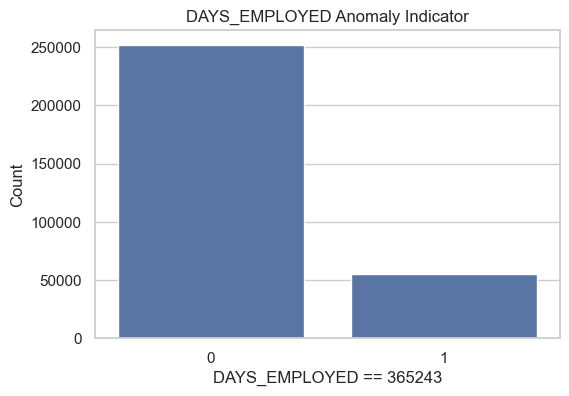

In [ ]:

# PART 8. Anomaly Check: DAYS_EMPLOYED = 365243


if "DAYS_EMPLOYED" in df.columns:
    anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
    anomaly_rate = (df["DAYS_EMPLOYED"] == 365243).mean() * 100

    print("DAYS_EMPLOYED anomaly count:", anomaly_count)
    print(f"DAYS_EMPLOYED anomaly rate: {anomaly_rate:.2f}%")

    display(
        df.assign(DAYS_EMPLOYED_ANOMALY=(df["DAYS_EMPLOYED"] == 365243).astype(int))
          .groupby("DAYS_EMPLOYED_ANOMALY")[target_col]
          .agg(["count", "mean"])
    )

    plt.figure(figsize=(6, 4))
    sns.countplot(x=(df["DAYS_EMPLOYED"] == 365243).astype(int))
    plt.title("DAYS_EMPLOYED Anomaly Indicator")
    plt.xlabel("DAYS_EMPLOYED == 365243")
    plt.ylabel("Count")
    plt.show()

In [ ]:

# PART 9. Categorical Variables vs TARGET


cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of categorical variables:", len(cat_cols))
print(cat_cols)


def categorical_target_summary(data, col, target=target_col):
    summary = (
        data.groupby(col)[target]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "n_observations",
            "mean": "default_rate"
        })
        .sort_values("default_rate", ascending=False)
    )

    summary["default_rate"] = summary["default_rate"] * 100
    return summary


# Display default rate by category for each categorical variable
for col in cat_cols:
    print(f"\n===== {col} =====")
    display(categorical_target_summary(df, col))

Number of categorical variables: 12
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'NAME_TYPE_SUITE']

===== NAME_CONTRACT_TYPE =====


,NAME_CONTRACT_TYPE,n_observations,default_rate
0,Cash loans,278232,8.345913
1,Revolving loans,29279,5.478329



===== CODE_GENDER =====


,CODE_GENDER,n_observations,default_rate
1,M,105059,10.141920
0,F,202448,6.999328
2,XNA,4,0.000000



===== FLAG_OWN_CAR =====


...

,ORGANIZATION_TYPE,n_observations,default_rate
54,Transport: type 3,1187,15.754002
18,Industry: type 13,67,13.432836
25,Industry: type 8,24,12.500000
38,Restaurant,1811,11.706240
7,Construction,6721,11.679810
6,Cleaning,260,11.153846
14,Industry: type 1,1039,11.068335
20,Industry: type 3,3278,10.616229
36,Realtor,396,10.606061
1,Agriculture,2454,10.472698



===== WEEKDAY_APPR_PROCESS_START =====


,WEEKDAY_APPR_PROCESS_START,n_observations,default_rate
5,TUESDAY,53901,8.350494
6,WEDNESDAY,51934,8.160357
0,FRIDAY,50338,8.146927
4,THURSDAY,50591,8.100255
3,SUNDAY,16181,7.929053
2,SATURDAY,33852,7.887274
1,MONDAY,50714,7.757227



===== NAME_TYPE_SUITE =====


,NAME_TYPE_SUITE,n_observations,default_rate
4,Other_B,1770,9.830508
3,Other_A,866,8.775982
2,Group of people,271,8.487085
6,Unaccompanied,248526,8.183047
5,"Spouse, partner",11370,7.871592
1,Family,40149,7.494583
0,Children,3267,7.376798


Top positive correlations with TARGET:


TARGET                         1.000000
BUREAU_DAYS_CREDIT_MEAN        0.089729
DAYS_BIRTH                     0.078239
BUREAU_DAYS_CREDIT_MIN         0.075248
INST_LATE_RATIO                0.070199
BUREAU_DAYS_UPDATE_MEAN        0.068927
BUREAU_ACTIVE_COUNT            0.067128
PREV_REFUSED_COUNT             0.064469
INST_UNDERPAID_RATIO           0.062721
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
PREV_DAYS_DECISION_MIN         0.053434
DAYS_ID_PUBLISH                0.051457
BUREAU_DAYS_CREDIT_MAX         0.049782
BUREAU_DAYS_ENDDATE_MEAN       0.046983
PREV_DAYS_DECISION_MEAN        0.046864
FLAG_EMP_PHONE                 0.045982
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
Name: TARGET, dtype: float64

Top negative correlations with TARGET:


BUREAU_AMT_CREDIT_SUM_MEAN    -0.019957
INST_COUNT                    -0.021217
PREV_AMT_APPLICATION_MEAN     -0.021803
FLAG_PHONE                    -0.023806
HOUR_APPR_PROCESS_START       -0.024166
PREV_AMT_DOWN_PAYMENT_MEAN    -0.024624
PREV_AMT_ANNUITY_MAX          -0.028966
AMT_CREDIT                    -0.030369
BUREAU_CLOSED_COUNT           -0.030812
PREV_APPROVED_COUNT           -0.031553
PREV_RATE_DOWN_PAYMENT_MEAN   -0.033601
PREV_AMT_ANNUITY_MEAN         -0.034871
POS_MONTHS_COUNT              -0.035632
POS_ACTIVE_COUNT              -0.035866
REGION_POPULATION_RELATIVE    -0.037227
AMT_GOODS_PRICE               -0.039645
DAYS_EMPLOYED                 -0.044932
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
Name: TARGET, dtype: float64

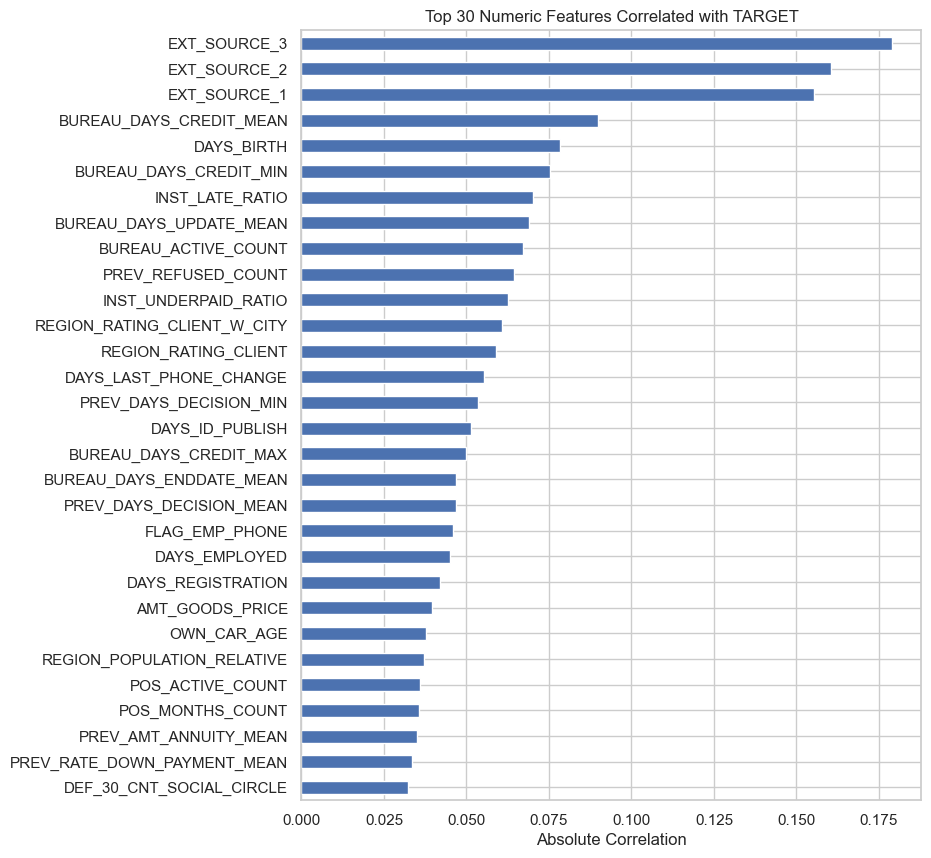

In [ ]:

# Correlation Exploration


corr_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = corr_df.corr()

target_corr = corr_matrix[target_col].sort_values(ascending=False)

print("Top positive correlations with TARGET:")
display(target_corr.head(20))

print("Top negative correlations with TARGET:")
display(target_corr.tail(20))

plt.figure(figsize=(8, 10))
target_corr.drop(target_col).abs().sort_values(ascending=False).head(30).plot(kind="barh")
plt.title("Top 30 Numeric Features Correlated with TARGET")
plt.xlabel("Absolute Correlation")
plt.gca().invert_yaxis()
plt.show()

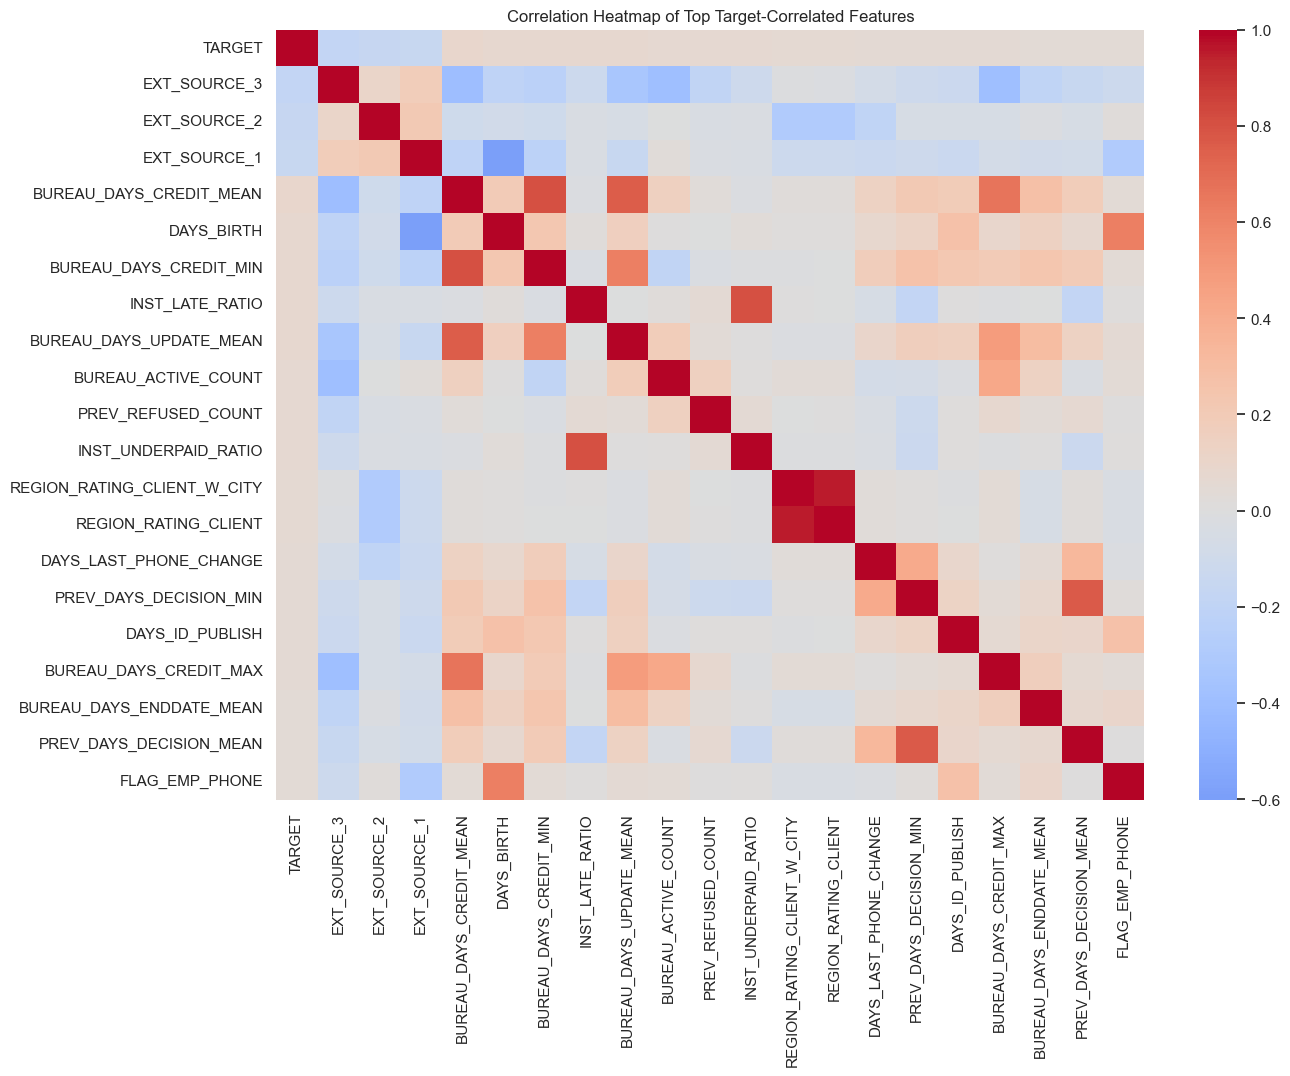

In [ ]:

#  Correlation Heatmap


selected_corr_cols = (
    target_corr.drop(target_col)
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

selected_corr_cols = [target_col] + selected_corr_cols

plt.figure(figsize=(14, 10))
sns.heatmap(
    df[selected_corr_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Top Target-Correlated Features")
plt.show()

In [ ]:

#  Outlier Check


outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_rate = ((df[col] < lower_bound) | (df[col] > upper_bound)).mean() * 100

    outlier_summary.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_rate": outlier_rate
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values("outlier_rate", ascending=False)

display(outlier_df.head(30))

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_rate
16,REGION_RATING_CLIENT,2.0,2.000000,0.000000,2.000000,2.000000e+00,26.186706
17,REGION_RATING_CLIENT_W_CITY,2.0,2.000000,0.000000,2.000000,2.000000e+00,25.373726
7,DAYS_EMPLOYED,-2760.0,-289.000000,2471.000000,-6466.500000,3.417500e+03,23.484363
78,INST_PAYMENT_SHORTFALL_MEAN,0.0,446.761288,446.761288,-670.141932,1.116903e+03,22.848288
29,FLAG_WORK_PHONE,0.0,0.000000,0.000000,0.000000,0.000000e+00,19.936848
47,BUREAU_AMT_ANNUITY_TOTAL,0.0,0.000000,0.000000,0.000000,0.000000e+00,19.599949
28,FLAG_EMP_PHONE,1.0,1.000000,0.000000,1.000000,1.000000e+00,18.011063
84,POS_DPD_MAX,0.0,0.000000,0.000000,0.000000,0.000000e+00,17.782453
85,POS_DPD_MEAN,0.0,0.000000,0.000000,0.000000,0.000000e+00,17.782453
26,AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.000000,0.000000,0.000000,0.000000e+00,16.446566


AMT_INCOME_TOTAL               391.559654
BUREAU_AMT_MAX_OVERDUE_EVER    265.926459
BUREAU_AMT_OVERDUE_MAX         178.419571
BUREAU_AMT_OVERDUE_TOTAL       152.579778
AMT_REQ_CREDIT_BUREAU_QRT      134.365776
BUREAU_AMT_ANNUITY_TOTAL       127.797852
BUREAU_AMT_ANNUITY_MEAN        104.925600
POS_DPD_DEF_MEAN               102.198336
POS_DPD_DEF_MAX                 86.701209
BUREAU_AMT_CREDIT_SUM_TOTAL     75.886871
BUREAU_AMT_CREDIT_SUM_MEAN      67.623382
BUREAU_DAYS_OVERDUE_MEAN        52.963729
BUREAU_AMT_CREDIT_SUM_MAX       39.500275
BUREAU_AMT_DEBT_TOTAL           38.905720
PREV_AMT_DOWN_PAYMENT_MEAN      31.430497
INST_PAYMENT_SHORTFALL_MAX      28.694152
AMT_REQ_CREDIT_BUREAU_DAY       27.043505
INST_PAYMENT_DELAY_MEAN         25.887626
BUREAU_DAYS_OVERDUE_MAX         23.039512
POS_DPD_MEAN                    20.125659
BUREAU_AMT_DEBT_MEAN            19.609157
BUREAU_AMT_DEBT_MAX             16.159279
POS_DPD_MAX                     14.748727
AMT_REQ_CREDIT_BUREAU_HOUR      14

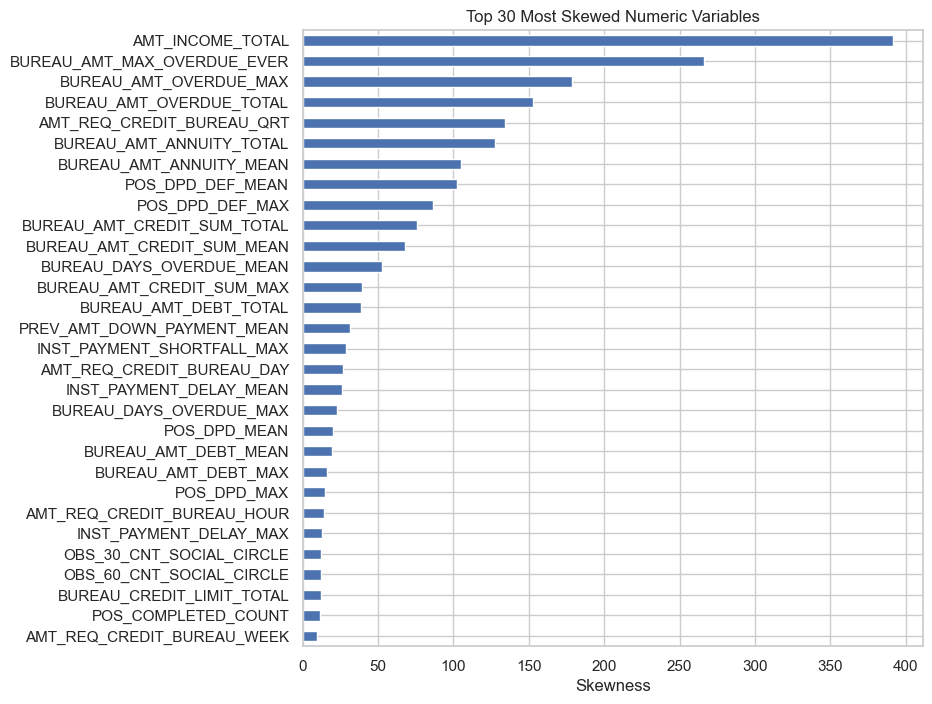

In [ ]:

#  Skewness Check


skewness = df[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)

display(skewness.head(30))

plt.figure(figsize=(8, 8))
skewness.head(30).plot(kind="barh")
plt.title("Top 30 Most Skewed Numeric Variables")
plt.xlabel("Skewness")
plt.gca().invert_yaxis()
plt.show()

# Data split & Data cleaning & Feature engineering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

SEED = 42
np.random.seed(SEED)

# A small constant used to avoid division by zero in ratio features.
EPS = 1e-6


def safe_ratio(num, denom):
    '''Element-wise division; denominator == 0 maps to 0 (interpreted as "no history").'''
    denom_safe = denom.replace(0, np.nan)
    return (num / denom_safe).fillna(0.0)


# ## 2. Data loading and split
#
# Stratified 60/20/20 split preserves the ~8% default rate in every partition.

In [ ]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

train_df, temp_df = train_test_split(
    df, test_size=0.40, random_state=SEED, stratify=df['TARGET']
)
validation_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['TARGET']
)

train_dummy      = train_df.copy()
validation_dummy = validation_df.copy()
test_dummy       = test_df.copy()

print(f'train      : {train_dummy.shape}   default rate = {train_dummy["TARGET"].mean():.4f}')
print(f'validation : {validation_dummy.shape}   default rate = {validation_dummy["TARGET"].mean():.4f}')
print(f'test       : {test_dummy.shape}   default rate = {test_dummy["TARGET"].mean():.4f}')


# ## 3. Cleaning, imputation, and feature engineering
#
# Each variable block applies in order:
#
# 1. **Repair sentinel and impossible values** (e.g., `DAYS_EMPLOYED = 365243`,
#    negative durations, scores outside `[0, 1]`) by replacing with `NaN`.
# 2. **Add `*_MISSING` or `*_ANOMALY` indicators** when missingness carries
#    information about the applicant (e.g., a `NaN` `OWN_CAR_AGE` for
#    `FLAG_OWN_CAR == 'N'` means "no car", not bad data).
# 3. **Fill remaining `NaN`** using statistics learned from `train_dummy`
#    only — medians for numeric, modes for categorical, `0` for "no history"
#    in aggregated blocks.
# 4. **Engineer ratio and aggregate features** that the literature on consumer
#    credit highlights (e.g., loan-to-income ratio, bureau debt pressure,
#    repayment-risk indices).

# ### 3.1 Loan amounts, demographics, temporal, external, region

train      : (184506, 105)   default rate = 0.0807
validation : (61502, 105)   default rate = 0.0807
test       : (61503, 105)   default rate = 0.0807


In [ ]:


section_2_6_cols = [
    # Loan
    'NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    # Demographics
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    # Temporal
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
    # External
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # Region
    'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
]

datasets = [train_dummy, validation_dummy, test_dummy]

#  Sentinel and out-of-range repairs
# DAYS_EMPLOYED 365243 is a sentinel for "not employed".
for d in datasets:
    d['DAYS_EMPLOYED_ANOMALY'] = (d['DAYS_EMPLOYED'] == 365243).astype(int)
    d['DAYS_EMPLOYED'] = d['DAYS_EMPLOYED'].replace(365243, np.nan)

# AMT_INCOME_TOTAL extreme tail — winsorise at train P99.5.
income_cap = train_dummy['AMT_INCOME_TOTAL'].quantile(0.995)
for d in datasets:
    d['AMT_INCOME_TOTAL_EXTREME'] = (d['AMT_INCOME_TOTAL'] > income_cap).astype(int)
    d.loc[d['AMT_INCOME_TOTAL'] > income_cap, 'AMT_INCOME_TOTAL'] = income_cap

# OWN_CAR_AGE: NaN for no-car applicants is structural; flag separately.
for d in datasets:
    d['OWN_CAR_AGE_NO_CAR'] = (
        (d['FLAG_OWN_CAR'] == 'N') & d['OWN_CAR_AGE'].isna()
    ).astype(int)

# OWN_CAR_AGE outside plausible range -> NaN.
for d in datasets:
    outlier = (d['OWN_CAR_AGE'] < 0) | (d['OWN_CAR_AGE'] > 70)
    d['OWN_CAR_AGE_OUTLIER'] = outlier.fillna(False).astype(int)
    d.loc[outlier, 'OWN_CAR_AGE'] = np.nan

# Family size inconsistencies (members < children + 1) -> NaN.
for d in datasets:
    inconsistent = (
        d['CNT_FAM_MEMBERS'].notna()
        & (d['CNT_FAM_MEMBERS'] < d['CNT_CHILDREN'] + 1)
    )
    d['CNT_FAM_INCONSISTENT'] = inconsistent.astype(int)
    d.loc[inconsistent, 'CNT_FAM_MEMBERS'] = np.nan

# Non-positive amounts and impossible time directions.
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    for d in datasets:
        d.loc[d[col] <= 0, col] = np.nan
for col in ['DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    for d in datasets:
        d.loc[d[col] > 0, col] = np.nan
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    for d in datasets:
        d.loc[(d[col] < 0) | (d[col] > 1), col] = np.nan

# Missing indicators where missingness carries signal.
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']:
    for d in datasets:
        d[col + '_MISSING'] = d[col].isna().astype(int)

# Imputation using train-only statistics
numeric_2_6 = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'REGION_POPULATION_RELATIVE',
]
medians = train_dummy[numeric_2_6].median()
for d in datasets:
    d[numeric_2_6] = d[numeric_2_6].fillna(medians)

# Rating modes from train.
rating_modes = {
    c: train_dummy[c].mode(dropna=True).iloc[0]
    for c in ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
}
for d in datasets:
    for c, m in rating_modes.items():
        d[c] = d[c].fillna(m)

# Categorical missing -> explicit 'Missing' (becomes its own one-hot column).
cat_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
]
for d in datasets:
    for c in cat_cols:
        d[c] = d[c].astype('object').fillna('Missing')

#  NAME_EDUCATION_TYPE -> ordinal
# Education level has a meaningful order. Encoding the hierarchy as 0..4
# (0 = Academic degree, 4 = Lower secondary) lets a linear model capture
# the dose–response relationship with a single coefficient.
education_order = {
    'Academic degree'              : 0,
    'Higher education'             : 1,
    'Incomplete higher'            : 2,
    'Secondary / secondary special': 3,
    'Lower secondary'              : 4,
}
edu_median = int(round(train_dummy['NAME_EDUCATION_TYPE'].map(education_order).median()))
for d in datasets:
    d['NAME_EDUCATION_TYPE_ORDINAL'] = (
        d['NAME_EDUCATION_TYPE'].map(education_order).fillna(edu_median).astype(int)
    )
    d.drop(columns=['NAME_EDUCATION_TYPE'], inplace=True)

# Engineered features
for d in datasets:
    d['CREDIT_INCOME_RATIO']    = safe_ratio(d['AMT_CREDIT'], d['AMT_INCOME_TOTAL'])
    d['ANNUITY_INCOME_RATIO']   = safe_ratio(d['AMT_ANNUITY'], d['AMT_INCOME_TOTAL'])
    d['CREDIT_TERM']            = safe_ratio(d['AMT_CREDIT'], d['AMT_ANNUITY'])
    d['ANNUITY_CREDIT_RATIO']   = safe_ratio(d['AMT_ANNUITY'], d['AMT_CREDIT'])
    d['CREDIT_GOODS_RATIO']     = safe_ratio(d['AMT_CREDIT'], d['AMT_GOODS_PRICE'])
    d['AGE_YEARS']              = -d['DAYS_BIRTH'] / 365.25
    d['EMPLOYED_YEARS']         = -d['DAYS_EMPLOYED'] / 365.25
    d['EMPLOYED_TO_AGE_RATIO']  = safe_ratio(d['EMPLOYED_YEARS'], d['AGE_YEARS'])
    d['CNT_FAM_MEMBERS']        = d['CNT_FAM_MEMBERS'].clip(lower=1)
    d['ADULT_COUNT']            = (d['CNT_FAM_MEMBERS'] - d['CNT_CHILDREN']).clip(lower=1)
    d['INCOME_PER_FAM_MEMBER']  = d['AMT_INCOME_TOTAL'] / (d['CNT_FAM_MEMBERS'] + EPS)
    d['INCOME_PER_ADULT']       = d['AMT_INCOME_TOTAL'] / (d['ADULT_COUNT']     + EPS)
    d['EXT_SOURCE_MEAN']        = d[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    d['EXT_SOURCE_MIN']         = d[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
    d['EXT_SOURCE_MAX']         = d[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
    d['EXT_SOURCE_STD']         = d[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1).fillna(0)
    d['EXT_SOURCE_PROD']        = d['EXT_SOURCE_1'] * d['EXT_SOURCE_2'] * d['EXT_SOURCE_3']
    d['EXT_SOURCE_MISSING_COUNT'] = (
        d['EXT_SOURCE_1_MISSING'] + d['EXT_SOURCE_2_MISSING'] + d['EXT_SOURCE_3_MISSING']
    )
    d['REGION_RATING_GAP'] = d['REGION_RATING_CLIENT'] - d['REGION_RATING_CLIENT_W_CITY']



In [ ]:


print(d["ADULT_COUNT"].dtype)


# ### 3.2 Social circle

float64


In [ ]:


social_cols = [
    'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
]
social_medians = train_dummy[social_cols].median()
for d in datasets:
    d[social_cols] = d[social_cols].fillna(social_medians)
    d['SOCIAL_DEFAULT_RATIO_60'] = (
        d['DEF_60_CNT_SOCIAL_CIRCLE'] / (d['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
    )


# ### 3.3 Credit bureau enquiries

In [ ]:


bureau_enq_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',  'AMT_REQ_CREDIT_BUREAU_YEAR',
]
# Whole-row missingness here means "no bureau enquiry data available",
# which is a meaningful applicant profile rather than random missingness.
for d in datasets:
    d['NO_BUREAU_ENQ_HISTORY'] = d[bureau_enq_cols].isna().all(axis=1).astype(int)
    d[bureau_enq_cols] = d[bureau_enq_cols].fillna(0)
    d['BUREAU_ENQ_TOTAL'] = d[bureau_enq_cols].sum(axis=1)
    d['BUREAU_ENQ_RECENT_RATIO'] = (
        d[['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
           'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON']].sum(axis=1)
        / (d['BUREAU_ENQ_TOTAL'] + 1)
    )


# ### 3.4 Contact flags

In [ ]:


# Contact flags are complete and binary; no cleaning needed.
contact_flag_cols = ['FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
assert all(c in train_dummy.columns for c in contact_flag_cols)
assert train_dummy[contact_flag_cols].isna().sum().sum() == 0


# ### 3.5 Application context

In [ ]:


valid_weekdays = ['MONDAY','TUESDAY','WEDNESDAY','THURSDAY','FRIDAY','SATURDAY','SUNDAY']

for d in datasets:
    for col in ['WEEKDAY_APPR_PROCESS_START', 'NAME_TYPE_SUITE']:
        d[col] = d[col].astype('object')
        d[col] = d[col].where(d[col].isna(), d[col].astype(str).str.strip())

    invalid = ~d['WEEKDAY_APPR_PROCESS_START'].isin(valid_weekdays) & d['WEEKDAY_APPR_PROCESS_START'].notna()
    d.loc[invalid, 'WEEKDAY_APPR_PROCESS_START'] = np.nan

    valid_hour = d['HOUR_APPR_PROCESS_START'].between(0, 23)
    d.loc[~valid_hour, 'HOUR_APPR_PROCESS_START'] = np.nan

    d['NAME_TYPE_SUITE_MISSING'] = d['NAME_TYPE_SUITE'].isna().astype(int)

weekday_mode = train_dummy['WEEKDAY_APPR_PROCESS_START'].mode(dropna=True).iloc[0]
hour_median  = train_dummy['HOUR_APPR_PROCESS_START'].median()

for d in datasets:
    d['WEEKDAY_APPR_PROCESS_START'] = d['WEEKDAY_APPR_PROCESS_START'].fillna(weekday_mode)
    d['HOUR_APPR_PROCESS_START']    = d['HOUR_APPR_PROCESS_START'].fillna(hour_median)
    d['NAME_TYPE_SUITE']            = d['NAME_TYPE_SUITE'].fillna('Missing')


# ### 3.6 History variables (Bureau, Previous, Installments, POS)
#
# These blocks summarise the applicant's behaviour on past credit. An applicant
# with no prior loans has the entire block missing; we record that as a
# `NO_*_HISTORY` indicator and fill the underlying columns with `0`. Applicants
# with partial history get column medians computed on the subset of train
# applicants who do have history.

In [ ]:


history_prefixes = ['BUREAU_', 'PREV_', 'INST_', 'POS_']

# Step 1: NO_*_HISTORY indicator + zero-fill for whole-row missing
for prefix in history_prefixes:
    group_cols = [
        c for c in train_dummy.columns
        if c.startswith(prefix) and not c.startswith('NO_')
    ]
    if not group_cols:
        continue
    indicator = 'NO_' + prefix.rstrip('_') + '_HISTORY'
    for d in datasets:
        if indicator not in d.columns:
            d[indicator] = d[group_cols].isna().all(axis=1).astype(int)
        no_hist = d[indicator] == 1
        d.loc[no_hist, group_cols] = d.loc[no_hist, group_cols].fillna(0)

# Step 2: rebuild installment ratios from counts where possible
for d in datasets:
    if {'INST_LATE_RATIO', 'INST_LATE_COUNT', 'INST_COUNT'}.issubset(d.columns):
        mask = (
            d['INST_LATE_RATIO'].isna()
            & d['INST_LATE_COUNT'].notna()
            & d['INST_COUNT'].notna()
            & (d['INST_COUNT'] > 0)
        )
        d.loc[mask, 'INST_LATE_RATIO'] = d.loc[mask, 'INST_LATE_COUNT'] / d.loc[mask, 'INST_COUNT']
    if {'INST_UNDERPAID_RATIO', 'INST_UNDERPAID_COUNT', 'INST_COUNT'}.issubset(d.columns):
        mask = (
            d['INST_UNDERPAID_RATIO'].isna()
            & d['INST_UNDERPAID_COUNT'].notna()
            & d['INST_COUNT'].notna()
            & (d['INST_COUNT'] > 0)
        )
        d.loc[mask, 'INST_UNDERPAID_RATIO'] = d.loc[mask, 'INST_UNDERPAID_COUNT'] / d.loc[mask, 'INST_COUNT']

# Step 3: missing indicator for the two key INST ratios
for col in ['INST_LATE_RATIO', 'INST_UNDERPAID_RATIO']:
    if col in train_dummy.columns:
        for d in datasets:
            d[col + '_MISSING'] = d[col].isna().astype(int)

# Step 4: fill partial missings with medians from train applicants who DO have history
for prefix in history_prefixes:
    group_cols = [
        c for c in train_dummy.columns
        if c.startswith(prefix) and not c.startswith('NO_')
    ]
    if not group_cols:
        continue
    indicator = 'NO_' + prefix.rstrip('_') + '_HISTORY'
    has_history_train = train_dummy[indicator] == 0
    for col in group_cols:
        med = train_dummy.loc[has_history_train, col].median()
        if pd.isna(med):
            med = 0
        for d in datasets:
            d[col] = d[col].fillna(med)

# Step 5: engineered features for each history block
for d in datasets:
    # Bureau
    if {'BUREAU_ACTIVE_COUNT', 'BUREAU_CREDIT_COUNT'}.issubset(d.columns):
        d['BUREAU_ACTIVE_RATIO'] = safe_ratio(d['BUREAU_ACTIVE_COUNT'], d['BUREAU_CREDIT_COUNT'])
    if {'BUREAU_CLOSED_COUNT', 'BUREAU_CREDIT_COUNT'}.issubset(d.columns):
        d['BUREAU_CLOSED_RATIO'] = safe_ratio(d['BUREAU_CLOSED_COUNT'], d['BUREAU_CREDIT_COUNT'])
    if {'BUREAU_AMT_DEBT_TOTAL', 'BUREAU_AMT_CREDIT_SUM_TOTAL'}.issubset(d.columns):
        d['BUREAU_DEBT_TO_CREDIT_RATIO'] = safe_ratio(
            d['BUREAU_AMT_DEBT_TOTAL'], d['BUREAU_AMT_CREDIT_SUM_TOTAL']
        )
    if {'BUREAU_AMT_DEBT_MAX', 'BUREAU_AMT_CREDIT_SUM_MAX'}.issubset(d.columns):
        d['BUREAU_MAX_DEBT_TO_MAX_CREDIT_RATIO'] = safe_ratio(
            d['BUREAU_AMT_DEBT_MAX'], d['BUREAU_AMT_CREDIT_SUM_MAX']
        )
    if 'BUREAU_AMT_OVERDUE_TOTAL' in d.columns:
        d['BUREAU_HAS_OVERDUE'] = (d['BUREAU_AMT_OVERDUE_TOTAL'] > 0).astype(int)
    if 'BUREAU_AMT_MAX_OVERDUE_EVER' in d.columns:
        d['BUREAU_HAS_OVERDUE_HISTORY'] = (d['BUREAU_AMT_MAX_OVERDUE_EVER'] > 0).astype(int)
    if {'BUREAU_AMT_OVERDUE_TOTAL', 'BUREAU_AMT_CREDIT_SUM_TOTAL'}.issubset(d.columns):
        d['BUREAU_OVERDUE_TO_CREDIT_RATIO'] = safe_ratio(
            d['BUREAU_AMT_OVERDUE_TOTAL'], d['BUREAU_AMT_CREDIT_SUM_TOTAL']
        )
    if 'BUREAU_DAYS_CREDIT_MIN' in d.columns:
        d['BUREAU_CREDIT_HISTORY_LENGTH'] = -d['BUREAU_DAYS_CREDIT_MIN']
    if 'BUREAU_DAYS_CREDIT_MAX' in d.columns:
        d['BUREAU_RECENT_CREDIT_DAYS'] = -d['BUREAU_DAYS_CREDIT_MAX']
    if 'BUREAU_DAYS_UPDATE_MEAN' in d.columns:
        d['BUREAU_UPDATE_RECENCY'] = -d['BUREAU_DAYS_UPDATE_MEAN']
    if {'BUREAU_CNT_PROLONGED_TOTAL', 'BUREAU_CREDIT_COUNT'}.issubset(d.columns):
        d['BUREAU_PROLONGED_PER_CREDIT'] = safe_ratio(
            d['BUREAU_CNT_PROLONGED_TOTAL'], d['BUREAU_CREDIT_COUNT']
        )
    # Previous applications
    if {'PREV_APPROVED_COUNT', 'PREV_APP_COUNT'}.issubset(d.columns):
        d['PREV_APPROVAL_RATIO']  = safe_ratio(d['PREV_APPROVED_COUNT'],  d['PREV_APP_COUNT'])
    if {'PREV_REFUSED_COUNT',  'PREV_APP_COUNT'}.issubset(d.columns):
        d['PREV_REFUSAL_RATIO']   = safe_ratio(d['PREV_REFUSED_COUNT'],   d['PREV_APP_COUNT'])
    if {'PREV_CANCELLED_COUNT','PREV_APP_COUNT'}.issubset(d.columns):
        d['PREV_CANCELLED_RATIO'] = safe_ratio(d['PREV_CANCELLED_COUNT'], d['PREV_APP_COUNT'])
    if {'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_APPLICATION_MEAN'}.issubset(d.columns):
        d['PREV_CREDIT_TO_APPLICATION_RATIO'] = safe_ratio(
            d['PREV_AMT_CREDIT_MEAN'], d['PREV_AMT_APPLICATION_MEAN']
        )
    # Installments
    if {'INST_LATE_RATIO', 'INST_UNDERPAID_RATIO'}.issubset(d.columns):
        d['INST_REPAYMENT_RISK_RATIO'] = d['INST_LATE_RATIO'] + d['INST_UNDERPAID_RATIO']
    # POS
    if {'POS_DPD_DEF_MEAN', 'POS_DPD_MEAN'}.issubset(d.columns):
        d['POS_DPD_SEVERITY'] = safe_ratio(d['POS_DPD_DEF_MEAN'], d['POS_DPD_MEAN'] + 1)


# ## 4. One-hot encoding and column alignment
#
# Categorical columns become indicator columns. We then reindex the validation
# and test sets to the training column set so all three dataframes share an
# identical schema. Any rare category seen only in validation or test is
# dropped, which matches what a deployed model would do for unseen levels.

In [ ]:


encode_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'WEEKDAY_APPR_PROCESS_START', 'NAME_TYPE_SUITE',
]
encode_cols = [c for c in encode_cols if c in train_dummy.columns]

train_dummy      = pd.get_dummies(train_dummy,      columns=encode_cols, dtype=int)
validation_dummy = pd.get_dummies(validation_dummy, columns=encode_cols, dtype=int)
test_dummy       = pd.get_dummies(test_dummy,       columns=encode_cols, dtype=int)

validation_dummy = validation_dummy.reindex(columns=train_dummy.columns, fill_value=0)
test_dummy       = test_dummy.reindex(columns=train_dummy.columns,       fill_value=0)


# ## 5. Sanity checks

In [ ]:


# Replace any inf produced by ratios with NaN, then fill with train medians.
for d in [train_dummy, validation_dummy, test_dummy]:
    d.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_cols = [
    c for c in train_dummy.select_dtypes(include=[np.number]).columns
    if train_dummy[c].isna().any() or validation_dummy[c].isna().any() or test_dummy[c].isna().any()
]
if nan_cols:
    fill_medians = train_dummy[nan_cols].median()
    for d in [train_dummy, validation_dummy, test_dummy]:
        d[nan_cols] = d[nan_cols].fillna(fill_medians)

for name, d in zip(['train', 'validation', 'test'],
                   [train_dummy, validation_dummy, test_dummy]):
    assert d.isna().sum().sum() == 0, f'{name} still has NaN'
    assert np.isfinite(d.select_dtypes(include=[np.number]).to_numpy()).all(), f'{name} still has inf'
    assert len(d.select_dtypes(include=['object']).columns) == 0, f'{name} has unencoded object columns'

assert train_dummy.columns.equals(validation_dummy.columns)
assert train_dummy.columns.equals(test_dummy.columns)
assert 'TARGET' in train_dummy.columns

print(f'train      : {train_dummy.shape}')
print(f'validation : {validation_dummy.shape}')
print(f'test       : {test_dummy.shape}')


# ## 6. Feature selection: MI + collinearity + family quota → Top 50
#
# We rank features by their mutual information with `TARGET`, computed on the
# training set. From the top of the ranking we greedily admit features into
# the final set subject to two constraints:
#
# 1. **Collinearity guard.** A candidate must have `|Pearson r| < 0.9` with
#    every already-selected feature.
# 2. **Family quota.** Each source family (`EXT_SOURCE`, `AMT_RAW`,
#    `AMT_RATIO`, `DAYS`, `BUREAU`, `PREV`, `INST`, `POS`, `OTHER`) is capped
#    at a maximum number of slots. This stops any single source — most notably
#    the `EXT_SOURCE` derivatives, which carry strongly correlated but
#    nominally independent signals — from dominating the selection.
#
# The discrete/continuous classification used by `mutual_info_classif`
# requires both the column to look discrete in dtype **and** to have at most
# 30 unique values, so columns like `DAYS_BIRTH` (integer but with thousands
# of distinct values) are handled by the continuous kNN estimator rather than
# a frequency table.

train      : (184506, 269)
validation : (61502, 269)
test       : (61503, 269)


In [ ]:


y_train = train_dummy['TARGET'].astype(int).values
X_train = train_dummy.drop(columns=['TARGET'])
print(f'X_train: {X_train.shape}   default rate: {y_train.mean():.4f}')

discrete_mask = np.array([
    set(X_train[col].dropna().unique()).issubset({0, 1, 0.0, 1.0})
    or (X_train[col].nunique() <= 30)
    for col in X_train.columns
])
print(f'Discrete: {discrete_mask.sum()}   Continuous: {(~discrete_mask).sum()}')

mi_scores = mutual_info_classif(
    X_train.values, y_train,
    discrete_features=discrete_mask,
    random_state=SEED,
    n_jobs=1,
)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print('\nTop 15 by MI:')
print(mi_series.head(15).to_string())

X_train: (184506, 268)   default rate: 0.0807
Discrete: 167   Continuous: 101

Top 15 by MI:
EXT_SOURCE_PROD         0.023854
EXT_SOURCE_MEAN         0.023616
EXT_SOURCE_MIN          0.021501
ANNUITY_CREDIT_RATIO    0.020067
CREDIT_TERM             0.018843
OWN_CAR_AGE             0.017315
EXT_SOURCE_MAX          0.015886
EXT_SOURCE_1            0.014894
EXT_SOURCE_3            0.013822
AMT_ANNUITY             0.013050
EXT_SOURCE_2            0.011784
CREDIT_GOODS_RATIO      0.011505
PREV_APPROVAL_RATIO     0.009677
BUREAU_CLOSED_RATIO     0.007291
AMT_CREDIT              0.007289


In [ ]:


TOP_K = 50
CORR_THRESHOLD = 0.9
CANDIDATE_POOL_SIZE = min(200, X_train.shape[1])

FAMILY_CAP = {
    'EXT_SOURCE': 5,
    'AMT_RAW'   : 3,
    'AMT_RATIO' : 6,
    'DAYS'      : 5,
    'BUREAU'    : 9,
    'PREV'      : 7,
    'INST'      : 7,
    'POS'       : 5,
    'OTHER'     : 15,
}

def get_family(col):
    c = col.upper()
    if 'EXT_SOURCE' in c or c.startswith('EXT_'):
        return 'EXT_SOURCE'
    if c in ('AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL'):
        return 'AMT_RAW'
    if c.startswith('AMT_') or ('INCOME' in c and 'RATIO' in c) \
       or ('CREDIT' in c and 'RATIO' in c) or ('ANNUITY' in c and 'RATIO' in c) \
       or c in ('INCOME_PER_FAM_MEMBER', 'INCOME_PER_ADULT', 'CREDIT_TERM',
                'EMPLOYED_TO_AGE_RATIO'):
        return 'AMT_RATIO'
    if c.startswith('DAYS_') or c in ('AGE_YEARS', 'EMPLOYED_YEARS',
                                       'DAYS_EMPLOYED_ANOMALY'):
        return 'DAYS'
    if c.startswith('BUREAU_') or c in ('NO_BUREAU_HISTORY', 'NO_BUREAU_ENQ_HISTORY'):
        return 'BUREAU'
    if c.startswith('PREV_') or c == 'NO_PREV_HISTORY':
        return 'PREV'
    if c.startswith('INST_') or c == 'NO_INST_HISTORY':
        return 'INST'
    if c.startswith('POS_') or c == 'NO_POS_HISTORY':
        return 'POS'
    return 'OTHER'

candidate_pool = mi_series.head(CANDIDATE_POOL_SIZE).index.tolist()
corr_matrix = X_train[candidate_pool].corr().abs()

selected = []
family_count = {}
dropped_corr  = []
dropped_quota = []

for feat in candidate_pool:
    if len(selected) >= TOP_K:
        break
    if not selected:
        selected.append(feat)
        family_count[get_family(feat)] = 1
        continue
    fam = get_family(feat)
    if family_count.get(fam, 0) >= FAMILY_CAP.get(fam, 999):
        dropped_quota.append((feat, fam))
        continue
    max_corr = corr_matrix.loc[feat, selected].max()
    if max_corr < CORR_THRESHOLD:
        selected.append(feat)
        family_count[fam] = family_count.get(fam, 0) + 1
    else:
        partner = corr_matrix.loc[feat, selected].idxmax()
        dropped_corr.append((feat, partner, float(max_corr)))

top50 = mi_series.loc[selected]

print(f'Selected {len(top50)} features  (target {TOP_K})')
print(f'Dropped {len(dropped_corr)} by collinearity  ({CORR_THRESHOLD} threshold)')
print(f'Dropped {len(dropped_quota)} by family quota')

print('\nFamily distribution within top 50:')
for fam, cnt in sorted(family_count.items(), key=lambda x: -x[1]):
    print(f'  {fam:<12s} {cnt:>2d}  / cap {FAMILY_CAP.get(fam, "—")}')


# ## 7. Visualizations

Selected 50 features  (target 50)
Dropped 16 by collinearity  (0.9 threshold)
Dropped 11 by family quota

Family distribution within top 50:
  BUREAU        9  / cap 9
  PREV          7  / cap 7
  AMT_RATIO     6  / cap 6
  OTHER         6  / cap 15
  INST          6  / cap 7
  EXT_SOURCE    5  / cap 5
  DAYS          5  / cap 5
  AMT_RAW       3  / cap 3
  POS           3  / cap 5


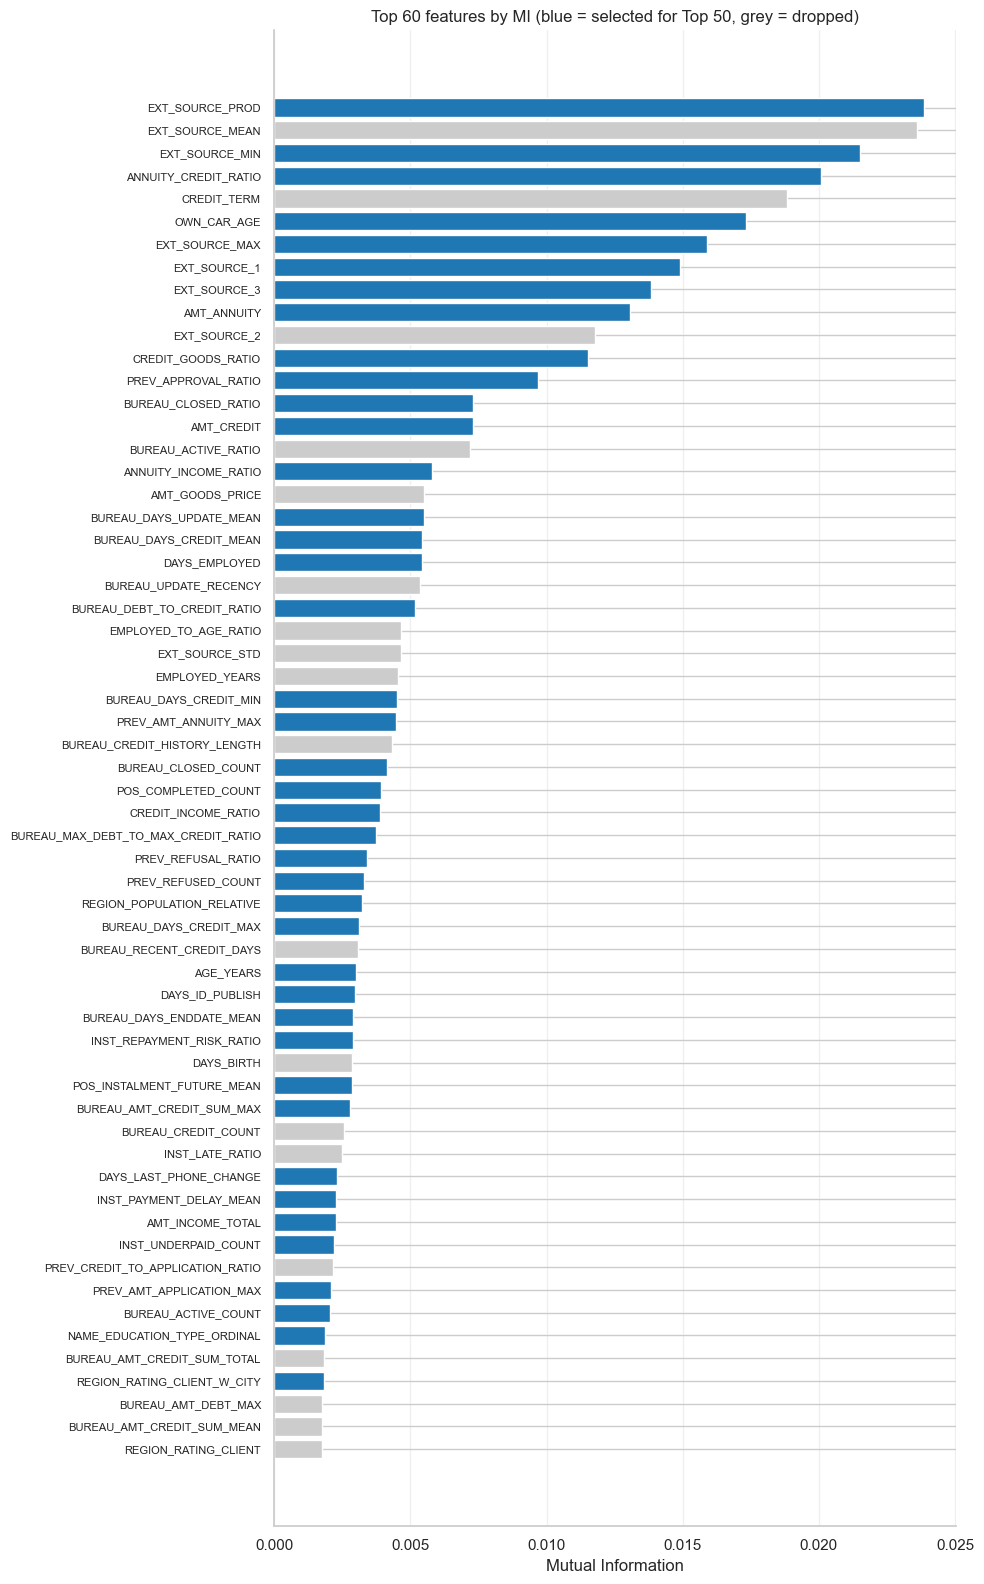

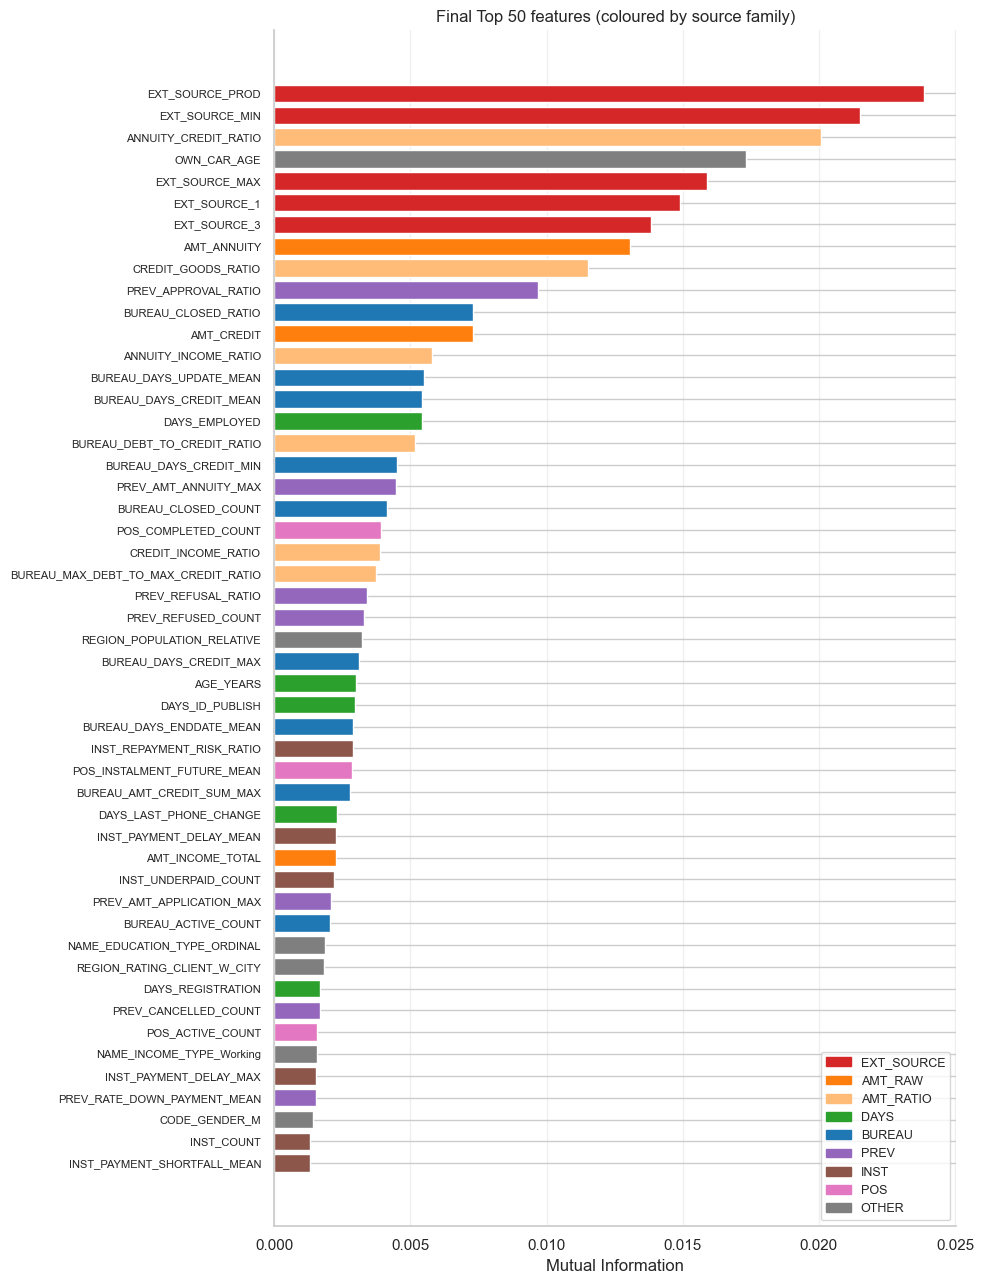

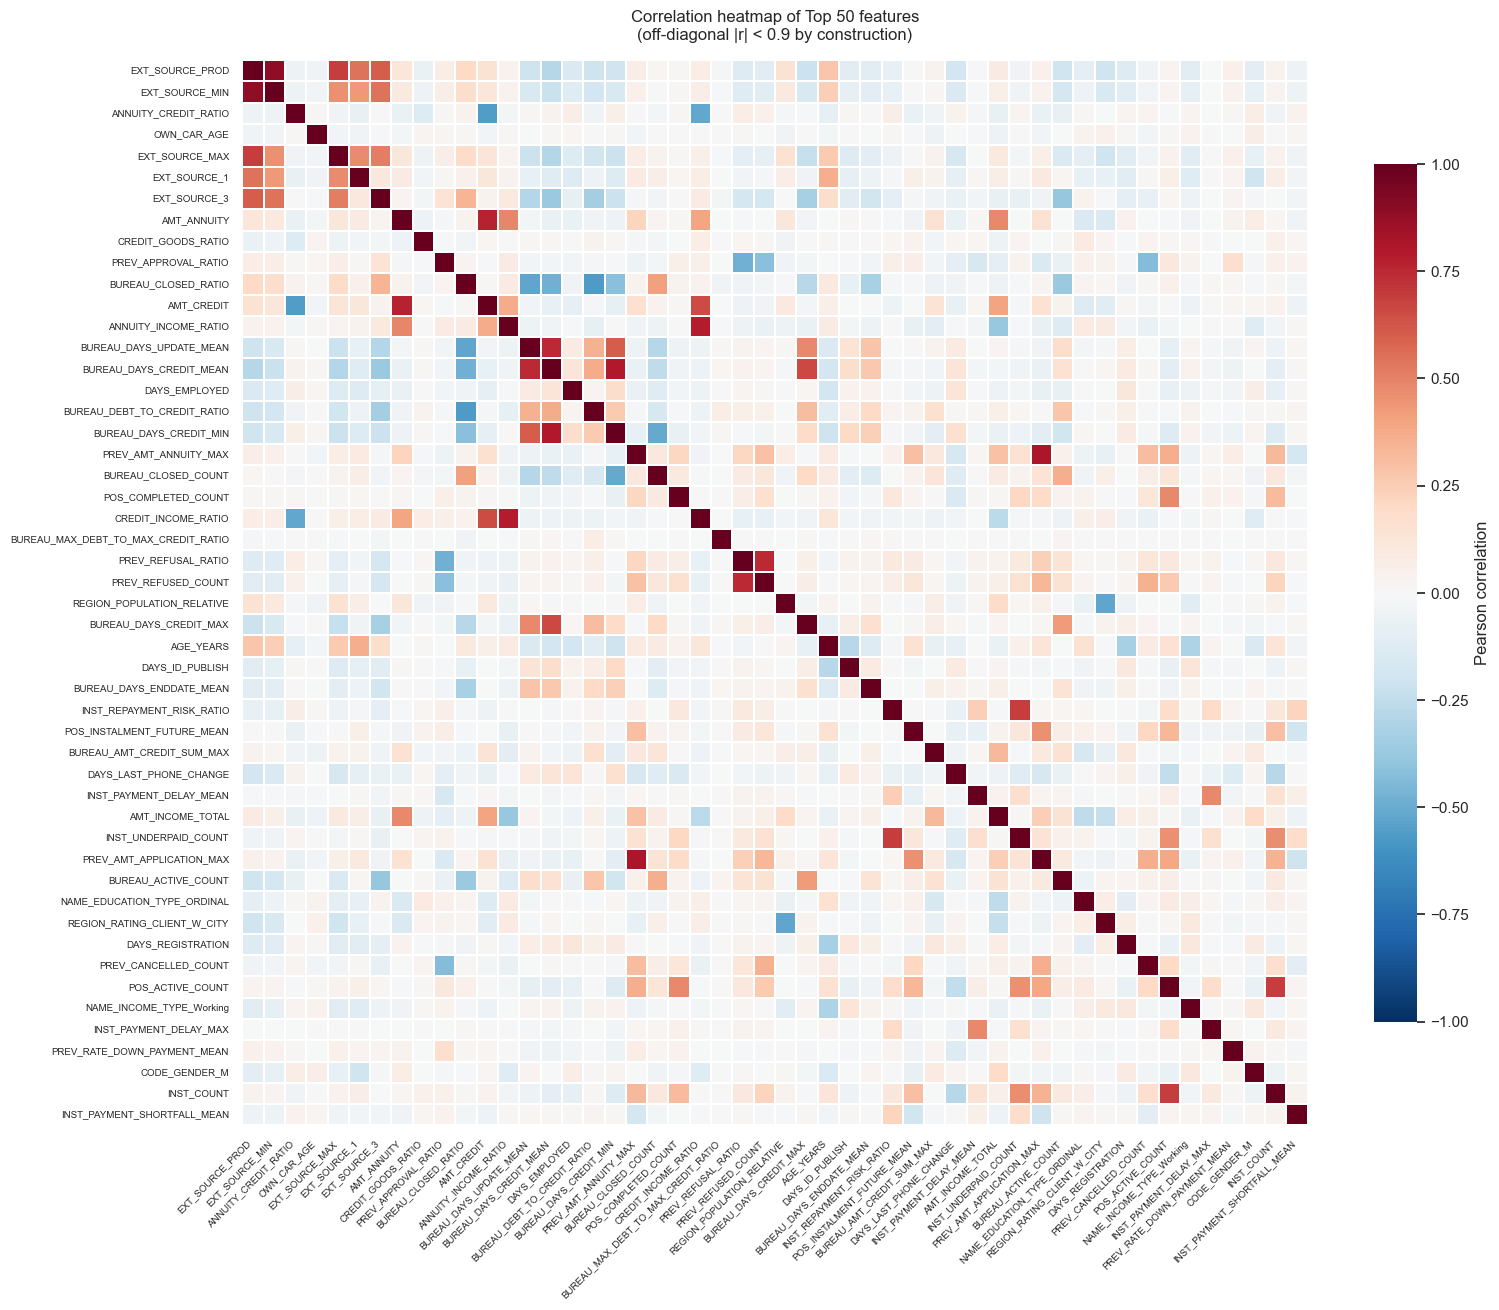

In [ ]:


plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

family_palette = {
    'EXT_SOURCE': '#d62728', 'AMT_RAW': '#ff7f0e', 'AMT_RATIO': '#ffbb78',
    'DAYS'      : '#2ca02c', 'BUREAU' : '#1f77b4', 'PREV'     : '#9467bd',
    'INST'      : '#8c564b', 'POS'    : '#e377c2', 'OTHER'    : '#7f7f7f',
}

# Figure 1 — Top 60 by MI; selected vs not selected
fig, ax = plt.subplots(figsize=(10, 16))
top60 = mi_series.head(60)
colors = ['#1f77b4' if f in selected else '#cccccc' for f in top60.index]
ax.barh(range(len(top60)), top60.values, color=colors)
ax.set_yticks(range(len(top60)))
ax.set_yticklabels(top60.index, fontsize=8)
ax.set_xlabel('Mutual Information')
ax.set_title(f'Top 60 features by MI (blue = selected for Top {TOP_K}, grey = dropped)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mi_top60.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 — Top 50 coloured by family
fig, ax = plt.subplots(figsize=(10, 13))
fam_colors = [family_palette[get_family(f)] for f in top50.index]
ax.barh(range(len(top50)), top50.values, color=fam_colors)
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50.index, fontsize=8)
ax.set_xlabel('Mutual Information')
ax.set_title(f'Final Top {len(top50)} features (coloured by source family)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k, v in family_palette.items() if k in family_count]
ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig('fig_top50_by_family.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3 — Correlation heatmap of selected top 50
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    X_train[selected].corr(),
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson correlation'},
    xticklabels=True, yticklabels=True, linewidths=0.2,
    ax=ax,
)
ax.set_title(f'Correlation heatmap of Top {len(top50)} features\n'
             f'(off-diagonal |r| < {CORR_THRESHOLD} by construction)', pad=15)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('fig_top50_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


# ## 8. Output
#
# Three feature sets are exported for the downstream modeling stage:
#
# | Set | Purpose |
# |---|---|
# | `*_full` | All engineered features. Tree-based models can exploit the full space. |
# | `*_top50` | Compact, family-balanced subset. Linear baselines and interpretation. |
# | `*_no_ext` | Full minus the `EXT_SOURCE` family. Robustness check for over-reliance on external scores. |

# Baseline Model
# Restricted Logistic Regression (L2-Regularised)

Feature sets ready:
  Full  : train (184506, 268), val (61502, 268), test (61503, 268)
  Top50 : train (184506, 50), val (61502, 50), test (61503, 50)
  NoExt : train (184506, 256), val (61502, 256), test (61503, 256)
  Targets shape: (184506,), (61502,), (61503,)

Saved: top50_features.csv (50 rows)
Train-set average AMT_CREDIT: 598570.43
Representative loan amount used in payoff matrix: 600000

Payoff matrix:


,Approve,Reject
Repays_TARGET_0,144000.0,48000.0
Defaults_TARGET_1,-300000.0,48000.0



L_FP: 96000.0
L_FN: 348000.0
Payoff-based threshold: 0.2162

Saved:
payoff_matrix_main.csv
payoff_threshold_main.csv

Payoff matrix: Conservative


,Approve,Reject
Repays_TARGET_0,108000.0,48000.0
Defaults_TARGET_1,-420000.0,48000.0



Payoff matrix: Balanced


...

Saved: final_model_comparison_by_payoff_scenario.csv

Top positive coefficients in regularised model: increase predicted default risk


,feature,coefficient
12,ANNUITY_INCOME_RATIO,0.196290
16,BUREAU_DEBT_TO_CREDIT_RATIO,0.185486
30,INST_REPAYMENT_RISK_RATIO,0.179004
38,BUREAU_ACTIVE_COUNT,0.176830
39,NAME_EDUCATION_TYPE_ORDINAL,0.172883
31,POS_INSTALMENT_FUTURE_MEAN,0.168132
8,CREDIT_GOODS_RATIO,0.158961
47,CODE_GENDER_M,0.150928
15,DAYS_EMPLOYED,0.137336
10,BUREAU_CLOSED_RATIO,0.135135



Top negative coefficients in regularised model: reduce predicted default risk


,feature,coefficient
1,EXT_SOURCE_MIN,-0.272169
4,EXT_SOURCE_MAX,-0.232243
0,EXT_SOURCE_PROD,-0.217989
43,POS_ACTIVE_COUNT,-0.200032
18,PREV_AMT_ANNUITY_MAX,-0.159690
11,AMT_CREDIT,-0.140457
19,BUREAU_CLOSED_COUNT,-0.130301
32,BUREAU_AMT_CREDIT_SUM_MAX,-0.121626
2,ANNUITY_CREDIT_RATIO,-0.115545
21,CREDIT_INCOME_RATIO,-0.088134


Saved: logistic_model_coefficients.csv


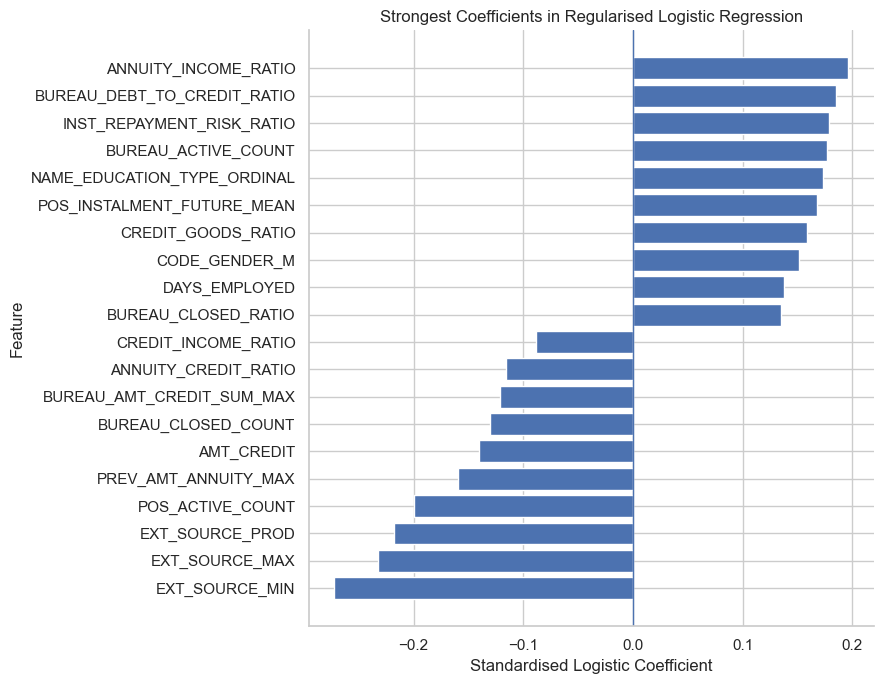

Saved: fig_regularised_logistic_coefficients.png

Logistic modelling section completed.
Main output files:
1. logistic_top50_features.csv
2. payoff_scenarios_used_for_logistic_models.csv
3. regularised_logistic_validation_comparison.csv
4. logistic_baseline_vs_regularised_validation.csv
5. final_test_summary_logistic_models_three_thresholds.csv
6. final_test_detail_plain_logistic_three_thresholds.csv
7. final_test_detail_regularised_logistic_three_thresholds.csv
8. final_model_comparison_by_payoff_scenario.csv
9. logistic_model_coefficients.csv
10. fig_regularised_logistic_coefficients.png
Random Forest modelling uses full feature set only.
Train shape: (184506, 268)
Validation shape: (61502, 268)
Test shape: (61503, 268)
Main payoff-based threshold: 0.2162


In [ ]:


# Three feature sets
X_train_full  = train_dummy.drop(columns=['TARGET'])
X_valid_full  = validation_dummy.drop(columns=['TARGET'])
X_test_full   = test_dummy.drop(columns=['TARGET'])

y_train_arr   = train_dummy['TARGET'].astype(int).values
y_valid_arr   = validation_dummy['TARGET'].astype(int).values
y_test_arr    = test_dummy['TARGET'].astype(int).values

X_train_top50 = X_train_full[selected]
X_valid_top50 = X_valid_full[selected]
X_test_top50  = X_test_full[selected]

ext_cols = [c for c in X_train_full.columns
            if 'EXT_SOURCE' in c.upper() or c.upper().startswith('EXT_')]
X_train_no_ext = X_train_full.drop(columns=ext_cols)
X_valid_no_ext = X_valid_full.drop(columns=ext_cols)
X_test_no_ext  = X_test_full.drop(columns=ext_cols)

# Persist the top 50 list with metadata
top50_df = pd.DataFrame({
    'rank'    : range(1, len(top50) + 1),
    'feature' : top50.index,
    'family'  : [get_family(f) for f in top50.index],
    'mi_score': top50.values,
})
top50_df.to_csv('top50_features.csv', index=False)

print('Feature sets ready:')
print(f'  Full  : train {X_train_full.shape}, val {X_valid_full.shape}, test {X_test_full.shape}')
print(f'  Top50 : train {X_train_top50.shape}, val {X_valid_top50.shape}, test {X_test_top50.shape}')
print(f'  NoExt : train {X_train_no_ext.shape}, val {X_valid_no_ext.shape}, test {X_test_no_ext.shape}')
print(f'  Targets shape: {y_train_arr.shape}, {y_valid_arr.shape}, {y_test_arr.shape}')
print(f'\nSaved: top50_features.csv ({len(top50_df)} rows)')


# Payoff matrix assumptions and Robustness scenarios

import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

if "train_df" in globals():
    payoff_train = train_df.copy()
elif "train_dummy" in globals():
    payoff_train = train_dummy.copy()
else:
    payoff_train = pd.read_csv(DATA_PATH.parent / "train.csv")

payoff_train.columns = payoff_train.columns.str.strip()

C_data_mean = payoff_train["AMT_CREDIT"].mean()

C = 600000

print("Train-set average AMT_CREDIT:", round(C_data_mean, 2))
print("Representative loan amount used in payoff matrix:", C)


r_L = 0.12   # consumer/personal loan interest rate, e.g. 16.06%
r_f = 0.04     # risk-free / alternative return, e.g. 4%
T = 2          # loan term in years
LGD = 0.50     # loss given default, 50%

approve_repay = C * r_L * T
reject_repay = C * r_f * T

approve_default = -LGD * C
reject_default = C * r_f * T

payoff_matrix = pd.DataFrame({
    "Approve": [approve_repay, approve_default],
    "Reject": [reject_repay, reject_default]
}, index=["Repays_TARGET_0", "Defaults_TARGET_1"])

print("\nPayoff matrix:")
display(payoff_matrix)


L_FP = approve_repay - reject_repay
L_FN = reject_default - approve_default

threshold = L_FP / (L_FP + L_FN)

print("\nL_FP:", round(L_FP, 2))
print("L_FN:", round(L_FN, 2))
print("Payoff-based threshold:", round(threshold, 4))

payoff_matrix.to_csv("payoff_matrix_main.csv")

payoff_threshold_main = pd.DataFrame([{
    "scenario": "Main",
    "C_train_average_credit": C_data_mean,
    "C_representative_used": C,
    "r_L": r_L,
    "r_f": r_f,
    "T": T,
    "LGD": LGD,
    "approve_repay": approve_repay,
    "reject_repay": reject_repay,
    "approve_default": approve_default,
    "reject_default": reject_default,
    "L_FP": L_FP,
    "L_FN": L_FN,
    "threshold": threshold
}])

payoff_threshold_main.to_csv("payoff_threshold_main.csv", index=False)

print("\nSaved:")
print("payoff_matrix_main.csv")
print("payoff_threshold_main.csv")

from IPython.display import display

scenarios = {
    "Conservative": {
        "r_L": 0.09,
        "r_f": 0.04,
        "T": 2,
        "LGD": 0.70
    },
    "Balanced": {
        "r_L": 0.12,
        "r_f": 0.04,
        "T": 2,
        "LGD": 0.50
    },
    "Growth_oriented": {
        "r_L": 0.15,
        "r_f": 0.04,
        "T": 2,
        "LGD": 0.30
    }
}

scenario_rows = []
scenario_matrix_list = []

for scenario_name, s in scenarios.items():

    r_L_s = s["r_L"]
    r_f_s = s["r_f"]
    T_s = s["T"]
    LGD_s = s["LGD"]


    # Payoff values for this scenario

    approve_repay_s = C * r_L_s * T_s
    reject_repay_s = C * r_f_s * T_s

    approve_default_s = -LGD_s * C
    reject_default_s = C * r_f_s * T_s

    # Construct payoff matrix for this scenario

    payoff_matrix_s = pd.DataFrame({
        "Approve": [approve_repay_s, approve_default_s],
        "Reject": [reject_repay_s, reject_default_s]
    }, index=["Repays_TARGET_0", "Defaults_TARGET_1"])

    print(f"\nPayoff matrix: {scenario_name}")
    display(payoff_matrix_s)

    matrix_long = (
        payoff_matrix_s
        .reset_index()
        .rename(columns={"index": "true_outcome"})
    )

    matrix_long["scenario"] = scenario_name
    matrix_long["r_L"] = r_L_s
    matrix_long["r_f"] = r_f_s
    matrix_long["T"] = T_s
    matrix_long["LGD"] = LGD_s

    scenario_matrix_list.append(matrix_long)

    L_FP_s = approve_repay_s - reject_repay_s
    L_FN_s = reject_default_s - approve_default_s

    threshold_s = L_FP_s / (L_FP_s + L_FN_s)

    scenario_rows.append({
        "scenario": scenario_name,
        "C_train_average_credit": C_data_mean,
        "C_representative_used": C,
        "r_L": r_L_s,
        "r_f": r_f_s,
        "T": T_s,
        "LGD": LGD_s,
        "approve_repay": approve_repay_s,
        "reject_repay": reject_repay_s,
        "approve_default": approve_default_s,
        "reject_default": reject_default_s,
        "L_FP": L_FP_s,
        "L_FN": L_FN_s,
        "threshold": threshold_s
    })

payoff_scenarios = pd.DataFrame(scenario_rows)

print("\nPayoff robustness threshold summary:")
display(payoff_scenarios)

payoff_matrices_all = pd.concat(scenario_matrix_list, ignore_index=True)

print("\nAll scenario payoff matrices in long format:")
display(payoff_matrices_all)

payoff_scenarios.to_csv("payoff_threshold_scenarios.csv", index=False)
payoff_matrices_all.to_csv("payoff_matrix_scenarios_long.csv", index=False)

print("\nSaved:")
print("payoff_threshold_scenarios.csv")
print("payoff_matrix_scenarios_long.csv")

def evaluate_payoff(y_true, y_proba, payoff_row):

    threshold = payoff_row["threshold"]

    approve_repay = payoff_row["approve_repay"]
    reject_repay = payoff_row["reject_repay"]
    approve_default = payoff_row["approve_default"]
    reject_default = payoff_row["reject_default"]

    y_true = np.array(y_true)
    y_proba = np.array(y_proba)

    decision_reject = (y_proba >= threshold).astype(int)

    payoff = np.zeros(len(y_true))

    payoff[(y_true == 0) & (decision_reject == 0)] = approve_repay

    payoff[(y_true == 0) & (decision_reject == 1)] = reject_repay

    payoff[(y_true == 1) & (decision_reject == 0)] = approve_default

    payoff[(y_true == 1) & (decision_reject == 1)] = reject_default

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        decision_reject,
        labels=[0, 1]
    ).ravel()

    result = {
        "threshold": threshold,
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "TN_good_approved": tn,
        "FP_good_rejected": fp,
        "FN_default_approved": fn,
        "TP_default_rejected": tp,
        "approval_rate": (decision_reject == 0).mean(),
        "rejection_rate": (decision_reject == 1).mean(),
        "total_payoff": payoff.sum(),
        "average_payoff_per_applicant": payoff.mean()
    }

    return result


print("\nFunction created: evaluate_payoff()")
print("Shared evaluation function for consistent validation payoff comparison.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from IPython.display import display

from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)


# sklearn version compatibility
# sklearn >= 1.2 uses penalty=None
# older sklearn uses penalty="none"
try:
    from packaging import version
    NO_PENALTY = None if version.parse(sklearn.__version__) >= version.parse("1.2") else "none"
except Exception:
    NO_PENALTY = "none"

print("sklearn version:", sklearn.__version__)
print("NO_PENALTY setting:", NO_PENALTY)



# 1. Check cleaned datasets


required_dfs = {
    "train_dummy": train_dummy,
    "validation_dummy": validation_dummy,
    "test_dummy": test_dummy
}

for name, df_check in required_dfs.items():
    if "TARGET" not in df_check.columns:
        raise ValueError(f"{name} does not contain TARGET.")

    object_cols = df_check.select_dtypes(include=["object", "category"]).columns.tolist()
    if len(object_cols) > 0:
        raise ValueError(f"{name} still has non-numeric columns: {object_cols[:10]}")

    missing_count = df_check.isna().sum().sum()
    if missing_count > 0:
        raise ValueError(f"{name} still contains missing values: {missing_count}")

    numeric_values = df_check.select_dtypes(include=[np.number]).to_numpy()
    if not np.isfinite(numeric_values).all():
        raise ValueError(f"{name} still contains inf or -inf values.")

assert train_dummy.columns.equals(validation_dummy.columns), "train and validation columns do not match."
assert train_dummy.columns.equals(test_dummy.columns), "train and test columns do not match."

print("\nCleaned datasets are ready.")
print("train_dummy shape     :", train_dummy.shape)
print("validation_dummy shape:", validation_dummy.shape)
print("test_dummy shape      :", test_dummy.shape)
print("Train default rate    :", round(train_dummy["TARGET"].mean(), 4))
print("Validation default rate:", round(validation_dummy["TARGET"].mean(), 4))
print("Test default rate     :", round(test_dummy["TARGET"].mean(), 4))



# 2. Prepare X and y


X_train_full = train_dummy.drop(columns=["TARGET"])
X_valid_full = validation_dummy.drop(columns=["TARGET"])
X_test_full  = test_dummy.drop(columns=["TARGET"])

y_train = train_dummy["TARGET"].astype(int).values
y_valid = validation_dummy["TARGET"].astype(int).values
y_test  = test_dummy["TARGET"].astype(int).values

print("\nFull feature set:")
print("X_train_full:", X_train_full.shape)
print("X_valid_full:", X_valid_full.shape)
print("X_test_full :", X_test_full.shape)

# 3. Feature selection: Top 50 for Logistic Regression
TOP_K = 50
CORR_THRESHOLD = 0.90
CANDIDATE_POOL_SIZE = min(200, X_train_full.shape[1])

FAMILY_CAP = {
    "EXT_SOURCE": 5,
    "AMT_RAW": 3,
    "AMT_RATIO": 6,
    "DAYS": 5,
    "BUREAU": 9,
    "PREV": 7,
    "INST": 7,
    "POS": 5,
    "OTHER": 15,
}

def get_family(col):
    c = str(col).upper()

    if "EXT_SOURCE" in c or c.startswith("EXT_"):
        return "EXT_SOURCE"

    if c in ["AMT_CREDIT", "AMT_GOODS_PRICE", "AMT_ANNUITY", "AMT_INCOME_TOTAL"]:
        return "AMT_RAW"

    if (
        c.startswith("AMT_")
        or ("INCOME" in c and "RATIO" in c)
        or ("CREDIT" in c and "RATIO" in c)
        or ("ANNUITY" in c and "RATIO" in c)
        or c in [
            "INCOME_PER_FAM_MEMBER",
            "INCOME_PER_ADULT",
            "CREDIT_TERM",
            "EMPLOYED_TO_AGE_RATIO"
        ]
    ):
        return "AMT_RATIO"

    if c.startswith("DAYS_") or c in ["AGE_YEARS", "EMPLOYED_YEARS", "DAYS_EMPLOYED_ANOMALY"]:
        return "DAYS"

    if c.startswith("BUREAU_") or c in ["NO_BUREAU_HISTORY", "NO_BUREAU_ENQ_HISTORY"]:
        return "BUREAU"

    if c.startswith("PREV_") or c == "NO_PREV_HISTORY":
        return "PREV"

    if c.startswith("INST_") or c == "NO_INST_HISTORY":
        return "INST"

    if c.startswith("POS_") or c == "NO_POS_HISTORY":
        return "POS"

    return "OTHER"


if "selected" in globals() and len(selected) > 0:
    selected_features = [c for c in list(selected) if c in X_train_full.columns]
    print("\nUsing existing selected feature list.")
    print("Number of selected features:", len(selected_features))

else:
    print("\nNo existing selected list found. Calculating Top 50 features...")

    discrete_mask = np.array([
        set(X_train_full[col].dropna().unique()).issubset({0, 1, 0.0, 1.0})
        or (X_train_full[col].nunique() <= 30)
        for col in X_train_full.columns
    ])

    mi_scores = mutual_info_classif(
        X_train_full.values,
        y_train,
        discrete_features=discrete_mask,
        random_state=SEED,
        n_jobs=1
    )

    mi_series = pd.Series(mi_scores, index=X_train_full.columns).sort_values(ascending=False)

    candidate_pool = mi_series.head(CANDIDATE_POOL_SIZE).index.tolist()
    corr_matrix = X_train_full[candidate_pool].corr().abs()

    selected_features = []
    family_count = {}

    for feat in candidate_pool:
        if len(selected_features) >= TOP_K:
            break

        fam = get_family(feat)

        if family_count.get(fam, 0) >= FAMILY_CAP.get(fam, 999):
            continue

        if len(selected_features) == 0:
            selected_features.append(feat)
            family_count[fam] = family_count.get(fam, 0) + 1
            continue

        max_corr = corr_matrix.loc[feat, selected_features].max()

        if max_corr < CORR_THRESHOLD:
            selected_features.append(feat)
            family_count[fam] = family_count.get(fam, 0) + 1

    print("Selected features:", len(selected_features))


# Safety fallback
if len(selected_features) == 0:
    raise ValueError("No selected features found. Please check the feature selection step.")

X_train_top50 = X_train_full[selected_features]
X_valid_top50 = X_valid_full[selected_features]
X_test_top50  = X_test_full[selected_features]

top50_features_df = pd.DataFrame({
    "rank": range(1, len(selected_features) + 1),
    "feature": selected_features,
    "family": [get_family(f) for f in selected_features]
})

print("\nTop 50 feature set:")
print("X_train_top50:", X_train_top50.shape)
print("X_valid_top50:", X_valid_top50.shape)
print("X_test_top50 :", X_test_top50.shape)

display(top50_features_df.head(20))
top50_features_df.to_csv("logistic_top50_features.csv", index=False)
print("Saved: logistic_top50_features.csv")

# 4. Payoff scenarios and three thresholds

if "payoff_scenarios" in globals():
    required_cols = [
        "scenario", "threshold",
        "approve_repay", "reject_repay",
        "approve_default", "reject_default"
    ]
    missing_cols = [c for c in required_cols if c not in payoff_scenarios.columns]

    if len(missing_cols) == 0:
        payoff_scenarios_model = payoff_scenarios.copy()
        print("\nUsing existing payoff_scenarios.")
    else:
        print("\nExisting payoff_scenarios missing required columns. Rebuilding payoff_scenarios.")
        payoff_scenarios_model = None
else:
    payoff_scenarios_model = None


if payoff_scenarios_model is None:

    C = 600000

    scenarios = {
        "Conservative": {
            "r_L": 0.09,
            "r_f": 0.04,
            "T": 2,
            "LGD": 0.70
        },
        "Balanced": {
            "r_L": 0.12,
            "r_f": 0.04,
            "T": 2,
            "LGD": 0.50
        },
        "Growth_oriented": {
            "r_L": 0.15,
            "r_f": 0.04,
            "T": 2,
            "LGD": 0.30
        }
    }

    scenario_rows = []

    for scenario_name, s in scenarios.items():
        r_L = s["r_L"]
        r_f = s["r_f"]
        T = s["T"]
        LGD = s["LGD"]

        approve_repay = C * r_L * T
        reject_repay = C * r_f * T

        approve_default = -LGD * C
        reject_default = C * r_f * T

        L_FP = approve_repay - reject_repay
        L_FN = reject_default - approve_default

        threshold = L_FP / (L_FP + L_FN)

        scenario_rows.append({
            "scenario": scenario_name,
            "C_representative_used": C,
            "r_L": r_L,
            "r_f": r_f,
            "T": T,
            "LGD": LGD,
            "approve_repay": approve_repay,
            "reject_repay": reject_repay,
            "approve_default": approve_default,
            "reject_default": reject_default,
            "L_FP": L_FP,
            "L_FN": L_FN,
            "threshold": threshold
        })

    payoff_scenarios_model = pd.DataFrame(scenario_rows)

print("\nPayoff scenarios used for model evaluation:")
display(
    payoff_scenarios_model[
        [
            "scenario",
            "r_L",
            "r_f",
            "T",
            "LGD",
            "approve_repay",
            "reject_repay",
            "approve_default",
            "reject_default",
            "threshold"
        ]
    ]
)

payoff_scenarios_model.to_csv("payoff_scenarios_used_for_logistic_models.csv", index=False)
print("Saved: payoff_scenarios_used_for_logistic_models.csv")

# Select Balanced scenario for validation model selection
if "Balanced" in payoff_scenarios_model["scenario"].values:
    validation_payoff_row = payoff_scenarios_model[
        payoff_scenarios_model["scenario"] == "Balanced"
    ].iloc[0]
else:
    validation_payoff_row = payoff_scenarios_model.iloc[0]

print("\nValidation model-selection scenario:", validation_payoff_row["scenario"])
print("Validation threshold:", round(validation_payoff_row["threshold"], 4))

# 5. Evaluation functions

def make_payoff_table(y_true, y_proba, payoff_row):

    threshold = payoff_row["threshold"]

    approve_repay = payoff_row["approve_repay"]
    reject_repay = payoff_row["reject_repay"]
    approve_default = payoff_row["approve_default"]
    reject_default = payoff_row["reject_default"]

    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    # decision_reject = 1 means reject / review
    # decision_reject = 0 means approve
    decision_reject = (y_proba >= threshold).astype(int)

    rows = []

    # TARGET = 0, approve
    mask = (y_true == 0) & (decision_reject == 0)
    rows.append({
        "actual_outcome": "TARGET_0_Repays",
        "model_decision": "Approve",
        "count": int(mask.sum()),
        "payoff_per_applicant": approve_repay,
        "total_payoff": float(mask.sum() * approve_repay)
    })

    # TARGET = 0, reject
    mask = (y_true == 0) & (decision_reject == 1)
    rows.append({
        "actual_outcome": "TARGET_0_Repays",
        "model_decision": "Reject",
        "count": int(mask.sum()),
        "payoff_per_applicant": reject_repay,
        "total_payoff": float(mask.sum() * reject_repay)
    })

    # TARGET = 1, approve
    mask = (y_true == 1) & (decision_reject == 0)
    rows.append({
        "actual_outcome": "TARGET_1_Defaults",
        "model_decision": "Approve",
        "count": int(mask.sum()),
        "payoff_per_applicant": approve_default,
        "total_payoff": float(mask.sum() * approve_default)
    })

    # TARGET = 1, reject
    mask = (y_true == 1) & (decision_reject == 1)
    rows.append({
        "actual_outcome": "TARGET_1_Defaults",
        "model_decision": "Reject",
        "count": int(mask.sum()),
        "payoff_per_applicant": reject_default,
        "total_payoff": float(mask.sum() * reject_default)
    })

    payoff_table = pd.DataFrame(rows)

    return payoff_table


def evaluate_model_one_scenario(model_name, y_true, y_proba, payoff_row):

    threshold = payoff_row["threshold"]

    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    decision_reject = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        decision_reject,
        labels=[0, 1]
    ).ravel()

    payoff_table = make_payoff_table(y_true, y_proba, payoff_row)

    total_payoff = payoff_table["total_payoff"].sum()
    avg_payoff = total_payoff / len(y_true)

    y_proba_clip = np.clip(y_proba, 1e-15, 1 - 1e-15)

    result = {
        "model": model_name,
        "scenario": payoff_row["scenario"],
        "threshold": threshold,

        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba_clip),
        "Brier": brier_score_loss(y_true, y_proba_clip),

        "TN_good_approved": int(tn),
        "FP_good_rejected": int(fp),
        "FN_default_approved": int(fn),
        "TP_default_rejected": int(tp),

        "approval_rate": float((decision_reject == 0).mean()),
        "rejection_rate": float((decision_reject == 1).mean()),

        "default_recall": float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
        "default_precision": float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0,

        "total_payoff": float(total_payoff),
        "average_payoff_per_applicant": float(avg_payoff)
    }

    return result, payoff_table


def evaluate_model_three_scenarios(model_name, y_true, y_proba, payoff_scenarios_df):

    summary_rows = []
    detailed_tables = []

    for _, payoff_row in payoff_scenarios_df.iterrows():

        summary, detail = evaluate_model_one_scenario(
            model_name=model_name,
            y_true=y_true,
            y_proba=y_proba,
            payoff_row=payoff_row
        )

        summary_rows.append(summary)

        detail = detail.copy()
        detail["model"] = model_name
        detail["scenario"] = payoff_row["scenario"]
        detail["threshold"] = payoff_row["threshold"]

        detailed_tables.append(detail)

    summary_df = pd.DataFrame(summary_rows)
    detailed_df = pd.concat(detailed_tables, ignore_index=True)

    return summary_df, detailed_df

# 6. Logistic Regression Baseline Model

logistic_baseline_train = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty=NO_PENALTY,
        solver="lbfgs",
        max_iter=10000,
        random_state=SEED
    ))
])

print("\nFitting Plain Logistic Regression Baseline...")
logistic_baseline_train.fit(X_train_top50, y_train)

y_valid_proba_baseline = logistic_baseline_train.predict_proba(X_valid_top50)[:, 1]

baseline_valid_summary, baseline_valid_detail = evaluate_model_one_scenario(
    model_name="Plain Logistic Regression Baseline",
    y_true=y_valid,
    y_proba=y_valid_proba_baseline,
    payoff_row=validation_payoff_row
)

print("\nValidation result: Plain Logistic Regression Baseline")
display(pd.DataFrame([baseline_valid_summary]))
display(baseline_valid_detail)

# 7. Regularised Logistic Regression Model Selection

C_grid = [0.01, 0.03, 0.10, 0.30, 1.00, 3.00, 10.00]

regularised_validation_rows = []

print("\nFitting L2 Regularised Logistic Regression models...")

for C_value in C_grid:

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            C=C_value,
            solver="lbfgs",
            max_iter=10000,
            random_state=SEED
        ))
    ])

    model.fit(X_train_top50, y_train)

    y_valid_proba = model.predict_proba(X_valid_top50)[:, 1]

    summary, detail = evaluate_model_one_scenario(
        model_name=f"L2 Regularised Logistic Regression C={C_value}",
        y_true=y_valid,
        y_proba=y_valid_proba,
        payoff_row=validation_payoff_row
    )

    summary["C"] = C_value
    regularised_validation_rows.append(summary)

regularised_validation_results = pd.DataFrame(regularised_validation_rows)

regularised_validation_results = regularised_validation_results.sort_values(
    by=["average_payoff_per_applicant", "PR_AUC", "ROC_AUC"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\nRegularised Logistic Regression validation comparison:")
display(
    regularised_validation_results[
        [
            "model",
            "C",
            "ROC_AUC",
            "PR_AUC",
            "LogLoss",
            "Brier",
            "approval_rate",
            "rejection_rate",
            "default_recall",
            "default_precision",
            "average_payoff_per_applicant",
            "total_payoff"
        ]
    ]
)

regularised_validation_results.to_csv(
    "regularised_logistic_validation_comparison.csv",
    index=False
)

best_C = float(regularised_validation_results.iloc[0]["C"])

print("\nBest C selected by validation payoff:", best_C)
print("Saved: regularised_logistic_validation_comparison.csv")

# 8. Compare baseline logistic vs regularised logistic on validation
baseline_valid_result_df = pd.DataFrame([baseline_valid_summary])
baseline_valid_result_df["C"] = np.nan

validation_model_comparison = pd.concat(
    [
        baseline_valid_result_df,
        regularised_validation_results
    ],
    ignore_index=True
)

validation_model_comparison = validation_model_comparison.sort_values(
    by=["average_payoff_per_applicant", "PR_AUC", "ROC_AUC"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\nValidation comparison: baseline vs regularised logistic")
display(
    validation_model_comparison[
        [
            "model",
            "C",
            "ROC_AUC",
            "PR_AUC",
            "LogLoss",
            "Brier",
            "approval_rate",
            "rejection_rate",
            "default_recall",
            "default_precision",
            "average_payoff_per_applicant",
            "total_payoff"
        ]
    ]
)

validation_model_comparison.to_csv(
    "logistic_baseline_vs_regularised_validation.csv",
    index=False
)

print("Saved: logistic_baseline_vs_regularised_validation.csv")

# 9. Refit final models on train + validation

X_train_valid_top50 = pd.concat([X_train_top50, X_valid_top50], axis=0)
y_train_valid = np.concatenate([y_train, y_valid])

print("\nRefitting final models on train + validation...")

# Final plain logistic baseline
final_logistic_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty=NO_PENALTY,
        solver="lbfgs",
        max_iter=10000,
        random_state=SEED
    ))
])

final_logistic_baseline.fit(X_train_valid_top50, y_train_valid)

# Final regularised logistic regression
final_regularised_logistic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=best_C,
        solver="lbfgs",
        max_iter=10000,
        random_state=SEED
    ))
])

final_regularised_logistic.fit(X_train_valid_top50, y_train_valid)

print("Final models fitted.")
print("Final baseline logistic: no regularisation")
print("Final regularised logistic: L2, C =", best_C)

# 10. Final test-set predicted probabilities

y_test_proba_baseline = final_logistic_baseline.predict_proba(X_test_top50)[:, 1]
y_test_proba_regularised = final_regularised_logistic.predict_proba(X_test_top50)[:, 1]

print("\nPredicted probabilities generated for test set.")
print("Baseline proba range    :", round(y_test_proba_baseline.min(), 4), "to", round(y_test_proba_baseline.max(), 4))
print("Regularised proba range :", round(y_test_proba_regularised.min(), 4), "to", round(y_test_proba_regularised.max(), 4))

# 11. Final test evaluation under three thresholds

baseline_test_summary, baseline_test_detail = evaluate_model_three_scenarios(
    model_name="Plain Logistic Regression Baseline",
    y_true=y_test,
    y_proba=y_test_proba_baseline,
    payoff_scenarios_df=payoff_scenarios_model
)

regularised_test_summary, regularised_test_detail = evaluate_model_three_scenarios(
    model_name=f"L2 Regularised Logistic Regression C={best_C}",
    y_true=y_test,
    y_proba=y_test_proba_regularised,
    payoff_scenarios_df=payoff_scenarios_model
)

test_summary_all = pd.concat(
    [
        baseline_test_summary,
        regularised_test_summary
    ],
    ignore_index=True
)

test_summary_all = test_summary_all.sort_values(
    by=["scenario", "average_payoff_per_applicant"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nFinal test summary: both models under three payoff thresholds")
display(
    test_summary_all[
        [
            "model",
            "scenario",
            "threshold",
            "ROC_AUC",
            "PR_AUC",
            "LogLoss",
            "Brier",
            "approval_rate",
            "rejection_rate",
            "default_recall",
            "default_precision",
            "TN_good_approved",
            "FP_good_rejected",
            "FN_default_approved",
            "TP_default_rejected",
            "average_payoff_per_applicant",
            "total_payoff"
        ]
    ]
)

test_summary_all.to_csv(
    "final_test_summary_logistic_models_three_thresholds.csv",
    index=False
)

print("Saved: final_test_summary_logistic_models_three_thresholds.csv")

# 12. Detailed payoff tables: Plain Logistic Regression Baseline
print("\n============================================================")
print("Plain Logistic Regression Baseline: Detailed Test Payoff Tables")
print("============================================================")

for scenario_name in payoff_scenarios_model["scenario"]:

    print("\nScenario:", scenario_name)

    temp = baseline_test_detail[
        baseline_test_detail["scenario"] == scenario_name
    ].copy()

    display(
        temp[
            [
                "scenario",
                "threshold",
                "actual_outcome",
                "model_decision",
                "count",
                "payoff_per_applicant",
                "total_payoff"
            ]
        ]
    )

baseline_test_detail.to_csv(
    "final_test_detail_plain_logistic_three_thresholds.csv",
    index=False
)

print("Saved: final_test_detail_plain_logistic_three_thresholds.csv")

# 13. Detailed payoff tables: Regularised Logistic Regression
print("\n============================================================")
print("Regularised Logistic Regression: Detailed Test Payoff Tables")
print("============================================================")

for scenario_name in payoff_scenarios_model["scenario"]:

    print("\nScenario:", scenario_name)

    temp = regularised_test_detail[
        regularised_test_detail["scenario"] == scenario_name
    ].copy()

    display(
        temp[
            [
                "scenario",
                "threshold",
                "actual_outcome",
                "model_decision",
                "count",
                "payoff_per_applicant",
                "total_payoff"
            ]
        ]
    )

regularised_test_detail.to_csv(
    "final_test_detail_regularised_logistic_three_thresholds.csv",
    index=False
)

print("Saved: final_test_detail_regularised_logistic_three_thresholds.csv")

# 14. Scenario-by-scenario model comparison table

comparison_table = test_summary_all[
    [
        "scenario",
        "model",
        "threshold",
        "ROC_AUC",
        "PR_AUC",
        "approval_rate",
        "rejection_rate",
        "default_recall",
        "default_precision",
        "average_payoff_per_applicant",
        "total_payoff"
    ]
].copy()

comparison_table = comparison_table.sort_values(
    by=["scenario", "average_payoff_per_applicant"],
    ascending=[True, False]
)

print("\nFinal model comparison by payoff scenario:")
display(comparison_table)

comparison_table.to_csv(
    "final_model_comparison_by_payoff_scenario.csv",
    index=False
)

print("Saved: final_model_comparison_by_payoff_scenario.csv")

# 15. Coefficient interpretation

baseline_lr = final_logistic_baseline.named_steps["model"]
regularised_lr = final_regularised_logistic.named_steps["model"]

baseline_coef = pd.DataFrame({
    "feature": X_train_top50.columns,
    "coefficient": baseline_lr.coef_[0],
    "abs_coefficient": np.abs(baseline_lr.coef_[0]),
    "model": "Plain Logistic Regression Baseline"
})

regularised_coef = pd.DataFrame({
    "feature": X_train_top50.columns,
    "coefficient": regularised_lr.coef_[0],
    "abs_coefficient": np.abs(regularised_lr.coef_[0]),
    "model": f"L2 Regularised Logistic Regression C={best_C}"
})

coef_all = pd.concat([baseline_coef, regularised_coef], ignore_index=True)

coef_all.to_csv("logistic_model_coefficients.csv", index=False)

print("\nTop positive coefficients in regularised model: increase predicted default risk")
display(
    regularised_coef
    .sort_values("coefficient", ascending=False)
    .head(15)[["feature", "coefficient"]]
)

print("\nTop negative coefficients in regularised model: reduce predicted default risk")
display(
    regularised_coef
    .sort_values("coefficient", ascending=True)
    .head(15)[["feature", "coefficient"]]
)

print("Saved: logistic_model_coefficients.csv")


# 16. Coefficient plot for report

top_positive = (
    regularised_coef
    .sort_values("coefficient", ascending=False)
    .head(10)
)

top_negative = (
    regularised_coef
    .sort_values("coefficient", ascending=True)
    .head(10)
)

coef_plot_df = pd.concat([top_negative, top_positive], axis=0)
coef_plot_df = coef_plot_df.sort_values("coefficient")

plt.figure(figsize=(9, 7))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardised Logistic Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Coefficients in Regularised Logistic Regression")
plt.tight_layout()
plt.savefig("fig_regularised_logistic_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: fig_regularised_logistic_coefficients.png")


# 17. Final output checklist

print("\n============================================================")
print("Logistic modelling section completed.")
print("Main output files:")
print("1. logistic_top50_features.csv")
print("2. payoff_scenarios_used_for_logistic_models.csv")
print("3. regularised_logistic_validation_comparison.csv")
print("4. logistic_baseline_vs_regularised_validation.csv")
print("5. final_test_summary_logistic_models_three_thresholds.csv")
print("6. final_test_detail_plain_logistic_three_thresholds.csv")
print("7. final_test_detail_regularised_logistic_three_thresholds.csv")
print("8. final_model_comparison_by_payoff_scenario.csv")
print("9. logistic_model_coefficients.csv")
print("10. fig_regularised_logistic_coefficients.png")
print("============================================================")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Use the main payoff scenario for model selection
main_payoff_row = payoff_threshold_main.iloc[0]
main_threshold = main_payoff_row["threshold"]

print("Random Forest modelling uses full feature set only.")
print("Train shape:", X_train_full.shape)
print("Validation shape:", X_valid_full.shape)
print("Test shape:", X_test_full.shape)
print("Main payoff-based threshold:", round(main_threshold, 4))

# Random forest


In [ ]:


# Helper function for model evaluation


def evaluate_rf_experiment(
    model_name,
    model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    payoff_row
):
    """
    Fit a Random Forest model and evaluate it on the validation set.

    The model predicts P(TARGET = 1), where TARGET = 1 means payment difficulty / default.
    The lending decision is made using the payoff-based threshold:
        predicted probability >= threshold  -> reject / manual review
        predicted probability < threshold   -> approve
    """

    # Fit model
    model.fit(X_train, y_train)

    # Predicted default probabilities
    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]

    # Standard predictive metrics
    train_roc_auc = roc_auc_score(y_train, train_proba)
    valid_roc_auc = roc_auc_score(y_valid, valid_proba)

    train_pr_auc = average_precision_score(y_train, train_proba)
    valid_pr_auc = average_precision_score(y_valid, valid_proba)

    # Business payoff evaluation
    payoff_result = evaluate_payoff(
        y_true=y_valid,
        y_proba=valid_proba,
        payoff_row=payoff_row
    )

    result = {
        "model": model_name,
        "train_ROC_AUC": train_roc_auc,
        "valid_ROC_AUC": valid_roc_auc,
        "train_PR_AUC": train_pr_auc,
        "valid_PR_AUC": valid_pr_auc,
        "AUC_gap": train_roc_auc - valid_roc_auc,
        "threshold": payoff_result["threshold"],
        "approval_rate": payoff_result["approval_rate"],
        "rejection_rate": payoff_result["rejection_rate"],
        "valid_total_payoff": payoff_result["total_payoff"],
        "valid_avg_payoff": payoff_result["average_payoff_per_applicant"],
        "TN_good_approved": payoff_result["TN_good_approved"],
        "FP_good_rejected": payoff_result["FP_good_rejected"],
        "FN_default_approved": payoff_result["FN_default_approved"],
        "TP_default_rejected": payoff_result["TP_default_rejected"],
    }

    return result, model, valid_proba

In [ ]:


# Baseline Random Forest - Full Features, No Class Weight

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    max_features="sqrt"
)

baseline_result, baseline_model, baseline_valid_proba = evaluate_rf_experiment(
    model_name="RF_baseline_full_features_no_weight",
    model=rf_baseline,
    X_train=X_train_full,
    y_train=y_train_arr,
    X_valid=X_valid_full,
    y_valid=y_valid_arr,
    payoff_row=main_payoff_row
)

baseline_result_df = pd.DataFrame([baseline_result])

display(baseline_result_df)

,model,train_ROC_AUC,valid_ROC_AUC,train_PR_AUC,valid_PR_AUC,AUC_gap,threshold,approval_rate,rejection_rate,valid_total_payoff,valid_avg_payoff,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected
0,RF_baseline_full_features_no_weight,1.0,0.746826,1.0,0.242684,0.253174,0.216216,0.918474,0.081526,6.816060e+09,110826.639784,52977,3560,3511,1454


In [ ]:


# Tuned Random Forest Experiments - No Class Weight


rf_specs = [
    {
        "model_name": "RF_depth8_leaf30_no_weight",
        "n_estimators": 400,
        "max_depth": 8,
        "min_samples_leaf": 30,
        "min_samples_split": 80,
        "max_features": "sqrt"
    },
    {
        "model_name": "RF_depth10_leaf20_no_weight",
        "n_estimators": 500,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "min_samples_split": 60,
        "max_features": "sqrt"
    },
    {
        "model_name": "RF_depth12_leaf15_no_weight",
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 15,
        "min_samples_split": 50,
        "max_features": "sqrt"
    },
    {
        "model_name": "RF_depth15_leaf10_no_weight",
        "n_estimators": 500,
        "max_depth": 15,
        "min_samples_leaf": 10,
        "min_samples_split": 40,
        "max_features": "sqrt"
    },
    {
        "model_name": "RF_depth18_leaf5_no_weight",
        "n_estimators": 500,
        "max_depth": 18,
        "min_samples_leaf": 5,
        "min_samples_split": 30,
        "max_features": "sqrt"
    },
    {
        "model_name": "RF_depth20_leaf5_no_weight",
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 5,
        "min_samples_split": 20,
        "max_features": "sqrt"
    }
]

rf_results = []
rf_models = {}
rf_valid_probas = {}

# Add baseline result first
rf_results.append(baseline_result)
rf_models["RF_baseline_full_features_no_weight"] = baseline_model
rf_valid_probas["RF_baseline_full_features_no_weight"] = baseline_valid_proba

for spec in rf_specs:

    model_name = spec["model_name"]

    params = spec.copy()
    params.pop("model_name")

    rf_model = RandomForestClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1
    )

    result, fitted_model, valid_proba = evaluate_rf_experiment(
        model_name=model_name,
        model=rf_model,
        X_train=X_train_full,
        y_train=y_train_arr,
        X_valid=X_valid_full,
        y_valid=y_valid_arr,
        payoff_row=main_payoff_row
    )

    # Store model parameters in the result table
    result.update(params)

    rf_results.append(result)
    rf_models[model_name] = fitted_model
    rf_valid_probas[model_name] = valid_proba

rf_results_df = pd.DataFrame(rf_results)

rf_results_df = rf_results_df.sort_values(
    by=["valid_avg_payoff", "valid_PR_AUC", "valid_ROC_AUC"],
    ascending=False
)

display(rf_results_df)

,model,train_ROC_AUC,valid_ROC_AUC,train_PR_AUC,valid_PR_AUC,AUC_gap,threshold,approval_rate,rejection_rate,valid_total_payoff,valid_avg_payoff,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features
6,RF_depth20_leaf5_no_weight,0.977944,0.757518,0.848757,0.253469,0.220426,0.216216,0.938295,0.061705,6.840732e+09,111227.797470,53988,2549,3719,1246,500.0,20.0,5.0,20.0,sqrt
5,RF_depth18_leaf5_no_weight,0.954461,0.758154,0.735533,0.251742,0.196307,0.216216,0.941595,0.058405,6.838908e+09,111198.139898,54143,2394,3767,1198,500.0,18.0,5.0,30.0,sqrt
4,RF_depth15_leaf10_no_weight,0.911742,0.759446,0.578422,0.252078,0.152295,0.216216,0.945920,0.054080,6.837804e+09,111180.189262,54349,2188,3827,1138,500.0,15.0,10.0,40.0,sqrt
3,RF_depth12_leaf15_no_weight,0.856949,0.758267,0.439566,0.249348,0.098681,0.216216,0.950912,0.049088,6.830424e+09,111060.193164,54573,1964,3910,1055,500.0,12.0,15.0,50.0,sqrt
0,RF_baseline_full_features_no_weight,1.000000,0.746826,1.000000,0.242684,0.253174,0.216216,0.918474,0.081526,6.816060e+09,110826.639784,52977,3560,3511,1454,NaN,NaN,NaN,NaN,NaN
2,RF_depth10_leaf20_no_weight,0.816052,0.755553,0.356186,0.245374,0.060499,0.216216,0.957253,0.042747,6.810588e+09,110737.667068,54834,1703,4039,926,500.0,10.0,20.0,60.0,sqrt
1,RF_depth8_leaf30_no_weight,0.780966,0.751260,0.292998,0.240648,0.029706,0.216216,0.964749,0.035251,6.784692e+09,110316.607590,55137,1400,4197,768,400.0,8.0,30.0,80.0,sqrt


In [ ]:


# Select Best Random Forest on Validation Set

best_rf_name = "RF_depth15_leaf10_no_weight"

best_rf_model = rf_models[best_rf_name]
best_valid_proba = rf_valid_probas[best_rf_name]

best_rf_row = rf_results_df[rf_results_df["model"] == best_rf_name].iloc[0]

print("Selected Random Forest model:")
print(best_rf_name)

display(pd.DataFrame([best_rf_row]))

Selected Random Forest model:
RF_depth15_leaf10_no_weight


,model,train_ROC_AUC,valid_ROC_AUC,train_PR_AUC,valid_PR_AUC,AUC_gap,threshold,approval_rate,rejection_rate,valid_total_payoff,valid_avg_payoff,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features
4,RF_depth15_leaf10_no_weight,0.911742,0.759446,0.578422,0.252078,0.152295,0.216216,0.94592,0.05408,6.837804e+09,111180.189262,54349,2188,3827,1138,500.0,15.0,10.0,40.0,sqrt


In [ ]:


#  Retrain Final Random Forest on Train + Validation Set

# Combine training and validation data for final model fitting
X_dev_full = pd.concat([X_train_full, X_valid_full], axis=0)
y_dev_arr = np.concatenate([y_train_arr, y_valid_arr])

print("Development set shape:", X_dev_full.shape)
print("Development target shape:", y_dev_arr.shape)

# Use the selected hyperparameters from validation selection
final_rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=10,
    min_samples_split=40,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1
)

# Retrain final model on train + validation
final_rf_model.fit(X_dev_full, y_dev_arr)

print("Final Random Forest retrained on train + validation set.")

Development set shape: (246008, 268)
Development target shape: (246008,)
Final Random Forest retrained on train + validation set.


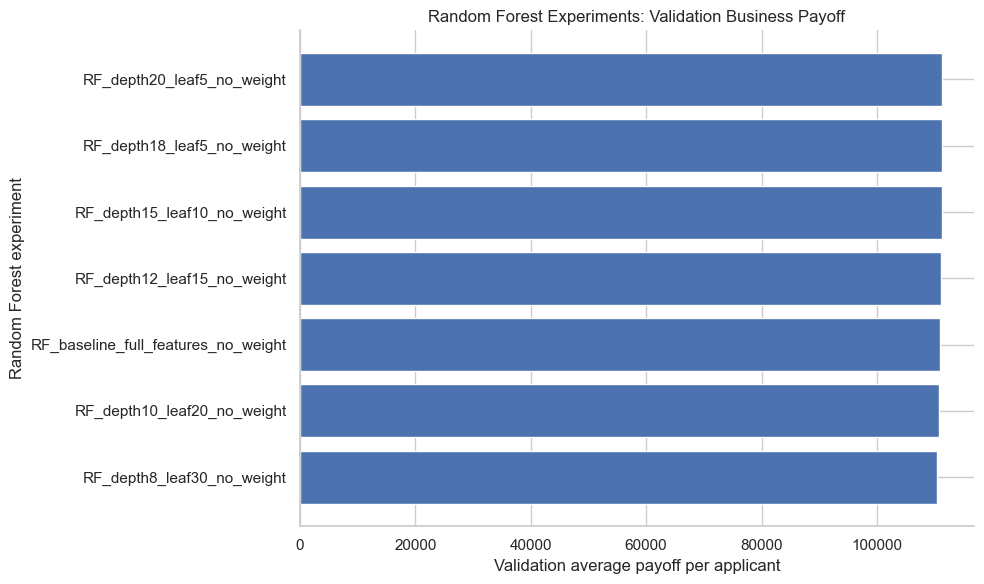

In [ ]:


# Validation Payoff Comparison


plot_df = rf_results_df.copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["model"], plot_df["valid_avg_payoff"])
plt.xlabel("Validation average payoff per applicant")
plt.ylabel("Random Forest experiment")
plt.title("Random Forest Experiments: Validation Business Payoff")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("rf_validation_payoff_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

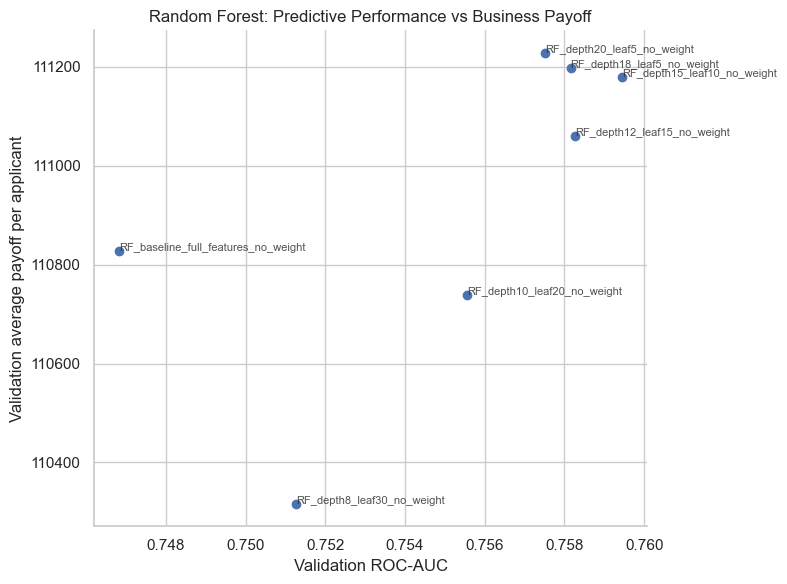

In [ ]:


# Validation ROC-AUC vs Business Payoff

plt.figure(figsize=(8, 6))
plt.scatter(rf_results_df["valid_ROC_AUC"], rf_results_df["valid_avg_payoff"])

for _, row in rf_results_df.iterrows():
    plt.annotate(
        row["model"],
        (row["valid_ROC_AUC"], row["valid_avg_payoff"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Validation ROC-AUC")
plt.ylabel("Validation average payoff per applicant")
plt.title("Random Forest: Predictive Performance vs Business Payoff")
plt.tight_layout()
plt.savefig("rf_auc_vs_payoff.png", dpi=150, bbox_inches="tight")
plt.show()

,Approved,Rejected / Review
Actual good borrower (TARGET=0),54349,2188
Actual default borrower (TARGET=1),3827,1138


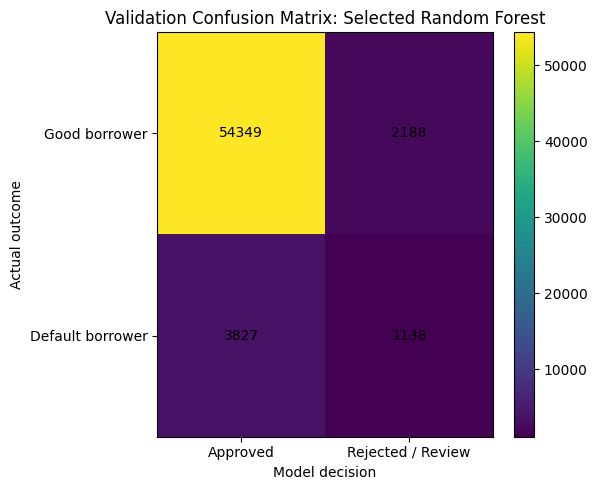

In [ ]:


# Validation Confusion Matrix under Payoff-Based Threshold

valid_decision_reject = (best_valid_proba >= main_threshold).astype(int)

valid_cm = confusion_matrix(
    y_valid_arr,
    valid_decision_reject,
    labels=[0, 1]
)

valid_cm_df = pd.DataFrame(
    valid_cm,
    index=["Actual good borrower (TARGET=0)", "Actual default borrower (TARGET=1)"],
    columns=["Approved", "Rejected / Review"]
)

display(valid_cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(valid_cm, aspect="auto")
plt.xticks([0, 1], ["Approved", "Rejected / Review"])
plt.yticks([0, 1], ["Good borrower", "Default borrower"])
plt.xlabel("Model decision")
plt.ylabel("Actual outcome")
plt.title("Validation Confusion Matrix: Selected Random Forest")

for i in range(valid_cm.shape[0]):
    for j in range(valid_cm.shape[1]):
        plt.text(j, i, valid_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("rf_validation_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

,feature,importance
113,EXT_SOURCE_MEAN,0.066547
117,EXT_SOURCE_PROD,0.062105
114,EXT_SOURCE_MIN,0.043430
115,EXT_SOURCE_MAX,0.038416
13,EXT_SOURCE_2,0.032718
14,EXT_SOURCE_3,0.030032
116,EXT_SOURCE_STD,0.018345
106,CREDIT_GOODS_RATIO,0.015742
12,EXT_SOURCE_1,0.012563
108,EMPLOYED_YEARS,0.012314


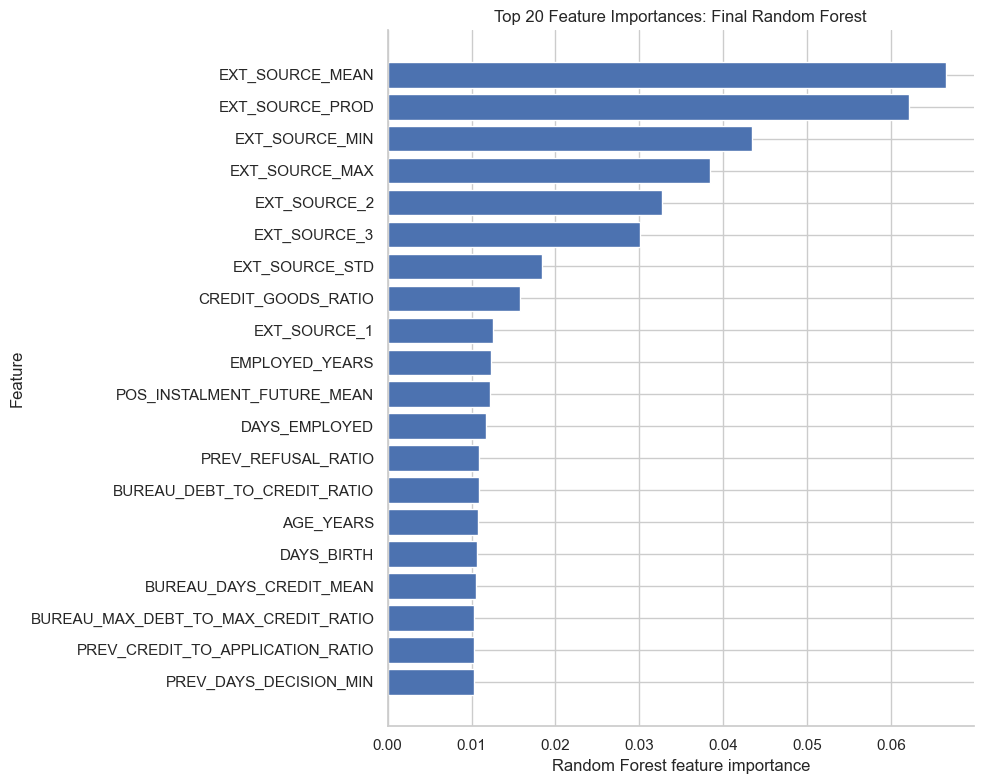

In [ ]:


# Feature Importance for Final Random Forest


importance_df = pd.DataFrame({
    "feature": X_dev_full.columns,
    "importance": final_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(30))

plt.figure(figsize=(10, 8))
top_imp = importance_df.head(20).sort_values("importance")

plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances: Final Random Forest")
plt.tight_layout()
plt.savefig("rf_feature_importance_top20_final.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df.to_csv("rf_feature_importance_final.csv", index=False)

In [ ]:


# Test-set Payoff Robustness for Final Random Forest
#
# Uses the final Random Forest model retrained on train + validation.
# Evaluates three payoff scenarios on the held-out test set.


import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from IPython.display import display


# 0. Defensive checks

required_objects = [
    "final_rf_model",
    "X_test_full",
    "y_test_arr",
    "payoff_scenarios",
    "evaluate_payoff",
    "best_rf_name"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Please run the previous Random Forest cells first. "
        f"Missing: {missing_objects}"
    )

# 1. Generate test-set predicted probabilities

# This uses the final model retrained on train + validation.
test_proba = final_rf_model.predict_proba(X_test_full)[:, 1]

test_roc_auc = roc_auc_score(y_test_arr, test_proba)
test_pr_auc = average_precision_score(y_test_arr, test_proba)

print("=" * 80)
print("Final Random Forest Test-set Payoff Robustness")
print("=" * 80)
print("Model:", best_rf_name + "_retrained_on_train_valid")
print("Test ROC-AUC:", round(test_roc_auc, 4))
print("Test PR-AUC :", round(test_pr_auc, 4))
print()


# 2. Evaluate three payoff scenarios on test set

test_robustness_rows = []

for _, payoff_row in payoff_scenarios.iterrows():

    scenario_result = evaluate_payoff(
        y_true=y_test_arr,
        y_proba=test_proba,
        payoff_row=payoff_row
    )

    scenario_result["scenario"] = payoff_row["scenario"]
    scenario_result["model"] = best_rf_name + "_retrained_on_train_valid"
    scenario_result["test_ROC_AUC"] = test_roc_auc
    scenario_result["test_PR_AUC"] = test_pr_auc

    # Add payoff assumptions
    for col in ["LGD", "r_L", "r_f", "T", "threshold"]:
        if col in payoff_row.index:
            scenario_result[col] = payoff_row[col]

    test_robustness_rows.append(scenario_result)

rf_payoff_robustness_test_df = pd.DataFrame(test_robustness_rows)


# 3. Reorder columns for clearer reporting

preferred_cols = [
    "scenario",
    "model",
    "LGD",
    "r_L",
    "r_f",
    "T",
    "threshold",
    "test_ROC_AUC",
    "test_PR_AUC",
    "approval_rate",
    "rejection_rate",
    "TN_good_approved",
    "FP_good_rejected",
    "FN_default_approved",
    "TP_default_rejected",
    "total_payoff",
    "average_payoff_per_applicant",
]

existing_preferred_cols = [
    col for col in preferred_cols
    if col in rf_payoff_robustness_test_df.columns
]

other_cols = [
    col for col in rf_payoff_robustness_test_df.columns
    if col not in existing_preferred_cols
]

rf_payoff_robustness_test_df = rf_payoff_robustness_test_df[
    existing_preferred_cols + other_cols
]

# 4. Display and save

display(rf_payoff_robustness_test_df)

rf_payoff_robustness_test_df.to_csv(
    "rf_payoff_robustness_test.csv",
    index=False
)

print("Saved:")
print("  rf_payoff_robustness_test.csv")

Final Random Forest Test-set Payoff Robustness
Model: RF_depth15_leaf10_no_weight_retrained_on_train_valid
Test ROC-AUC: 0.7607
Test PR-AUC : 0.2481



,scenario,model,LGD,r_L,r_f,T,threshold,test_ROC_AUC,test_PR_AUC,approval_rate,rejection_rate,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected,total_payoff,average_payoff_per_applicant,ROC_AUC,PR_AUC
0,Conservative,RF_depth15_leaf10_no_weight_retrained_on_train...,0.7,0.09,0.04,2,0.113636,0.760706,0.248098,0.772840,0.227160,45295,11243,2237,2728,4.622928e+09,75165.894347,0.760706,0.248098
1,Balanced,RF_depth15_leaf10_no_weight_retrained_on_train...,0.5,0.12,0.04,2,0.216216,0.760706,0.248098,0.943743,0.056257,54195,2343,3848,1117,6.815760e+09,110819.960002,0.760706,0.248098
2,Growth_oriented,RF_depth15_leaf10_no_weight_retrained_on_train...,0.3,0.15,0.04,2,0.366667,0.760706,0.248098,0.996212,0.003788,56430,108,4840,125,9.297384e+09,151169.601483,0.760706,0.248098


Saved:
  rf_payoff_robustness_test.csv


In [ ]:


#  Final Held-Out Test Evaluation

# Use the retrained final model, not the validation-selection model
test_proba = final_rf_model.predict_proba(X_test_full)[:, 1]

test_roc_auc = roc_auc_score(y_test_arr, test_proba)
test_pr_auc = average_precision_score(y_test_arr, test_proba)

test_payoff = evaluate_payoff(
    y_true=y_test_arr,
    y_proba=test_proba,
    payoff_row=main_payoff_row
)

test_result = {
    "model": best_rf_name + "_retrained_on_train_valid",
    "test_ROC_AUC": test_roc_auc,
    "test_PR_AUC": test_pr_auc,
    "threshold": test_payoff["threshold"],
    "approval_rate": test_payoff["approval_rate"],
    "rejection_rate": test_payoff["rejection_rate"],
    "test_total_payoff": test_payoff["total_payoff"],
    "test_avg_payoff": test_payoff["average_payoff_per_applicant"],
    "TN_good_approved": test_payoff["TN_good_approved"],
    "FP_good_rejected": test_payoff["FP_good_rejected"],
    "FN_default_approved": test_payoff["FN_default_approved"],
    "TP_default_rejected": test_payoff["TP_default_rejected"],
}

test_result_df = pd.DataFrame([test_result])
display(test_result_df)

test_result_df.to_csv("rf_final_test_result_retrained.csv", index=False)

,model,test_ROC_AUC,test_PR_AUC,threshold,approval_rate,rejection_rate,test_total_payoff,test_avg_payoff,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected
0,RF_depth15_leaf10_no_weight_retrained_on_train...,0.760706,0.248098,0.216216,0.943743,0.056257,6.815760e+09,110819.960002,54195,2343,3848,1117


,Approved,Rejected / Review
Actual good borrower (TARGET=0),54195,2343
Actual default borrower (TARGET=1),3848,1117


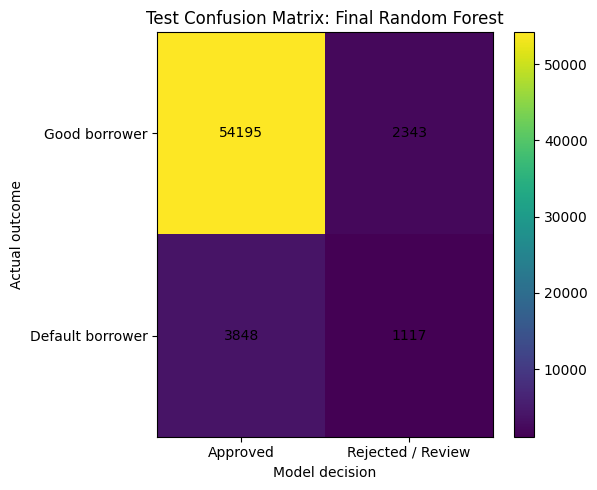

In [ ]:

# Test Confusion Matrix

test_decision_reject = (test_proba >= main_threshold).astype(int)

test_cm = confusion_matrix(
    y_test_arr,
    test_decision_reject,
    labels=[0, 1]
)

test_cm_df = pd.DataFrame(
    test_cm,
    index=["Actual good borrower (TARGET=0)", "Actual default borrower (TARGET=1)"],
    columns=["Approved", "Rejected / Review"]
)

display(test_cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(test_cm, aspect="auto")
plt.xticks([0, 1], ["Approved", "Rejected / Review"])
plt.yticks([0, 1], ["Good borrower", "Default borrower"])
plt.xlabel("Model decision")
plt.ylabel("Actual outcome")
plt.title("Test Confusion Matrix: Final Random Forest")

for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        plt.text(j, i, test_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("rf_test_confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

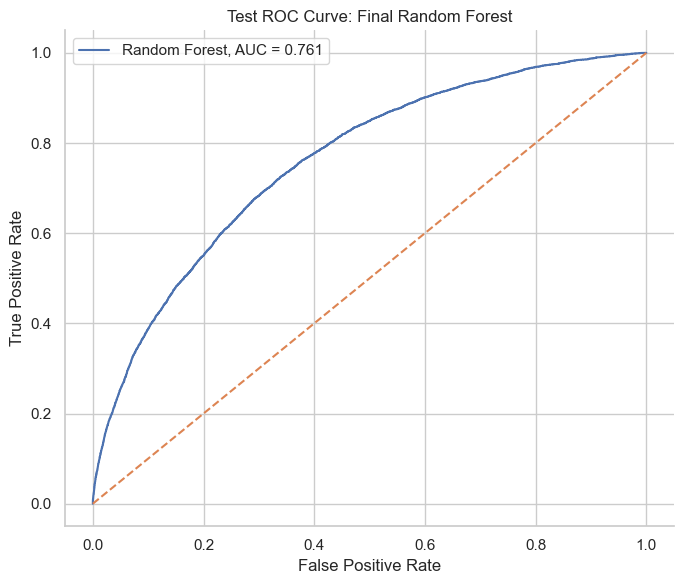

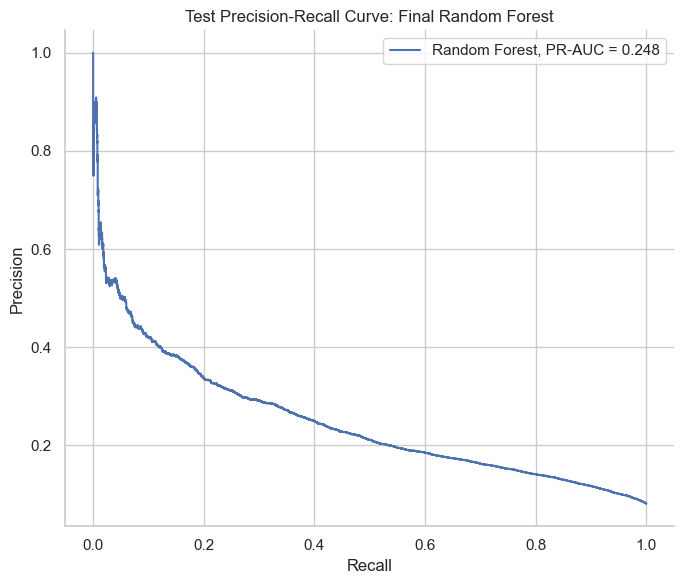

In [ ]:

#  Test ROC Curve and Precision-Recall Curve

fpr, tpr, _ = roc_curve(y_test_arr, test_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest, AUC = {test_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve: Final Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("rf_test_roc_curve_final.png", dpi=150, bbox_inches="tight")
plt.show()


precision, recall, _ = precision_recall_curve(y_test_arr, test_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Random Forest, PR-AUC = {test_pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve: Final Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("rf_test_precision_recall_curve_final.png", dpi=150, bbox_inches="tight")
plt.show()

# ## 9. XGBoost — Payoff-Based Selection, Optuna Tuning, GPU
#
# Pipeline:
# 1. **9.1 Baseline** — default XGBoost, val payoff as reference
# 2. **9.2 Optuna** — 50-trial Bayesian search, objective = val total_payoff (Balanced)
# 3. **9.3 Champion** — retrain best params; compare train vs val payoff
# 4. **9.4 Refit** — if train >> val (overfitting), refit on Train+Val combined
# 5. **9.5 Test** — report once; robustness across 3 payoff scenarios
# 6. **9.6 Feature importance** — top-20 by gain
# 7. **9.7 Tuning diagnostics** — optimisation history + parameter changes
# 8. **9.8 Summary table** — Default vs Tuned vs Final

# XG Boost

In [ ]:


import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import optuna, xgboost as xgb
from optuna.logging import set_verbosity, WARNING as OPT_WARN

warnings.filterwarnings("ignore")
set_verbosity(OPT_WARN)
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Convert DataFrames from Section 8 to numpy arrays for XGBoost
feat_names   = list(X_train_full.columns)
X_train_full_temp = X_train_full
X_valid_full_temp = X_valid_full
X_test_full_temp = X_test_full
X_train_full = X_train_full.values.astype(np.float32)
X_valid_full = X_valid_full.values.astype(np.float32)
X_test_full  = X_test_full.values.astype(np.float32)
y_train_arr  = train_dummy["TARGET"].astype(int).values
y_valid_arr  = validation_dummy["TARGET"].astype(int).values
y_test_arr   = test_dummy["TARGET"].astype(int).values

pos_rate     = y_train_arr.mean()
balanced_spw = (1 - pos_rate) / pos_rate
balanced_row = payoff_scenarios[payoff_scenarios["scenario"] == "Balanced"].iloc[0]

print(f"Features: {X_train_full.shape[1]}  |  default rate: {pos_rate:.4f}  |  balanced_spw: {balanced_spw:.1f}")
print(f"Balanced threshold: {balanced_row['threshold']:.4f}")


# ### 9.1 XGBoost Baseline (Default Hyperparameters)

Features: 268  |  default rate: 0.0807  |  balanced_spw: 11.4
Balanced threshold: 0.2162


In [ ]:


xgb_baseline = xgb.XGBClassifier(
    scale_pos_weight=balanced_spw,
    eval_metric="auc",
    early_stopping_rounds=50,
    device=XGB_DEVICE,
    n_estimators=1000,
    random_state=SEED,
)
xgb_baseline.fit(X_train_full, y_train_arr,
                 eval_set=[(X_valid_full, y_valid_arr)], verbose=False)

baseline_val_proba   = xgb_baseline.predict_proba(X_valid_full)[:, 1]
baseline_train_proba = xgb_baseline.predict_proba(X_train_full)[:, 1]
balanced_row = payoff_scenarios[payoff_scenarios["scenario"] == "Balanced"].iloc[0]

baseline_val_res   = evaluate_payoff(y_valid_arr,  baseline_val_proba,   balanced_row)
baseline_train_res = evaluate_payoff(y_train_arr,  baseline_train_proba, balanced_row)
baseline_val_payoff   = baseline_val_res["total_payoff"]
baseline_train_payoff = baseline_train_res["total_payoff"]
baseline_val_auc      = baseline_val_res["ROC_AUC"]

print(f"Baseline  |  Train: ${baseline_train_payoff:,.0f}  |  Val: ${baseline_val_payoff:,.0f}  |  AUC: {baseline_val_auc:.4f}")


# ### 9.2 Optuna Hyperparameter Search — TPE (Bayesian Optimisation)
#
# #### How TPE works vs gradient descent
#
# | | Gradient Descent | TPE (Tree-structured Parzen Estimator) |
# |---|---|---|
# | **What it optimises** | Model weights (millions of numbers) | Hyperparameters (≈10 numbers) |
# | **How it moves** | Computes gradient → step downhill | Builds a probability model of "good" vs "bad" configs |
# | **Requires derivative?** | Yes | No — treats the objective as a black box |
# | **Each iteration costs** | Cheap (one weight update) | Expensive (one full model train) |
#
# **TPE in plain terms:** After each trial, Optuna fits two density models —
# `l(x)` for configs that gave **high** payoff and `g(x)` for **low** payoff.
# The next config to try is drawn from regions where `l(x)/g(x)` is large
# (likely good, rarely tried). This is "Bayesian" because it uses past results
# to guide future sampling, rather than searching blindly.
#
# **Why not grid search?** With 9 hyperparameters and 5 levels each, a full grid
# would need 5⁹ = ~2 million trials. TPE finds a good region in 50 trials.
#
# Objective: **maximise validation total_payoff** (Balanced scenario, threshold ≈ 0.2162).

Baseline  |  Train: $13,917,852,000  |  Val: $4,533,204,000  |  AUC: 0.7701


In [ ]:


def objective(trial):
    params = dict(
        max_depth          = trial.suggest_int("max_depth", 3, 7),
        learning_rate      = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample          = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree   = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight   = trial.suggest_int("min_child_weight", 1, 50),
        reg_alpha          = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda         = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        gamma              = trial.suggest_float("gamma", 0.0, 3.0),
        scale_pos_weight   = trial.suggest_float("scale_pos_weight", 1.0, max(16.0, balanced_spw * 2)),
        n_estimators       = trial.suggest_int("n_estimators", 200, 1200, step=100),
    )
    model = xgb.XGBClassifier(**params, eval_metric="auc", early_stopping_rounds=50,
                               device=XGB_DEVICE, random_state=SEED)
    model.fit(X_train_full, y_train_arr, eval_set=[(X_valid_full, y_valid_arr)], verbose=False)
    proba = model.predict_proba(X_valid_full)[:, 1]
    return evaluate_payoff(y_valid_arr, proba, balanced_row)["total_payoff"]
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", study_name="xgb_payoff", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest val payoff: ${study.best_value:,.0f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v:.4g}")


# ### 9.3 Champion Model — Train vs Val Payoff

  0%|          | 0/50 [00:00<?, ?it/s]


Best val payoff: $6,879,612,000
Best hyperparameters:
  max_depth             : 3
  learning_rate         : 0.1695
  subsample             : 0.8341
  colsample_bytree      : 0.8153
  min_child_weight      : 43
  reg_alpha             : 0.02502
  reg_lambda            : 8.26e-07
  gamma                 : 1.361
  scale_pos_weight      : 1.117
  n_estimators          : 200


In [ ]:


champion_model = xgb.XGBClassifier(
    **study.best_params, eval_metric="auc", early_stopping_rounds=50,
    device=XGB_DEVICE, random_state=SEED,
)
champion_model.fit(X_train_full, y_train_arr,
                   eval_set=[(X_valid_full, y_valid_arr)], verbose=False)

champion_train_proba = champion_model.predict_proba(X_train_full)[:, 1]
champion_val_proba   = champion_model.predict_proba(X_valid_full)[:, 1]

_tr = evaluate_payoff(y_train_arr, champion_train_proba, balanced_row)
_va = evaluate_payoff(y_valid_arr, champion_val_proba,   balanced_row)

champion_train_payoff = _tr["total_payoff"]
champion_val_payoff   = _va["total_payoff"]
champion_val_auc      = _va["ROC_AUC"]

print(f"Champion  |  Train: ${champion_train_payoff:,.0f}  |  Val: ${champion_val_payoff:,.0f}  |  AUC: {champion_val_auc:.4f}")


# ### 9.4 Overfitting Check & Refit Decision
#
# Refit criterion uses **train vs val gap only** — test set is not touched here.
# This avoids data leakage: any decision informed by test performance would
# invalidate the test set as an unbiased evaluation.

Champion  |  Train: $20,852,748,000  |  Val: $6,879,612,000  |  AUC: 0.7813


In [ ]:
# NOTE: This original diagnostic compares total payoff across unequal split sizes.
# It is not a valid overfitting test; see REPRODUCIBILITY.md.


gap      = (champion_train_payoff - champion_val_payoff) / abs(champion_train_payoff) \
           if abs(champion_train_payoff) > 1e-6 else 0.0
abs_diff = abs(champion_train_payoff - champion_val_payoff)

print(f"Train Payoff : ${champion_train_payoff:,.0f}")
print(f"Val Payoff   : ${champion_val_payoff:,.0f}")
print(f"Relative gap : {gap:.2%}   Absolute diff: ${abs_diff:,.0f}")
print(f"Refit trigger: gap > 20% AND abs_diff > $500,000")

needs_refit = (gap > 0.20) and (abs_diff > 500_000)
refitted    = False

if needs_refit:
    print("\n→ Overfitting detected — refitting on Train+Val combined.")
    X_tv = np.concatenate([X_train_full, X_valid_full], axis=0)
    y_tv = np.concatenate([y_train_arr,  y_valid_arr],  axis=0)
    refit_params = {**study.best_params,
                    "n_estimators": champion_model.best_iteration + 1}
    final_model = xgb.XGBClassifier(**refit_params, device=XGB_DEVICE, random_state=SEED)
    final_model.fit(X_tv, y_tv, verbose=False)
    refitted = True
else:
    print("\n→ Gap acceptable — champion is the final model.")
    final_model = champion_model

print(f"\nRefitted on Train+Val: {refitted}")


# ### 9.5 Test Set Results — Reported Once
#
# The test set is evaluated **exactly once** after all modelling decisions are made.
# The same model is scored under all three payoff scenarios to assess robustness.

Train Payoff : $20,852,748,000
Val Payoff   : $6,879,612,000
Relative gap : 67.01%   Absolute diff: $13,973,136,000
Refit trigger: gap > 20% AND abs_diff > $500,000

→ Overfitting detected — refitting on Train+Val combined.

Refitted on Train+Val: True


In [ ]:


final_test_proba = final_model.predict_proba(X_test_full)[:, 1]

rows = []
for _, s in payoff_scenarios.iterrows():
    r = evaluate_payoff(y_test_arr, final_test_proba, s)
    rows.append({
        "Scenario":      s["scenario"],
        "Threshold":     s["threshold"],
        "Test Payoff":   r["total_payoff"],
        "Avg Payoff /applicant": r["average_payoff_per_applicant"],
        "ROC-AUC":       r["ROC_AUC"],
        "Approval Rate": r["approval_rate"],
    })

robust_df = pd.DataFrame(rows).set_index("Scenario")
display(robust_df.style.format({
    "Threshold":  "{:.4f}",
    "Test Payoff": "${:,.0f}",
    "Avg Payoff /applicant": "${:,.0f}",
    "ROC-AUC": "{:.4f}",
    "Approval Rate": "{:.1%}",
}))

_bal = evaluate_payoff(y_test_arr, final_test_proba, balanced_row)
final_test_payoff = _bal["total_payoff"]
final_test_auc    = _bal["ROC_AUC"]
print(f"\nFinal (Balanced)  |  Test Payoff: ${final_test_payoff:,.0f}  |  AUC: {final_test_auc:.4f}")


# ### 9.5b Standard ML Evaluation — ROC, Precision-Recall, Confusion Matrix
#
# Payoff is the primary criterion but we also report standard classification metrics
# so the model can be assessed independently of business assumptions.
#
# **ROC-AUC** measures ranking quality (how well the model separates defaulters from
# non-defaulters) — threshold-independent.
# **PR-AUC** is more informative than ROC-AUC under class imbalance (8% default rate).
# **Confusion matrix** shows where errors land under each business threshold.

,Threshold,Test Payoff,Avg Payoff /applicant,ROC-AUC,Approval Rate
Scenario,,,,,
Conservative,0.1136,"$4,731,936,000","$76,938",0.7797,75.4%
Balanced,0.2162,"$6,862,836,000","$111,585",0.7797,90.6%
Growth_oriented,0.3667,"$9,321,096,000","$151,555",0.7797,97.5%



Final (Balanced)  |  Test Payoff: $6,862,836,000  |  AUC: 0.7797


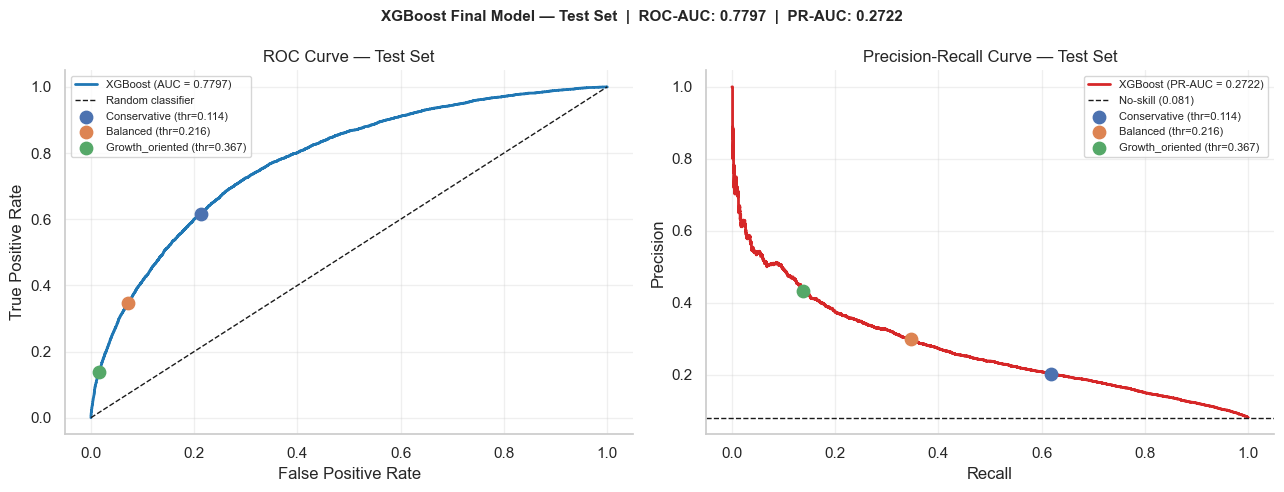

In [ ]:


from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── ROC + PR curves ──────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_arr, final_test_proba)
prec, rec, _ = precision_recall_curve(y_test_arr, final_test_proba)
roc_auc_val  = auc(fpr, tpr)
pr_auc_val   = auc(rec, prec)
no_skill     = y_test_arr.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"XGBoost (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
for s in payoff_scenarios.itertuples():
    r  = evaluate_payoff(y_test_arr, final_test_proba, s._asdict())
    tn, fp, fn, tp = (r["TN_good_approved"], r["FP_good_rejected"],
                      r["FN_default_approved"], r["TP_default_rejected"])
    tpr_s = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_s = fp / (fp + tn) if (fp + tn) > 0 else 0
    ax.scatter(fpr_s, tpr_s, s=80, zorder=5, label=f"{s.scenario} (thr={s.threshold:.3f})")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec, prec, color="#d62728", lw=2, label=f"XGBoost (PR-AUC = {pr_auc_val:.4f})")
ax.axhline(no_skill, color="k", linestyle="--", lw=1, label=f"No-skill ({no_skill:.3f})")
for s in payoff_scenarios.itertuples():
    r  = evaluate_payoff(y_test_arr, final_test_proba, s._asdict())
    tn, fp, fn, tp = (r["TN_good_approved"], r["FP_good_rejected"],
                      r["FN_default_approved"], r["TP_default_rejected"])
    prec_s = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec_s  = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.scatter(rec_s, prec_s, s=80, zorder=5, label=f"{s.scenario} (thr={s.threshold:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"XGBoost Final Model — Test Set  |  ROC-AUC: {roc_auc_val:.4f}  |  PR-AUC: {pr_auc_val:.4f}",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("xgb_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

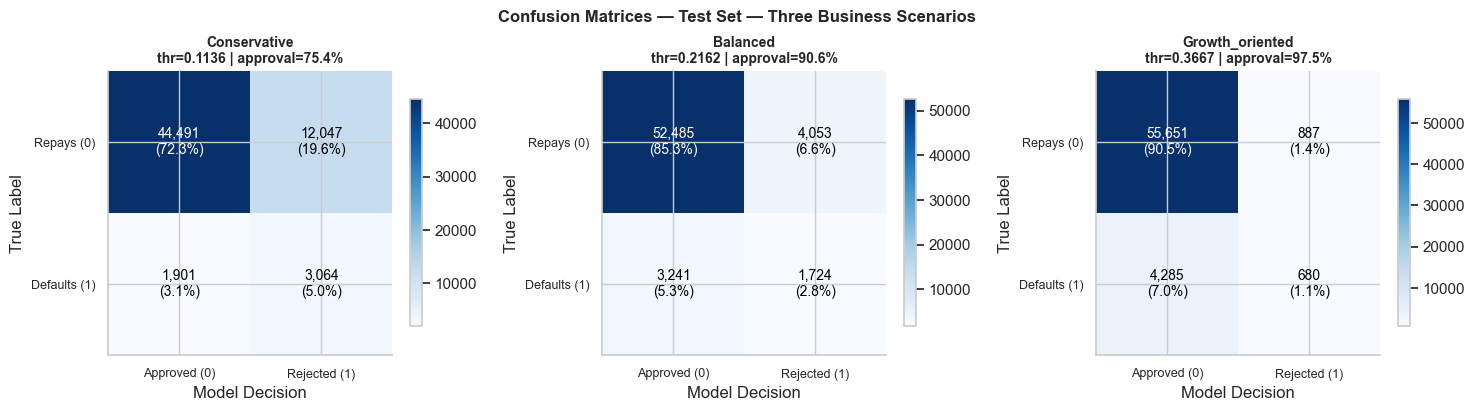

In [ ]:


# ── Confusion matrices for all 3 scenarios ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scen_list = list(payoff_scenarios.itertuples())

for ax, s in zip(axes, scen_list):
    thr  = s.threshold
    pred = (final_test_proba >= thr).astype(int)
    cm   = confusion_matrix(y_test_arr, pred)
    tn, fp, fn, tp = cm.ravel()
    total = cm.sum()

    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}\n({cm[i,j]/total:.1%})",
                    ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()*0.5 else "black",
                    fontsize=10)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Approved (0)", "Rejected (1)"], fontsize=9)
    ax.set_yticklabels(["Repays (0)", "Defaults (1)"], fontsize=9)
    ax.set_xlabel("Model Decision"); ax.set_ylabel("True Label")
    approval_rate = (pred == 0).mean()
    ax.set_title(f"{s.scenario}\nthr={thr:.4f} | approval={approval_rate:.1%}",
                 fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Confusion Matrices — Test Set — Three Business Scenarios",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("xgb_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:


# ── Classification report for Balanced scenario ──────────────────────────────
bal_thr  = float(balanced_row["threshold"])
bal_pred = (final_test_proba >= bal_thr).astype(int)

print(f"Classification Report — Balanced Scenario (threshold = {bal_thr:.4f})")
print("=" * 60)
print(classification_report(
    y_test_arr, bal_pred,
    target_names=["Repays (0)", "Defaults (1)"],
    digits=4,
))

# Summary metrics table
metrics = {}
for s in payoff_scenarios.itertuples():
    pred = (final_test_proba >= s.threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_arr, pred).ravel()
    metrics[s.scenario] = {
        "Threshold"  : s.threshold,
        "Precision"  : tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall"     : tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1"         : 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0,
        "Approval %" : (pred == 0).mean(),
    }

metrics_df = pd.DataFrame(metrics).T
display(metrics_df.style.format({
    "Threshold"  : "{:.4f}",
    "Precision"  : "{:.4f}",
    "Recall"     : "{:.4f}",
    "Specificity": "{:.4f}",
    "F1"         : "{:.4f}",
    "Approval %" : "{:.1%}",
}).highlight_max(axis=0, subset=["Precision","Recall","F1","Specificity"], color="lightgreen")
  .set_caption("Standard Classification Metrics — Test Set — All Scenarios"))

print(f"\nROC-AUC  : {roc_auc_val:.4f}")
print(f"PR-AUC   : {pr_auc_val:.4f}")


# ### 9.6 Feature Importance — Top 20 (Gain)

Classification Report — Balanced Scenario (threshold = 0.2162)
              precision    recall  f1-score   support

  Repays (0)     0.9418    0.9283    0.9350     56538
Defaults (1)     0.2984    0.3472    0.3210      4965

    accuracy                         0.8814     61503
   macro avg     0.6201    0.6378    0.6280     61503
weighted avg     0.8899    0.8814    0.8855     61503



,Threshold,Precision,Recall,Specificity,F1,Approval %
Conservative,0.1136,0.2028,0.6171,0.7869,0.3052,75.4%
Balanced,0.2162,0.2984,0.3472,0.9283,0.3210,90.6%
Growth_oriented,0.3667,0.4340,0.1370,0.9843,0.2082,97.5%



ROC-AUC  : 0.7797
PR-AUC   : 0.2722


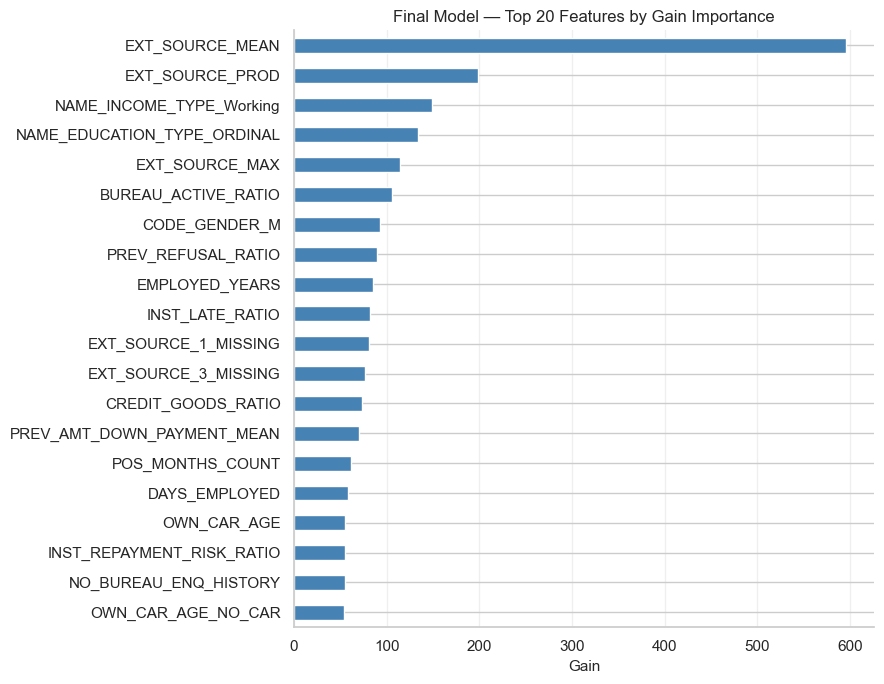

In [ ]:


fid_to_name = {f"f{i}": name for i, name in enumerate(feat_names)}
imp_scores  = final_model.get_booster().get_score(importance_type="gain")
imp_series  = (
    pd.Series(imp_scores)
    .rename(index=lambda f: fid_to_name.get(f, f))
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
imp_series[::-1].plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Gain", fontsize=11)
ax.set_title("Final Model — Top 20 Features by Gain Importance", fontsize=12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150)
plt.show()


# ### 9.7 Tuning Diagnostics
#
# **Left panel:** How payoff improved across 50 Optuna trials. Each dot is one trial;
# the line tracks the running best. Shows Bayesian optimisation converging above the default baseline.
#
# **Right panel:** Key hyperparameter values — default (orange) vs tuned (blue).
# Notable changes show how the tuner adapted the model for this credit-scoring task.

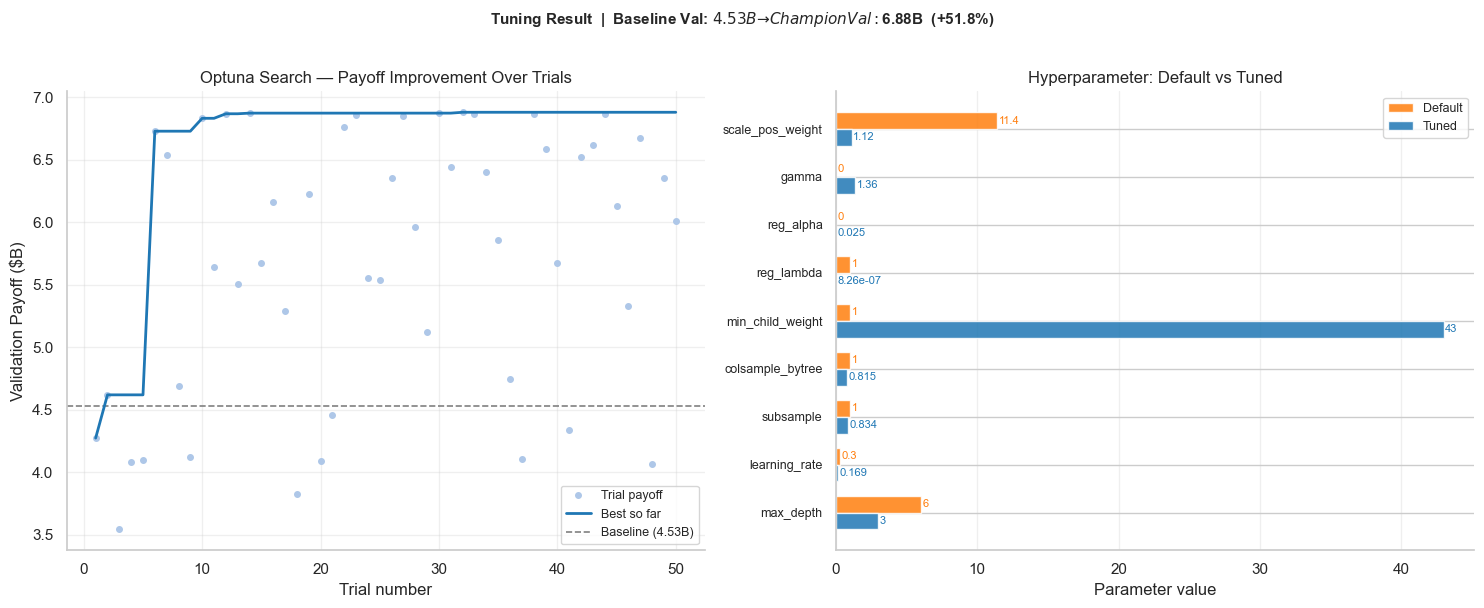

In [ ]:


XGB_DEFAULTS = {
    "max_depth": 6, "learning_rate": 0.3, "subsample": 1.0,
    "colsample_bytree": 1.0, "min_child_weight": 1,
    "reg_lambda": 1.0, "reg_alpha": 0.0, "gamma": 0.0,
    "scale_pos_weight": balanced_spw,
}
PARAM_LABELS = {
    "max_depth": "max_depth", "learning_rate": "learning_rate",
    "subsample": "subsample", "colsample_bytree": "colsample_bytree",
    "min_child_weight": "min_child_weight", "reg_lambda": "reg_lambda",
    "reg_alpha": "reg_alpha", "gamma": "gamma",
    "scale_pos_weight": "scale_pos_weight",
}

trial_vals   = [t.value for t in study.trials if t.value is not None]
best_so_far  = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]
params_show  = [k for k in XGB_DEFAULTS if k in study.best_params]
default_vals = [XGB_DEFAULTS[k] for k in params_show]
tuned_vals   = [study.best_params[k] for k in params_show]
labels       = [PARAM_LABELS.get(k, k) for k in params_show]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1 — Optuna optimisation history
ax = axes[0]
ax.plot(range(1, len(trial_vals)+1), [v/1e9 for v in trial_vals],
        "o", color="#aec7e8", markersize=4, label="Trial payoff", zorder=2)
ax.plot(range(1, len(best_so_far)+1), [v/1e9 for v in best_so_far],
        "-", color="#1f77b4", linewidth=2, label="Best so far", zorder=3)
ax.axhline(baseline_val_payoff/1e9, color="gray", linestyle="--",
           linewidth=1.2, label=f"Baseline ({baseline_val_payoff/1e9:.2f}B)")
ax.set_xlabel("Trial number"); ax.set_ylabel("Validation Payoff ($B)")
ax.set_title("Optuna Search — Payoff Improvement Over Trials")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 2 — Default vs Tuned
ax = axes[1]
x, w = np.arange(len(labels)), 0.35
bars1 = ax.barh(x + w/2, default_vals, w, label="Default", color="#ff7f0e", alpha=0.85)
bars2 = ax.barh(x - w/2, tuned_vals,   w, label="Tuned",   color="#1f77b4", alpha=0.85)
ref = max(default_vals) * 0.01
for b, v in zip(bars1, default_vals):
    ax.text(b.get_width() + ref, b.get_y() + b.get_height()/2, f"{v:.3g}", va="center", fontsize=8, color="#ff7f0e")
for b, v in zip(bars2, tuned_vals):
    ax.text(b.get_width() + ref, b.get_y() + b.get_height()/2, f"{v:.3g}", va="center", fontsize=8, color="#1f77b4")
ax.set_yticks(x); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Parameter value")
ax.set_title("Hyperparameter: Default vs Tuned")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)

improvement = (champion_val_payoff / baseline_val_payoff - 1) * 100
plt.suptitle(
    f"Tuning Result  |  Baseline Val: ${baseline_val_payoff/1e9:.2f}B  →  "
    f"Champion Val: ${champion_val_payoff/1e9:.2f}B  (+{improvement:.1f}%)",
    fontsize=11, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("xgb_tuning_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


# ### 9.7b How Did TPE Find the Optimal? — Parameter × Payoff Relationships
#
# Each scatter plot shows one hyperparameter (x-axis) vs the validation payoff it produced
# (y-axis) across all 50 Optuna trials. Colour = payoff percentile rank (green = high payoff,
# red = low). The dashed navy line marks the value chosen for the best model.
#
# Reading these plots tells you *which parameters mattered* (tight green cluster → strong
# preference) and *which barely mattered* (green and red scattered evenly → insensitive).

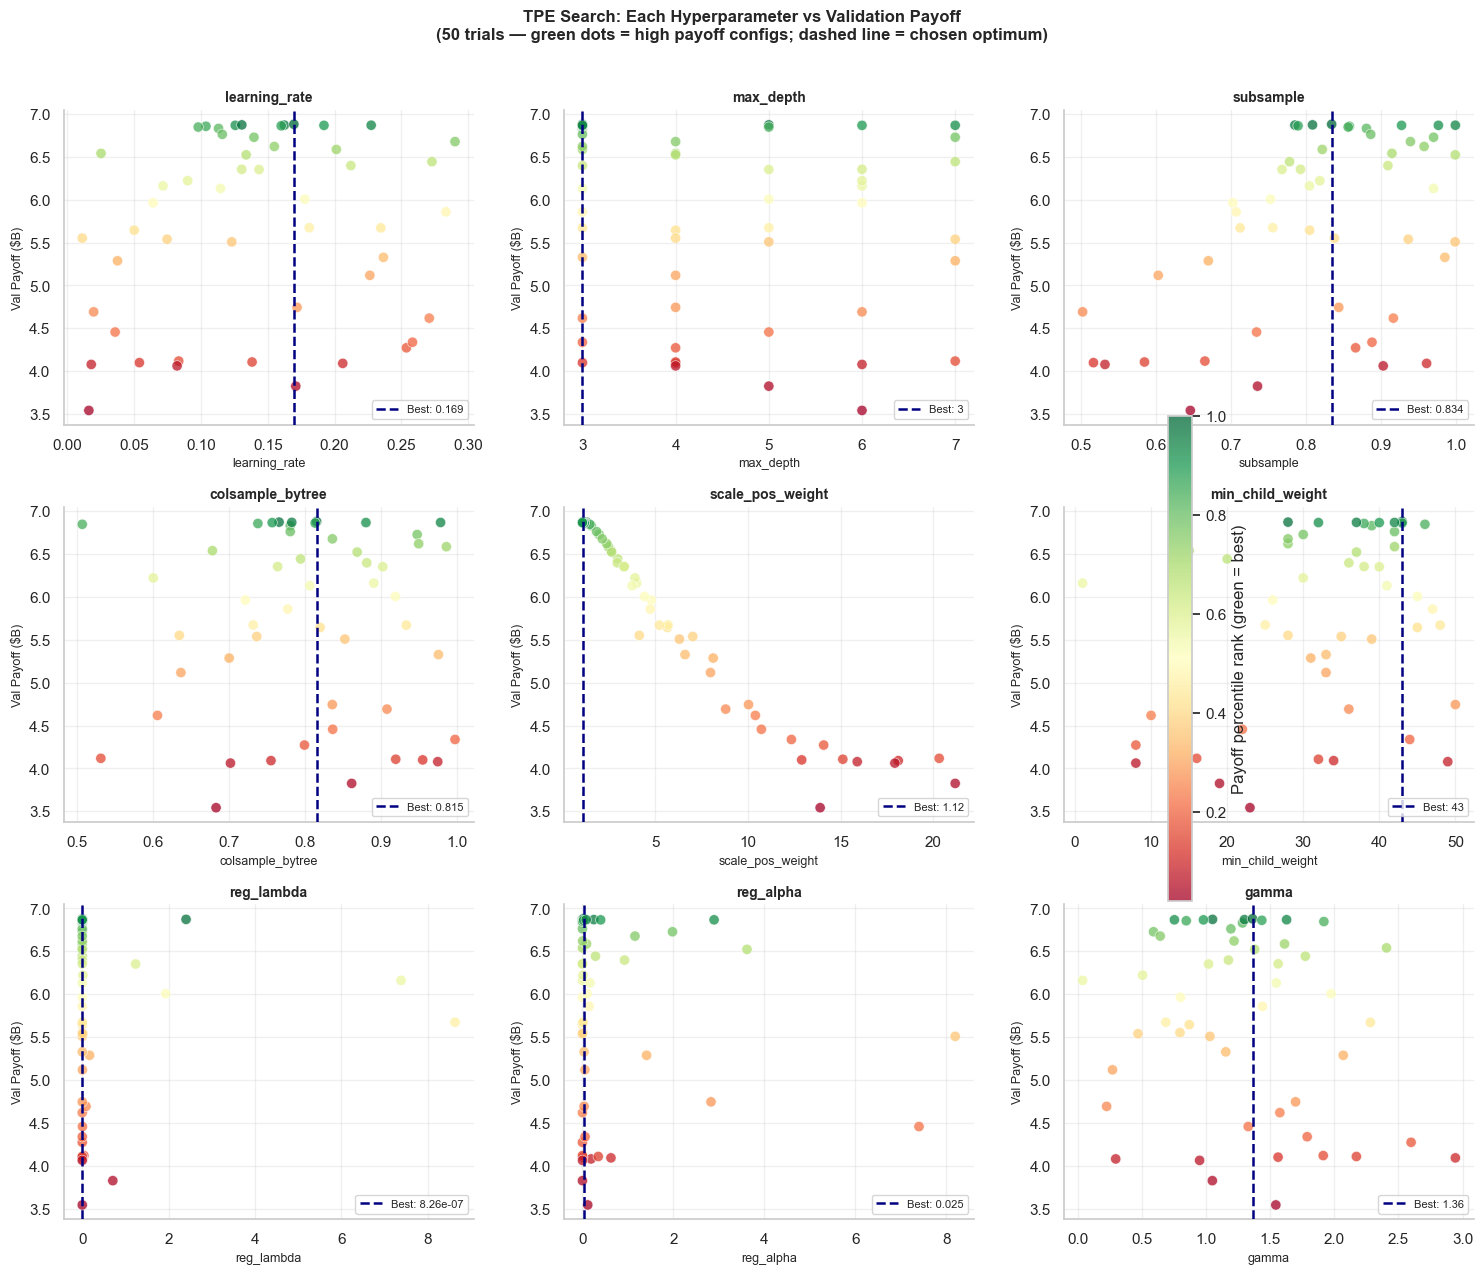

In [ ]:


# Collect all trial data into a DataFrame
trial_data = []
for t in study.trials:
    if t.value is not None:
        row = {"payoff": t.value}
        row.update(t.params)
        trial_data.append(row)
trials_df = pd.DataFrame(trial_data)

key_params = ["learning_rate", "max_depth", "subsample", "colsample_bytree",
              "scale_pos_weight", "min_child_weight", "reg_lambda", "reg_alpha", "gamma"]
key_params = [p for p in key_params if p in trials_df.columns]

ncols = 3
nrows = (len(key_params) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4.2))
axes = axes.flatten()

ranks = trials_df["payoff"].rank(pct=True)
for i, param in enumerate(key_params):
    ax = axes[i]
    sc = ax.scatter(trials_df[param], trials_df["payoff"] / 1e9,
                    c=ranks, cmap="RdYlGn", alpha=0.75, s=55,
                    edgecolors="white", linewidth=0.5, zorder=3)
    best_val = study.best_params.get(param)
    if best_val is not None:
        ax.axvline(best_val, color="navy", linestyle="--", linewidth=1.8,
                   label=f"Best: {best_val:.3g}", zorder=4)
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel(param, fontsize=9)
    ax.set_ylabel("Val Payoff ($B)", fontsize=9)
    ax.set_title(param, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.colorbar(sc, ax=axes[:len(key_params)], label="Payoff percentile rank (green = best)",
             shrink=0.5, pad=0.02)
plt.suptitle(
    "TPE Search: Each Hyperparameter vs Validation Payoff\n"
    "(50 trials — green dots = high payoff configs; dashed line = chosen optimum)",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("xgb_param_payoff_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


# ### 9.7c Payoff Distribution — How Much Did Tuning Help?
#
# Compares the distribution of payoffs from *all* 50 trials (exploring the search space)
# against the default baseline. Shows how many trials beat the default, and by how much.

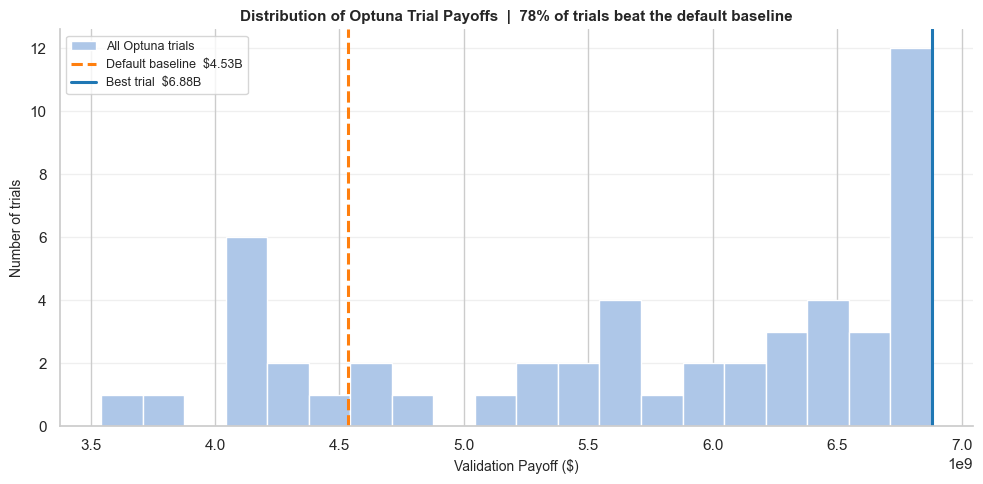

Trials above default baseline: 39 / 50
Improvement over baseline    : +$2346.4M  (51.8%)


In [ ]:


trial_payoffs = [t.value for t in study.trials if t.value is not None]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(trial_payoffs, bins=20, color="#aec7e8", edgecolor="white",
        label="All Optuna trials", zorder=2)
ax.axvline(baseline_val_payoff, color="#ff7f0e", linewidth=2.2, linestyle="--",
           label=f"Default baseline  ${baseline_val_payoff/1e9:.2f}B")
ax.axvline(study.best_value, color="#1f77b4", linewidth=2.2, linestyle="-",
           label=f"Best trial  ${study.best_value/1e9:.2f}B")
pct_better = np.mean(np.array(trial_payoffs) > baseline_val_payoff) * 100
ax.set_xlabel("Validation Payoff ($)", fontsize=10)
ax.set_ylabel("Number of trials", fontsize=10)
ax.set_title(
    f"Distribution of Optuna Trial Payoffs  |  "
    f"{pct_better:.0f}% of trials beat the default baseline",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_trial_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Trials above default baseline: {sum(v > baseline_val_payoff for v in trial_payoffs)} / {len(trial_payoffs)}")
print(f"Improvement over baseline    : +${(study.best_value - baseline_val_payoff)/1e6:.1f}M  "
      f"({(study.best_value/baseline_val_payoff - 1)*100:.1f}%)")


# ### 9.8 Summary — Default vs Tuned vs Final

In [ ]:
# NOTE: After a train+validation refit, the validation score below is in-sample.
# See REPRODUCIBILITY.md; do not treat it as held-out performance.


if refitted:
    fv = evaluate_payoff(y_valid_arr, final_model.predict_proba(X_valid_full)[:, 1], balanced_row)
    final_val_payoff, final_val_auc = fv["total_payoff"], fv["ROC_AUC"]
else:
    final_val_payoff, final_val_auc = champion_val_payoff, champion_val_auc

summary_df = pd.DataFrame({
    "Model": ["Default Baseline", "Tuned Champion",
              f"Final Model ({'refitted on Train+Val' if refitted else 'champion'})"],
    "Train Payoff": [baseline_train_payoff, champion_train_payoff, np.nan],
    "Val Payoff":   [baseline_val_payoff,   champion_val_payoff,   final_val_payoff],
    "Test Payoff":  [np.nan,                np.nan,                final_test_payoff],
    "Val AUC":      [baseline_val_auc,      champion_val_auc,      final_val_auc],
    "Test AUC":     [np.nan,                np.nan,                final_test_auc],
}).set_index("Model")

display(
    summary_df.style
    .format({
        "Train Payoff": lambda v: f"${v:,.0f}" if pd.notna(v) else "—",
        "Val Payoff":   lambda v: f"${v:,.0f}" if pd.notna(v) else "—",
        "Test Payoff":  lambda v: f"${v:,.0f}" if pd.notna(v) else "—",
        "Val AUC":      lambda v: f"{v:.4f}"   if pd.notna(v) else "—",
        "Test AUC":     lambda v: f"{v:.4f}"   if pd.notna(v) else "—",
    })
    .highlight_max(axis=0, subset=["Val Payoff", "Val AUC"], color="lightgreen")
    .highlight_max(axis=0, subset=["Test Payoff", "Test AUC"], color="lightblue")
    .set_caption("XGBoost Model Comparison — Balanced Scenario")
)

robust_df.to_csv("xgb_robustness_results.csv")
summary_df.to_csv("xgb_summary.csv")
print("Saved: xgb_robustness_results.csv  xgb_summary.csv")



# ---
#
# ## 9. LightGBM / Gradient Boosting Modelling
#
# This section trains LightGBM classifiers on two feature representations (Full and Top50) defined in before.
#
# **Evaluation protocol:**
# 1. Train all LightGBM candidates on the **training set**.
# 2. Predict default probability on the **validation set**.
# 3. Apply the payoff-based threshold (0.216216, Balanced scenario) to compute expected business payoff.
# 4. Select the candidate with the highest validation **average payoff per applicant**.
# 5. Fix the best model, representation, and threshold.
# 6. Evaluate **once** on the held-out **test set**.
#
# Conservative (0.113636) and Growth-oriented (0.366667) thresholds are reserved for robustness analysis after the best model is fixed — they do not participate in model selection.

,Train Payoff,Val Payoff,Test Payoff,Val AUC,Test AUC
Model,,,,,
Default Baseline,"$13,917,852,000","$4,533,204,000",—,0.7701,—
Tuned Champion,"$20,852,748,000","$6,879,612,000",—,0.7813,—
Final Model (refitted on Train+Val),—,"$6,936,144,000","$6,862,836,000",0.8004,0.7797


Saved: xgb_robustness_results.csv  xgb_summary.csv


# Light GBM

In [ ]:
X_train_full = X_train_full_temp
X_valid_full = X_valid_full_temp
X_test_full = X_test_full_temp

# Imports for LightGBM modelling

import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


# ### 9.1 Payoff Rows and Threshold
#
# Retrieve the payoff scenario rows built before. These define the decision thresholds and payoff values for each business scenario.
#
# **Code: Retrieve and confirm thresholds**

In [ ]:


# Defensive check
if 'payoff_threshold_main' not in globals():
    raise NameError("payoff_threshold_main not found — run Section 8 (payoff matrix) first.")
if 'payoff_scenarios' not in globals():
    raise NameError("payoff_scenarios not found — run Section 8 (robustness scenarios) first.")

# Main payoff row (Balanced scenario, threshold = 0.216216)
main_payoff_row = payoff_threshold_main.iloc[0]
MAIN_THRESHOLD  = float(main_payoff_row["threshold"])

# Robustness scenario rows — keyed by scenario name for easy lookup
robustness_rows_map = {
    row["scenario"]: row
    for _, row in payoff_scenarios.iterrows()
}

print("Payoff thresholds confirmed:")
print(f"  Main (Balanced)          : {MAIN_THRESHOLD:.6f}")
for name, row in robustness_rows_map.items():
    print(f"  {name:<25s}: {float(row['threshold']):.6f}")


# ### 9.2 Class Imbalance
#
# The dataset has a significant class imbalance: defaults (TARGET=1) are rare. Because default cases are rare, we tested both weighted and unweighted LightGBM models. Weighted models use scale_pos_weight to emphasise defaults, while unweighted models preserve probability outputs closer to the observed default rate. Final selection is based on validation payoff rather than class-balance assumptions.
#
# **Code: Compute scale_pos_weight**

Payoff thresholds confirmed:
  Main (Balanced)          : 0.216216
  Conservative             : 0.113636
  Balanced                 : 0.216216
  Growth_oriented          : 0.366667


In [ ]:


# Compute class-imbalance correction factor
n_neg = int((y_train_arr == 0).sum())
n_pos = int((y_train_arr == 1).sum())
scale_pos_weight = n_neg / n_pos

print("Training set class counts:")
print(f"  Non-defaults (TARGET=0): {n_neg:>8,}")
print(f"  Defaults     (TARGET=1): {n_pos:>8,}")
print(f"  Imbalance ratio        : {scale_pos_weight:.2f}:1")
print(f"  scale_pos_weight       : {scale_pos_weight:.4f}")


# ### 9.3 Candidate Configurations
#
# Six configurations systematically explore the hyperparameter space. Each configuration varies a distinct axis: tree complexity, learning dynamics, regularisation, and subsampling.
#
# **Code: Define candidate configuration grid**

Training set class counts:
  Non-defaults (TARGET=0):  169,611
  Defaults     (TARGET=1):   14,895
  Imbalance ratio        : 11.39:1
  scale_pos_weight       : 11.3871


In [ ]:


# Candidate LightGBM configurations

# Six configurations spanning:
#   - Tree complexity   : num_leaves, max_depth
#   - Learning dynamics : learning_rate, n_estimators
#   - Regularisation    : reg_alpha (L1), reg_lambda (L2)
#   - Subsampling       : subsample, colsample_bytree
#   - Leaf size         : min_child_samples

CANDIDATE_CONFIGS = [
    {
        "config_name": "lgbm_01_baseline",
        "note": "Default-like starting point; no subsampling or regularisation",
        "params": dict(
            n_estimators=500,   learning_rate=0.05, num_leaves=31,
            max_depth=-1,       min_child_samples=20,
            subsample=1.0,      subsample_freq=0,
            colsample_bytree=1.0,
            reg_alpha=0.0,      reg_lambda=0.0,
        ),
    },
    {
        "config_name": "lgbm_02_more_leaves",
        "note": "Higher model capacity via more leaves (63) and subsampling",
        "params": dict(
            n_estimators=500,   learning_rate=0.05, num_leaves=63,
            max_depth=-1,       min_child_samples=20,
            subsample=0.9,      subsample_freq=5,
            colsample_bytree=0.9,
            reg_alpha=0.0,      reg_lambda=0.0,
        ),
    },
    {
        "config_name": "lgbm_03_regularised",
        "note": "L1 + L2 regularisation to reduce overfitting",
        "params": dict(
            n_estimators=500,   learning_rate=0.05, num_leaves=31,
            max_depth=-1,       min_child_samples=30,
            subsample=0.8,      subsample_freq=5,
            colsample_bytree=0.8,
            reg_alpha=0.1,      reg_lambda=1.0,
        ),
    },
    {
        "config_name": "lgbm_04_slow_learner",
        "note": "Low learning rate (0.01) + more trees: tutorial-recommended approach",
        "params": dict(
            n_estimators=1000,  learning_rate=0.01, num_leaves=31,
            max_depth=-1,       min_child_samples=20,
            subsample=0.9,      subsample_freq=5,
            colsample_bytree=0.9,
            reg_alpha=0.0,      reg_lambda=0.0,
        ),
    },
    {
        "config_name": "lgbm_05_subsampled",
        "note": "Heavier subsampling (0.7/0.7) to reduce variance",
        "params": dict(
            n_estimators=500,   learning_rate=0.05, num_leaves=31,
            max_depth=6,        min_child_samples=20,
            subsample=0.7,      subsample_freq=5,
            colsample_bytree=0.7,
            reg_alpha=0.0,      reg_lambda=1.0,
        ),
    },
    {
        "config_name": "lgbm_06_conservative",
        "note": "Shallow trees (max_depth=4) + large leaves: highest regularisation",
        "params": dict(
            n_estimators=500,   learning_rate=0.05, num_leaves=15,
            max_depth=4,        min_child_samples=50,
            subsample=0.8,      subsample_freq=5,
            colsample_bytree=0.8,
            reg_alpha=0.1,      reg_lambda=0.1,
        ),
    },
]

# ── Weight variants ──────────────────────────────────────────────────────────
# Weighted   : scale_pos_weight = n_neg / n_pos
#              Up-weights defaults during training → higher recall,
#              but may push predicted probabilities systematically higher,
#              increasing rejection rate and potentially reducing payoff.
# Unweighted : scale_pos_weight = 1 (no adjustment)
#              Predicted probabilities stay closer to the empirical default rate,
#              which better matches the payoff threshold derived from the payoff matrix.
WEIGHT_VARIANTS = [
    {"label": "weighted",   "spw": scale_pos_weight},
    {"label": "unweighted", "spw": 1.0},
]

print(f"Candidate configurations : {len(CANDIDATE_CONFIGS)}")
print(f"Weight variants          : {len(WEIGHT_VARIANTS)} (weighted / unweighted)")
print(f"Feature representations  : Full, Top50")
print(f"Total training runs      : {len(CANDIDATE_CONFIGS) * len(WEIGHT_VARIANTS) * 2}")
print()
for cfg in CANDIDATE_CONFIGS:
    print(f"  {cfg['config_name']:<30s}  {cfg['note']}")


# ### 9.4 Training and Validation Evaluation
#
# Each candidate is trained on the training set and evaluated on the validation set using `evaluate_payoff()` at the main threshold (0.216216). The test set is not touched at this stage.
#
# **Code: Training loop — all candidates × Full and Top50**

Candidate configurations : 6
Weight variants          : 2 (weighted / unweighted)
Feature representations  : Full, Top50
Total training runs      : 24

  lgbm_01_baseline                Default-like starting point; no subsampling or regularisation
  lgbm_02_more_leaves             Higher model capacity via more leaves (63) and subsampling
  lgbm_03_regularised             L1 + L2 regularisation to reduce overfitting
  lgbm_04_slow_learner            Low learning rate (0.01) + more trees: tutorial-recommended approach
  lgbm_05_subsampled              Heavier subsampling (0.7/0.7) to reduce variance
  lgbm_06_conservative            Shallow trees (max_depth=4) + large leaves: highest regularisation


In [ ]:

# Sanitize column names only when the object is a DataFrame
# If the object is already a numpy array, leave it unchanged


import re
import numpy as np
import pandas as pd

def sanitise_col_names(obj):
    """
    LightGBM sometimes does not like special characters in DataFrame column names.
    This function only sanitises names when obj is a pandas DataFrame.
    If obj is already a numpy array, it has no column names, so we return it unchanged.
    """
    if isinstance(obj, pd.DataFrame):
        obj = obj.copy()
        obj.columns = [
            re.sub(r'[^A-Za-z0-9_]', '_', str(col))
            for col in obj.columns
        ]
        return obj

    elif isinstance(obj, np.ndarray):
        return obj

    else:
        raise TypeError(f"Unsupported object type: {type(obj)}")


# Apply safely only if the variable exists
for var_name in [
    "X_train_full",
    "X_valid_full",
    "X_test_full",
    "X_train_top50",
    "X_valid_top50",
    "X_test_top50"
]:
    if var_name in globals():
        globals()[var_name] = sanitise_col_names(globals()[var_name])
        print(f"{var_name}: {type(globals()[var_name])}")

print("Column names sanitised where applicable.")

X_train_full: <class 'pandas.DataFrame'>
X_valid_full: <class 'pandas.DataFrame'>
X_test_full: <class 'pandas.DataFrame'>
X_train_top50: <class 'pandas.DataFrame'>
X_valid_top50: <class 'pandas.DataFrame'>
X_test_top50: <class 'pandas.DataFrame'>
Column names sanitised where applicable.


In [ ]:


# Training loop: all candidates × both representations × weighted/unweighted
#
# For each run:
#   1. Fit LGBMClassifier on the training set
#   2. Predict default probability on the validation set
#   3. Evaluate with evaluate_payoff() at MAIN_THRESHOLD
# Test set is NOT touched here.


# Feature set registry
feature_sets = {
    "Full":  {"X_tr": X_train_full,  "X_va": X_valid_full},
    "Top50": {"X_tr": X_train_top50, "X_va": X_valid_top50},
}

val_results    = []   # metrics for each run (no model objects stored here)
model_registry = {}   # (config_name, repr) -> (fitted_model, y_proba_val)

for rep_name, fs in feature_sets.items():
    X_tr, X_va = fs["X_tr"], fs["X_va"]

    for wv in WEIGHT_VARIANTS:
        spw      = wv["spw"]
        wv_label = wv["label"]

        for cfg in CANDIDATE_CONFIGS:
            # config_name encodes both hyperparams and weighting: e.g. lgbm_01_baseline_w
            config_name = f"{cfg['config_name']}_{wv_label[0]}"
            params      = cfg["params"]

            # LGBMClassifier — scale_pos_weight differs by weight variant
            model = lgb.LGBMClassifier(
                objective        = "binary",
                boosting_type    = "gbdt",
                scale_pos_weight = spw,
                random_state     = 42,
                verbose          = -1,
                **params,
            )

            # Fit on training set only
            model.fit(X_tr, y_train_arr)

            # Predict default probability on validation set
            y_proba_val = model.predict_proba(X_va)[:, 1]

            # Business payoff evaluation at main threshold
            metrics = evaluate_payoff(y_valid_arr, y_proba_val, main_payoff_row)

            # Standard classification metrics at main threshold
            y_pred_val = (y_proba_val >= MAIN_THRESHOLD).astype(int)
            prec = precision_score(y_valid_arr, y_pred_val, zero_division=0)
            rec  = recall_score(y_valid_arr,    y_pred_val, zero_division=0)

            # Record results
            val_results.append({
                "representation": rep_name,
                "weighted":       wv_label,
                "config_name":    config_name,
                "parameters":     str(params),
                "threshold":      round(MAIN_THRESHOLD, 6),
                "ROC_AUC":        round(metrics["ROC_AUC"],  4),
                "PR_AUC":         round(metrics["PR_AUC"],   4),
                "precision":      round(prec, 4),
                "recall":         round(rec,  4),
                "approval_rate":  round(metrics["approval_rate"],  4),
                "rejection_rate": round(metrics["rejection_rate"], 4),
                "total_payoff":   round(metrics["total_payoff"], 0),
                "avg_payoff":     round(metrics["average_payoff_per_applicant"], 2),
                "TP":             metrics["TP_default_rejected"],
                "FP":             metrics["FP_good_rejected"],
                "TN":             metrics["TN_good_approved"],
                "FN":             metrics["FN_default_approved"],
            })

            # Keep model and probabilities for downstream stages
            model_registry[(config_name, rep_name)] = (model, y_proba_val)

            print(f"[{rep_name:<5s}][{wv_label:<10s}] {config_name:<32s}  "
                  f"avg_payoff={metrics['average_payoff_per_applicant']:>12,.2f}  "
                  f"ROC_AUC={metrics['ROC_AUC']:.4f}  "
                  f"recall={rec:.4f}")

print("\nAll candidate runs complete.")


# ### 9.5 Validation Results Table
#
# All candidates sorted by `avg_payoff` (descending) — the primary model selection criterion. Accuracy is not the selection criterion; we optimise for business value.
#
# **Code: Display validation results**

[Full ][weighted  ] lgbm_01_baseline_w                avg_payoff=   78,789.24  ROC_AUC=0.7801  recall=0.9162
[Full ][weighted  ] lgbm_02_more_leaves_w             avg_payoff=   87,052.58  ROC_AUC=0.7795  recall=0.8669
[Full ][weighted  ] lgbm_03_regularised_w             avg_payoff=   79,526.19  ROC_AUC=0.7827  recall=0.9108
[Full ][weighted  ] lgbm_04_slow_learner_w            avg_payoff=   73,760.14  ROC_AUC=0.7823  recall=0.9414
[Full ][weighted  ] lgbm_05_subsampled_w              avg_payoff=   78,334.04  ROC_AUC=0.7815  recall=0.9225
[Full ][weighted  ] lgbm_06_conservative_w            avg_payoff=   73,183.38  ROC_AUC=0.7822  recall=0.9438
[Full ][unweighted] lgbm_01_baseline_u                avg_payoff=  111,666.22  ROC_AUC=0.7815  recall=0.3063
[Full ][unweighted] lgbm_02_more_leaves_u             avg_payoff=  111,826.22  ROC_AUC=0.7791  recall=0.3055
[Full ][unweighted] lgbm_03_regularised_u             avg_payoff=  111,823.49  ROC_AUC=0.7832  recall=0.3108
[Full ][unweighted]

In [ ]:


# ============================================================
# Validation results — sorted by avg_payoff (descending)
# ============================================================
val_df = pd.DataFrame(val_results)

display_cols = [
    "representation", "weighted", "config_name", "threshold",
    "ROC_AUC", "PR_AUC", "precision", "recall",
    "approval_rate", "rejection_rate",
    "total_payoff", "avg_payoff",
    "TP", "FP", "TN", "FN",
]

print("Validation model selection results (sorted by avg_payoff):")
display(
    val_df[display_cols]
    .sort_values("avg_payoff", ascending=False)
    .reset_index(drop=True)
)


# ### 9.6 Model Selection（Validation）
#
# The best model is selected by the highest **validation average payoff per applicant** across all LightGBM candidates and feature representations. After selection, the configuration, representation, and threshold are fixed and cannot change.
#
# **Code: Select best model**

Validation model selection results (sorted by avg_payoff):


,representation,weighted,config_name,threshold,ROC_AUC,PR_AUC,precision,recall,approval_rate,rejection_rate,total_payoff,avg_payoff,TP,FP,TN,FN
0,Full,unweighted,lgbm_04_slow_learner_u,0.216216,0.7818,0.2784,0.3309,0.3059,0.9254,0.0746,6.885624e+09,111957.72,1519,3071,53466,3446
1,Full,unweighted,lgbm_06_conservative_u,0.216216,0.7822,0.2791,0.3268,0.3080,0.9239,0.0761,6.881520e+09,111891.00,1529,3150,53387,3436
2,Full,unweighted,lgbm_05_subsampled_u,0.216216,0.7847,0.2801,0.3207,0.3160,0.9205,0.0795,6.878832e+09,111847.29,1569,3323,53214,3396
3,Full,unweighted,lgbm_02_more_leaves_u,0.216216,0.7791,0.2744,0.3252,0.3055,0.9241,0.0759,6.877536e+09,111826.22,1517,3148,53389,3448
4,Full,unweighted,lgbm_03_regularised_u,0.216216,0.7832,0.2788,0.3223,0.3108,0.9222,0.0778,6.877368e+09,111823.49,1543,3244,53293,3422
5,Top50,unweighted,lgbm_06_conservative_u,0.216216,0.7780,0.2708,0.3261,0.3019,0.9253,0.0747,6.876072e+09,111802.41,1499,3098,53439,3466
6,Top50,unweighted,lgbm_02_more_leaves_u,0.216216,0.7760,0.2661,0.3244,0.3029,0.9246,0.0754,6.874548e+09,111777.63,1504,3132,53405,3461
7,Top50,unweighted,lgbm_04_slow_learner_u,0.216216,0.7776,0.2730,0.3269,0.2967,0.9267,0.0733,6.873264e+09,111756.76,1473,3033,53504,3492
8,Top50,unweighted,lgbm_03_regularised_u,0.216216,0.7788,0.2716,0.3202,0.3072,0.9226,0.0774,6.871776e+09,111732.56,1525,3237,53300,3440
9,Top50,unweighted,lgbm_05_subsampled_u,0.216216,0.7790,0.2702,0.3200,0.3069,0.9226,0.0774,6.871332e+09,111725.34,1524,3238,53299,3441


In [ ]:


# 9.6 Model selection by validation avg_payoff

best_idx = val_df["avg_payoff"].idxmax()
best_row = val_df.loc[best_idx]

BEST_CONFIG_NAME = best_row["config_name"]
BEST_REPR        = best_row["representation"]
BEST_WEIGHTED    = best_row["weighted"]

best_model, best_y_proba_val = model_registry[(BEST_CONFIG_NAME, BEST_REPR)]

print("=" * 60)
print("Best LightGBM Model Selected")
print("=" * 60)
print(f"  Configuration     : {BEST_CONFIG_NAME}")
print(f"  Representation    : {BEST_REPR}")
print(f"  Weighting         : {BEST_WEIGHTED}")
print(f"  Threshold (fixed) : {MAIN_THRESHOLD:.6f}  [Balanced payoff]")
print()
print(f"  Validation avg_payoff : {best_row['avg_payoff']:>12,.2f}")
print(f"  Validation ROC_AUC    : {best_row['ROC_AUC']:.4f}")
print(f"  Validation PR_AUC     : {best_row['PR_AUC']:.4f}")
print(f"  Validation recall     : {best_row['recall']:.4f}")
print(f"  Validation precision  : {best_row['precision']:.4f}")
print(f"  Approval rate         : {best_row['approval_rate']:.2%}")
print(f"  Rejection rate        : {best_row['rejection_rate']:.2%}")

# Save full validation results
val_df[display_cols].to_csv("lgbm_validation_model_selection.csv", index=False)
print("\nSaved: lgbm_validation_model_selection.csv")


# ### 9.7 Robustness Check (Validation)
#
# With the best model fixed, we evaluate how its business payoff changes under alternative payoff assumptions (Conservative and Growth-oriented scenarios). The predicted probabilities are fixed from before — only the threshold and payoff values change across scenarios.
#
# This analysis tests whether the model selection conclusion is robust to uncertainty in the assumed business parameters.
#
# **Code: Evaluate best model under all three payoff scenarios**

Best LightGBM Model Selected
  Configuration     : lgbm_04_slow_learner_u
  Representation    : Full
  Weighting         : unweighted
  Threshold (fixed) : 0.216216  [Balanced payoff]

  Validation avg_payoff :   111,957.72
  Validation ROC_AUC    : 0.7818
  Validation PR_AUC     : 0.2784
  Validation recall     : 0.3059
  Validation precision  : 0.3309
  Approval rate         : 92.54%
  Rejection rate        : 7.46%

Saved: lgbm_validation_model_selection.csv


In [ ]:


# 9.7 Robustness check

# Uses best model's validation probabilities (fixed from 9.6).
# Applies all three payoff scenarios — Conservative, Balanced,
# Growth-oriented — to test sensitivity to business assumptions.
# This table is for robustness reporting only; it does NOT
# change the selected model or main threshold.


rob_rows = []

for scenario_name, payoff_row_s in robustness_rows_map.items():
    thr_s     = float(payoff_row_s["threshold"])
    metrics_s = evaluate_payoff(y_valid_arr, best_y_proba_val, payoff_row_s)

    y_pred_s = (best_y_proba_val >= thr_s).astype(int)
    prec_s   = precision_score(y_valid_arr, y_pred_s, zero_division=0)
    rec_s    = recall_score(y_valid_arr,    y_pred_s, zero_division=0)

    rob_rows.append({
        "scenario":       scenario_name,
        "model":          BEST_CONFIG_NAME,
        "representation": BEST_REPR,
        "threshold":      round(thr_s, 6),
        "ROC_AUC":        round(metrics_s["ROC_AUC"],  4),
        "PR_AUC":         round(metrics_s["PR_AUC"],   4),
        "precision":      round(prec_s, 4),
        "recall":         round(rec_s,  4),
        "approval_rate":  round(metrics_s["approval_rate"],  4),
        "rejection_rate": round(metrics_s["rejection_rate"], 4),
        "total_payoff":   round(metrics_s["total_payoff"], 0),
        "avg_payoff":     round(metrics_s["average_payoff_per_applicant"], 2),
        "TP":             metrics_s["TP_default_rejected"],
        "FP":             metrics_s["FP_good_rejected"],
        "TN":             metrics_s["TN_good_approved"],
        "FN":             metrics_s["FN_default_approved"],
    })

robustness_df = pd.DataFrame(rob_rows)

print("Robustness Check: Best LightGBM under Alternative Payoff Scenarios")
print("(Validation set | probabilities fixed from best model)")
print()
display(robustness_df)

robustness_df.to_csv("lgbm_validation_robustness.csv", index=False)
print("\nSaved: lgbm_validation_robustness.csv")


# ### 9.8 Final Test Evaluation
#
# The test set is used exactly **once** — after all modelling decisions are fixed:
# - Best configuration: determined in Section 9.6
# - Best representation: determined in Section 9.6
# - Threshold: fixed at 0.216216 (Balanced payoff)
#
# **Code: Retrain best model and evaluate on test set**

Robustness Check: Best LightGBM under Alternative Payoff Scenarios
(Validation set | probabilities fixed from best model)



,scenario,model,representation,threshold,ROC_AUC,PR_AUC,precision,recall,approval_rate,rejection_rate,total_payoff,avg_payoff,TP,FP,TN,FN
0,Conservative,lgbm_04_slow_learner_u,Full,0.113636,0.7818,0.2784,0.2186,0.5734,0.7883,0.2117,4.742532e+09,77111.83,2847,10176,46361,2118
1,Balanced,lgbm_04_slow_learner_u,Full,0.216216,0.7818,0.2784,0.3309,0.3059,0.9254,0.0746,6.885624e+09,111957.72,1519,3071,53466,3446
2,Growth_oriented,lgbm_04_slow_learner_u,Full,0.366667,0.7818,0.2784,0.4923,0.1092,0.9821,0.0179,9.332748e+09,151747.07,542,559,55978,4423



Saved: lgbm_validation_robustness.csv


In [ ]:


# 9.8 Final Test Evaluation — test set touched ONCE
#
# Protocol:
#   1. Validation-based model selection is already done (Section 9.6).
#   2. Best config / representation / weighting are now fixed.
#   3. Final model is REFITTED on train + validation combined (dev set).
#   4. Test set is used only once, here, for final reporting.

# ── Step 1: build dev set (train + validation) ───────────────────────────
# This version works for both pandas DataFrames and numpy arrays.

def combine_train_valid(X_train, X_valid):
    """
    Combine train and validation feature matrices.
    If both are DataFrames, use pd.concat to preserve column names.
    Otherwise, use np.vstack for numpy arrays.
    """
    if isinstance(X_train, pd.DataFrame) and isinstance(X_valid, pd.DataFrame):
        return pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
    else:
        return np.vstack([np.asarray(X_train), np.asarray(X_valid)])


def prepare_test_set(X_test):
    """
    Keep test set in a compatible format.
    If DataFrame, reset index.
    If numpy array, return as array.
    """
    if isinstance(X_test, pd.DataFrame):
        return X_test.reset_index(drop=True)
    else:
        return np.asarray(X_test)


if BEST_REPR == "Full":
    X_dev_best = combine_train_valid(X_train_full, X_valid_full)
    X_test_best = prepare_test_set(X_test_full)
else:
    X_dev_best = combine_train_valid(X_train_top50, X_valid_top50)
    X_test_best = prepare_test_set(X_test_top50)

y_dev = np.concatenate([
    np.asarray(y_train_arr).ravel(),
    np.asarray(y_valid_arr).ravel()
])

# Optional feature names for later feature-importance plots
if isinstance(X_dev_best, pd.DataFrame):
    feature_names_best = list(X_dev_best.columns)
else:
    feature_names_best = [f"feature_{i}" for i in range(X_dev_best.shape[1])]

print(f"Dev set size  : {len(X_dev_best):,}  (train {len(y_train_arr):,} + val {len(y_valid_arr):,})")
print(f"Test set size : {len(X_test_best):,}")
print(f"X_dev_best type: {type(X_dev_best)}")
print(f"X_test_best type: {type(X_test_best)}")

print(f"Dev set size  : {len(X_dev_best):,}  (train {len(y_train_arr):,} + val {len(y_valid_arr):,})")
print(f"Test set size : {len(X_test_best):,}")

# ── Step 2: retrieve best params (strip _w / _u suffix to match CANDIDATE_CONFIGS) ─
base_config_name = BEST_CONFIG_NAME[:-2]
best_cfg_params = next(
    c["params"] for c in CANDIDATE_CONFIGS
    if c["config_name"] == base_config_name
)
best_spw = scale_pos_weight if BEST_WEIGHTED == "weighted" else 1.0

# ── Step 3: refit on dev set (train + validation) ────────────────────────
final_model = lgb.LGBMClassifier(
    objective        = "binary",
    boosting_type    = "gbdt",
    scale_pos_weight = best_spw,
    random_state     = 42,
    verbose          = -1,
    **best_cfg_params,
)
final_model.fit(X_dev_best, y_dev)

print()
print("Final LightGBM was refitted on train + validation after "
      "validation-based model selection. "
      "Test set was used only once for final evaluation.")

# ── Step 4: predict on test set — only once ───────────────────────────────
y_proba_test = final_model.predict_proba(X_test_best)[:, 1]
y_pred_test  = (y_proba_test >= MAIN_THRESHOLD).astype(int)

# Business payoff evaluation at fixed main threshold
test_metrics = evaluate_payoff(y_test_arr, y_proba_test, main_payoff_row)
prec_test    = precision_score(y_test_arr, y_pred_test, zero_division=0)
rec_test     = recall_score(y_test_arr,    y_pred_test, zero_division=0)

print()
print("=" * 60)
print("Final Test Evaluation — LightGBM")
print("=" * 60)
print(f"  Model          : {BEST_CONFIG_NAME}")
print(f"  Representation : {BEST_REPR}")
print(f"  Weighting      : {BEST_WEIGHTED}  (scale_pos_weight = {best_spw:.4f})")
print(f"  Threshold      : {MAIN_THRESHOLD:.6f}  [Balanced payoff, fixed]")
print(f"  Trained on     : train + validation ({len(y_dev):,} rows)")
print()
print(f"  ROC_AUC   : {test_metrics['ROC_AUC']:.4f}")
print(f"  PR_AUC    : {test_metrics['PR_AUC']:.4f}")
print(f"  Precision : {prec_test:.4f}")
print(f"  Recall    : {rec_test:.4f}")
print()
print(f"  Approval rate         : {test_metrics['approval_rate']:.2%}")
print(f"  Rejection rate        : {test_metrics['rejection_rate']:.2%}")
print()
print(f"  Total payoff          : {test_metrics['total_payoff']:>15,.0f}")
print(f"  Avg payoff/applicant  : {test_metrics['average_payoff_per_applicant']:>15,.2f}")
print()
print(f"  TP  defaults correctly rejected   : {test_metrics['TP_default_rejected']:>6}")
print(f"  FP  good borrowers rejected       : {test_metrics['FP_good_rejected']:>6}")
print(f"  TN  good borrowers approved       : {test_metrics['TN_good_approved']:>6}")
print(f"  FN  defaults incorrectly approved : {test_metrics['FN_default_approved']:>6}")

Dev set size  : 246,008  (train 184,506 + val 61,502)
Test set size : 61,503
X_dev_best type: <class 'pandas.DataFrame'>
X_test_best type: <class 'pandas.DataFrame'>
Dev set size  : 246,008  (train 184,506 + val 61,502)
Test set size : 61,503

Final LightGBM was refitted on train + validation after validation-based model selection. Test set was used only once for final evaluation.

Final Test Evaluation — LightGBM
  Model          : lgbm_04_slow_learner_u
  Representation : Full
  Weighting      : unweighted  (scale_pos_weight = 1.0000)
  Threshold      : 0.216216  [Balanced payoff, fixed]
  Trained on     : train + validation (246,008 rows)

  ROC_AUC   : 0.7798
  PR_AUC    : 0.2733
  Precision : 0.3206
  Recall    : 0.3082

  Approval rate         : 92.24%
  Rejection rate        : 7.76%

  Total payoff          :   6,873,180,000
  Avg payoff/applicant  :      111,753.57

  TP  defaults correctly rejected   :   1530
  FP  good borrowers rejected       :   3242
  TN  good borrowers ap

In [ ]:


# ============================================================
# 9.8.1 Test-set Payoff under Three Robustness Scenarios
#
# Uses the final LightGBM model already refitted on train + validation.
# Applies the three payoff scenarios to the same test-set predicted
# default probabilities.
#
# Scenarios:
#   1. Conservative
#   2. Balanced
#   3. Growth_oriented
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score
from IPython.display import display

# ------------------------------------------------------------
# 0. Defensive checks
# ------------------------------------------------------------
required_objects = [
    "final_model",
    "X_test_best",
    "y_test_arr",
    "payoff_scenarios",
    "evaluate_payoff",
    "BEST_CONFIG_NAME",
    "BEST_REPR",
    "BEST_WEIGHTED",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Please run Section 9.8 first. "
        f"Missing: {missing_objects}"
    )

# Use the already-created test probabilities if available.
# Otherwise generate them from the final refitted model.
if "y_proba_test" not in globals():
    y_proba_test = final_model.predict_proba(X_test_best)[:, 1]

# ------------------------------------------------------------
# 1. Summary table: one row per payoff scenario
# ------------------------------------------------------------
test_payoff_rows = []

for _, payoff_row_s in payoff_scenarios.iterrows():

    scenario_name = payoff_row_s["scenario"]
    threshold_s = float(payoff_row_s["threshold"])

    # Evaluate business payoff under this scenario
    metrics_s = evaluate_payoff(
        y_true=y_test_arr,
        y_proba=y_proba_test,
        payoff_row=payoff_row_s
    )

    # Classification decision under this scenario threshold
    y_pred_test_s = (y_proba_test >= threshold_s).astype(int)

    prec_s = precision_score(y_test_arr, y_pred_test_s, zero_division=0)
    rec_s = recall_score(y_test_arr, y_pred_test_s, zero_division=0)

    test_payoff_rows.append({
        "scenario": scenario_name,
        "model": BEST_CONFIG_NAME,
        "representation": BEST_REPR,
        "weighted": BEST_WEIGHTED,

        "r_L": payoff_row_s["r_L"],
        "r_f": payoff_row_s["r_f"],
        "T": payoff_row_s["T"],
        "LGD": payoff_row_s["LGD"],
        "threshold": threshold_s,

        "ROC_AUC": metrics_s["ROC_AUC"],
        "PR_AUC": metrics_s["PR_AUC"],
        "precision": prec_s,
        "recall": rec_s,

        "approval_rate": metrics_s["approval_rate"],
        "rejection_rate": metrics_s["rejection_rate"],

        "TN_good_approved": metrics_s["TN_good_approved"],
        "FP_good_rejected": metrics_s["FP_good_rejected"],
        "FN_default_approved": metrics_s["FN_default_approved"],
        "TP_default_rejected": metrics_s["TP_default_rejected"],

        "total_payoff": metrics_s["total_payoff"],
        "avg_payoff_per_applicant": metrics_s["average_payoff_per_applicant"],
    })

test_payoff_summary_df = pd.DataFrame(test_payoff_rows)

# Order columns for reporting
summary_cols = [
    "scenario", "model", "representation", "weighted",
    "r_L", "r_f", "T", "LGD", "threshold",
    "ROC_AUC", "PR_AUC", "precision", "recall",
    "approval_rate", "rejection_rate",
    "TN_good_approved", "FP_good_rejected",
    "FN_default_approved", "TP_default_rejected",
    "total_payoff", "avg_payoff_per_applicant",
]

test_payoff_summary_df = test_payoff_summary_df[summary_cols]

print("=" * 80)
print("Final Test Payoff — Three Robustness Scenarios")
print("=" * 80)
print("Model is fixed and refitted on train + validation.")
print("Only payoff assumptions and decision thresholds vary across scenarios.")
print()

display(test_payoff_summary_df)

# ------------------------------------------------------------
# 2. Detailed payoff contribution table
# ------------------------------------------------------------
# This table decomposes total payoff into the four decision-outcome cells:
#   TN: good borrower approved
#   FP: good borrower rejected
#   FN: default borrower approved
#   TP: default borrower rejected

detail_rows = []

for _, payoff_row_s in payoff_scenarios.iterrows():

    scenario_name = payoff_row_s["scenario"]
    threshold_s = float(payoff_row_s["threshold"])

    y_true = np.asarray(y_test_arr)
    decision_reject = (y_proba_test >= threshold_s).astype(int)

    cell_specs = [
        {
            "confusion_cell": "TN_good_approved",
            "true_outcome": "Repays_TARGET_0",
            "decision": "Approve",
            "mask": (y_true == 0) & (decision_reject == 0),
            "payoff_per_applicant": payoff_row_s["approve_repay"],
        },
        {
            "confusion_cell": "FP_good_rejected",
            "true_outcome": "Repays_TARGET_0",
            "decision": "Reject",
            "mask": (y_true == 0) & (decision_reject == 1),
            "payoff_per_applicant": payoff_row_s["reject_repay"],
        },
        {
            "confusion_cell": "FN_default_approved",
            "true_outcome": "Defaults_TARGET_1",
            "decision": "Approve",
            "mask": (y_true == 1) & (decision_reject == 0),
            "payoff_per_applicant": payoff_row_s["approve_default"],
        },
        {
            "confusion_cell": "TP_default_rejected",
            "true_outcome": "Defaults_TARGET_1",
            "decision": "Reject",
            "mask": (y_true == 1) & (decision_reject == 1),
            "payoff_per_applicant": payoff_row_s["reject_default"],
        },
    ]

    for cell in cell_specs:

        count = int(cell["mask"].sum())
        payoff_per_applicant = float(cell["payoff_per_applicant"])
        total_contribution = count * payoff_per_applicant

        detail_rows.append({
            "scenario": scenario_name,
            "threshold": threshold_s,
            "confusion_cell": cell["confusion_cell"],
            "true_outcome": cell["true_outcome"],
            "decision": cell["decision"],
            "count": count,
            "payoff_per_applicant": payoff_per_applicant,
            "total_payoff_contribution": total_contribution,
        })

test_payoff_detail_df = pd.DataFrame(detail_rows)

print()
print("=" * 80)
print("Detailed Test Payoff Contribution Table")
print("=" * 80)
print()

display(test_payoff_detail_df)

# ------------------------------------------------------------
# 3. Save outputs
# ------------------------------------------------------------
test_payoff_summary_df.to_csv(
    "lgbm_test_payoff_summary_three_scenarios.csv",
    index=False
)

test_payoff_detail_df.to_csv(
    "lgbm_test_payoff_detail_three_scenarios.csv",
    index=False
)

print()
print("Saved:")
print("  lgbm_test_payoff_summary_three_scenarios.csv")
print("  lgbm_test_payoff_detail_three_scenarios.csv")

Final Test Payoff — Three Robustness Scenarios
Model is fixed and refitted on train + validation.
Only payoff assumptions and decision thresholds vary across scenarios.



,scenario,model,representation,weighted,r_L,r_f,T,LGD,threshold,ROC_AUC,PR_AUC,precision,recall,approval_rate,rejection_rate,TN_good_approved,FP_good_rejected,FN_default_approved,TP_default_rejected,total_payoff,avg_payoff_per_applicant
0,Conservative,lgbm_04_slow_learner_u,Full,unweighted,0.09,0.04,2,0.7,0.113636,0.779771,0.273266,0.214649,0.570191,0.785555,0.214445,46180,10358,2134,2831,4.724232e+09,76813.033511
1,Balanced,lgbm_04_slow_learner_u,Full,unweighted,0.12,0.04,2,0.5,0.216216,0.779771,0.273266,0.320620,0.308157,0.922410,0.077590,53296,3242,3435,1530,6.873180e+09,111753.572996
2,Growth_oriented,lgbm_04_slow_learner_u,Full,unweighted,0.15,0.04,2,0.3,0.366667,0.779771,0.273266,0.478984,0.110171,0.981432,0.018568,55943,595,4418,547,9.329316e+09,151688.795669



Detailed Test Payoff Contribution Table



,scenario,threshold,confusion_cell,true_outcome,decision,count,payoff_per_applicant,total_payoff_contribution
0,Conservative,0.113636,TN_good_approved,Repays_TARGET_0,Approve,46180,108000.0,4.987440e+09
1,Conservative,0.113636,FP_good_rejected,Repays_TARGET_0,Reject,10358,48000.0,4.971840e+08
2,Conservative,0.113636,FN_default_approved,Defaults_TARGET_1,Approve,2134,-420000.0,-8.962800e+08
3,Conservative,0.113636,TP_default_rejected,Defaults_TARGET_1,Reject,2831,48000.0,1.358880e+08
4,Balanced,0.216216,TN_good_approved,Repays_TARGET_0,Approve,53296,144000.0,7.674624e+09
5,Balanced,0.216216,FP_good_rejected,Repays_TARGET_0,Reject,3242,48000.0,1.556160e+08
6,Balanced,0.216216,FN_default_approved,Defaults_TARGET_1,Approve,3435,-300000.0,-1.030500e+09
7,Balanced,0.216216,TP_default_rejected,Defaults_TARGET_1,Reject,1530,48000.0,7.344000e+07
8,Growth_oriented,0.366667,TN_good_approved,Repays_TARGET_0,Approve,55943,180000.0,1.006974e+10
9,Growth_oriented,0.366667,FP_good_rejected,Repays_TARGET_0,Reject,595,48000.0,2.856000e+07



Saved:
  lgbm_test_payoff_summary_three_scenarios.csv
  lgbm_test_payoff_detail_three_scenarios.csv


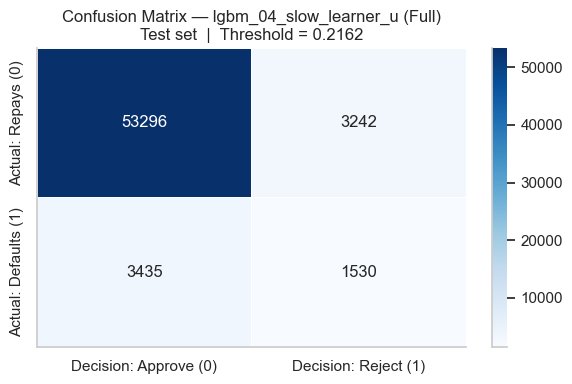

In [ ]:


# Confusion matrix — test set
# Rows: actual outcome | Columns: lending decision

cm = confusion_matrix(y_test_arr, y_pred_test, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index   = ["Actual: Repays (0)", "Actual: Defaults (1)"],
    columns = ["Decision: Approve (0)", "Decision: Reject (1)"],
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=ax)
ax.set_title(
    f"Confusion Matrix — {BEST_CONFIG_NAME} ({BEST_REPR})\n"
    f"Test set  |  Threshold = {MAIN_THRESHOLD:.4f}"
)
plt.tight_layout()
sns.despine()
plt.show()

In [ ]:


# Save test evaluation results

test_eval_df = pd.DataFrame([{
    "model":          BEST_CONFIG_NAME,
    "representation": BEST_REPR,
    "threshold":      MAIN_THRESHOLD,
    "ROC_AUC":        test_metrics["ROC_AUC"],
    "PR_AUC":         test_metrics["PR_AUC"],
    "precision":      prec_test,
    "recall":         rec_test,
    "approval_rate":  test_metrics["approval_rate"],
    "rejection_rate": test_metrics["rejection_rate"],
    "total_payoff":   test_metrics["total_payoff"],
    "avg_payoff":     test_metrics["average_payoff_per_applicant"],
    "TP":             test_metrics["TP_default_rejected"],
    "FP":             test_metrics["FP_good_rejected"],
    "TN":             test_metrics["TN_good_approved"],
    "FN":             test_metrics["FN_default_approved"],
}])

test_eval_df.to_csv("lgbm_test_final_evaluation.csv", index=False)
print("Saved: lgbm_test_final_evaluation.csv")


# ### 9.9 Feature Importance
#
# Feature importance (by gain) measures the total reduction in binary log-loss attributable to each feature across all splits. This links the modelling choices back to the data understanding in Section 2.
#
# **Code: Visualise and save feature importance**

Saved: lgbm_test_final_evaluation.csv


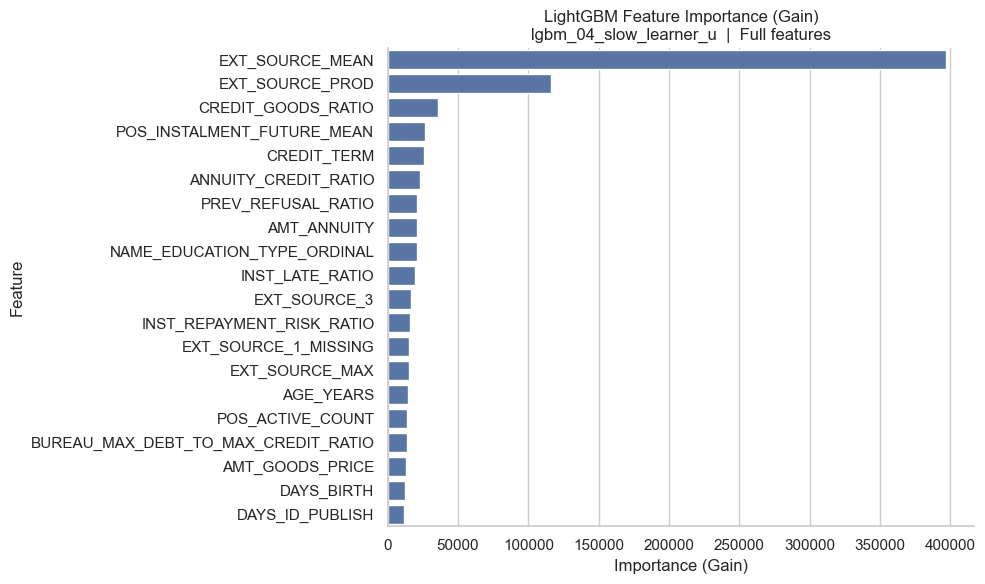

Saved: lgbm_feature_importance.csv  (268 features ranked)

Top 10 features by gain:


,rank,feature,importance
0,1,EXT_SOURCE_MEAN,396859.361551
1,2,EXT_SOURCE_PROD,115812.050417
2,3,CREDIT_GOODS_RATIO,36110.614264
3,4,POS_INSTALMENT_FUTURE_MEAN,26811.318460
4,5,CREDIT_TERM,26199.035708
5,6,ANNUITY_CREDIT_RATIO,22937.507791
6,7,PREV_REFUSAL_RATIO,21013.063832
7,8,AMT_ANNUITY,20907.343320
8,9,NAME_EDUCATION_TYPE_ORDINAL,20811.700089
9,10,INST_LATE_RATIO,19570.753913


In [ ]:
# ============================================================
# 9.9 Feature importance (Gain)
#
# Compatible with both pandas DataFrame and numpy ndarray.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------
# 1. Get LightGBM gain importance
# ------------------------------------------------------------
importance_vals = final_model.booster_.feature_importance(importance_type="gain")

# ------------------------------------------------------------
# 2. Get feature names safely
# ------------------------------------------------------------
# Case 1: X_dev_best is still a DataFrame
if hasattr(X_dev_best, "columns"):
    feature_names = list(X_dev_best.columns)

# Case 2: feature_names_best was created in the previous 9.8 code
elif "feature_names_best" in globals():
    feature_names = feature_names_best

# Case 3: fallback for numpy array
else:
    feature_names = [f"feature_{i}" for i in range(len(importance_vals))]

# Safety check: make sure feature name length matches importance length
if len(feature_names) != len(importance_vals):
    print("Warning: feature name length does not match importance length.")
    print(f"Number of feature names : {len(feature_names)}")
    print(f"Number of importances   : {len(importance_vals)}")
    print("Using generic feature names instead.")
    feature_names = [f"feature_{i}" for i in range(len(importance_vals))]

# ------------------------------------------------------------
# 3. Build importance table
# ------------------------------------------------------------
importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance_vals
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.insert(0, "rank", range(1, len(importance_df) + 1))

# ------------------------------------------------------------
# 4. Plot top 20 features
# ------------------------------------------------------------
top_n = min(20, len(importance_df))

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(top_n),
    x="importance",
    y="feature",
    ax=ax
)

ax.set_title(
    f"LightGBM Feature Importance (Gain)\n"
    f"{BEST_CONFIG_NAME}  |  {BEST_REPR} features"
)
ax.set_xlabel("Importance (Gain)")
ax.set_ylabel("Feature")

plt.tight_layout()
sns.despine()
plt.show()

# ------------------------------------------------------------
# 5. Save full importance table
# ------------------------------------------------------------
importance_df.to_csv("lgbm_feature_importance.csv", index=False)

print(f"Saved: lgbm_feature_importance.csv  ({len(importance_df)} features ranked)")
print()
print("Top 10 features by gain:")

display(importance_df.head(10))